## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'pessimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 40,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 35,     # annulation anticipée (> 2h avant)
    'late': 5,      # annulation tardive (< 2h avant)
    'noise': 0.05
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:34:39.227 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:34:39.323 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:34:39.431 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:34:39.513 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:34:39.598 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:34:39.707 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:34:39.811 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:34:39.881 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:34:39.931 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:34:39.949 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:34:40.043 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 3.74 kWh
  Station 1: 19.95 kWh
  Station 2: 6.32 kWh
  Station 3: 11.51 kWh
  Station 4: 3.70 kWh
  Station 5: 3.89 kWh
  Station 6: 14.68 kWh
  Station 7: 79.76 kWh
  Station 8: 24.50 kWh
  Station 9: 26.02 kWh
  Station 10: 15.07 kWh
  Station 11: 58.58 kWh
  Station 12: 0.00 kWh
  Station 13: 1.93 kWh
  Station 14: 14.77 kWh
  Station 15: 78.38 kWh
  Station 16: 3.20 kWh
  Station 17: 3.00 kWh
  Station 18: 0.96 kWh
  Station 19: 17.63 kWh
  Station 20: 0.00 kWh
  Station 21: 1.90 kWh
  Station 22: 4.12 kWh
  Station 23: 5.14 kWh
  Station 24: 8.63 kWh
  Station 25: 12.24 kWh
  Station 26: 8.28 kWh
  Station 27: 34.08 kWh
  Station 28: 71.17 kWh
  Station 29: 0.00 kWh
  Station 30: 3.47 kWh
  Station 31: 0.00 kWh
  Station 32: 1.65 kWh
  Station 33: 1.81 kWh
  Station 34: 1.67 kWh
  Station 35: 5.75 kWh
  Station 36: 0.00 kWh
  Station 37: 11.53 kWh
  Station 38: 2.04 kWh
  Station 39: 0.00 kWh

--- User Re

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

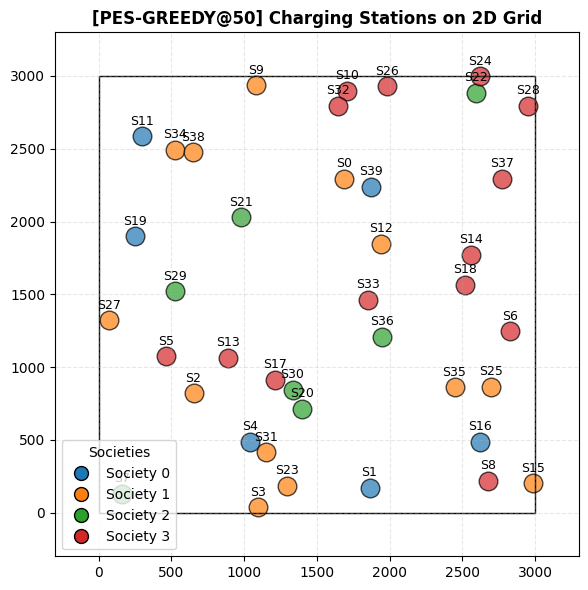

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

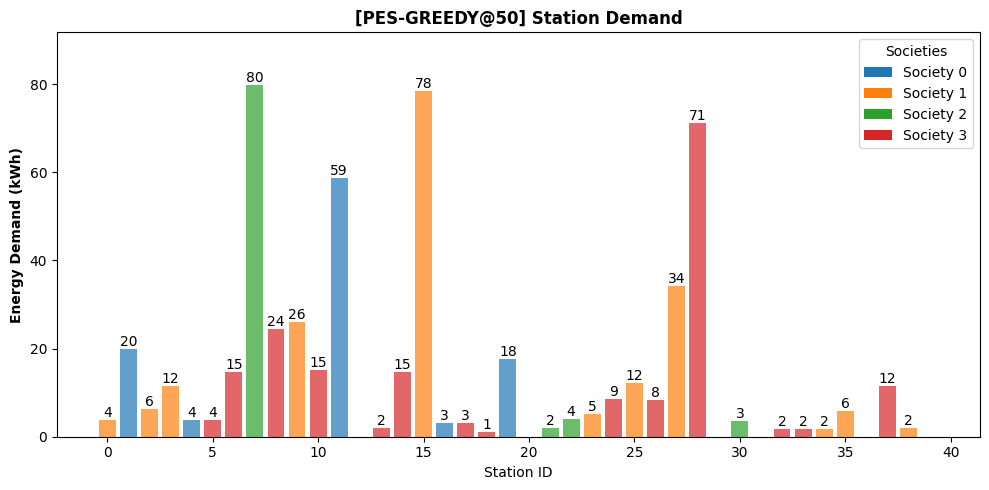

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

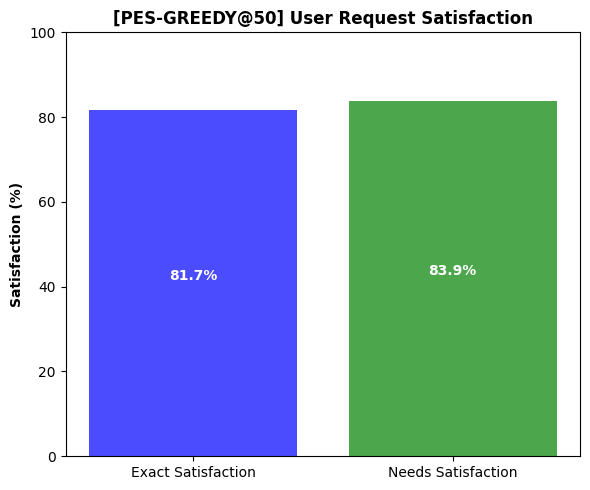

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

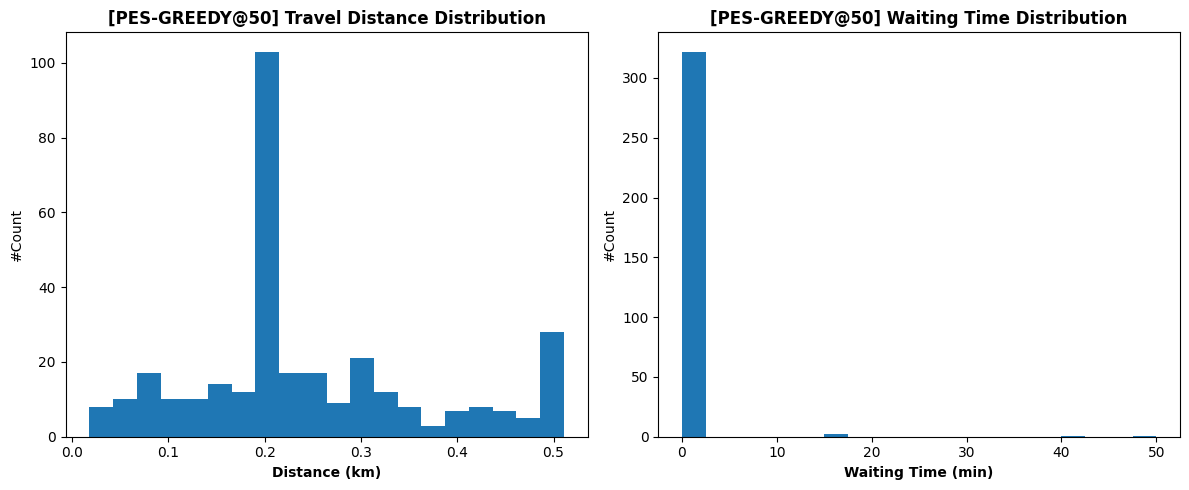

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

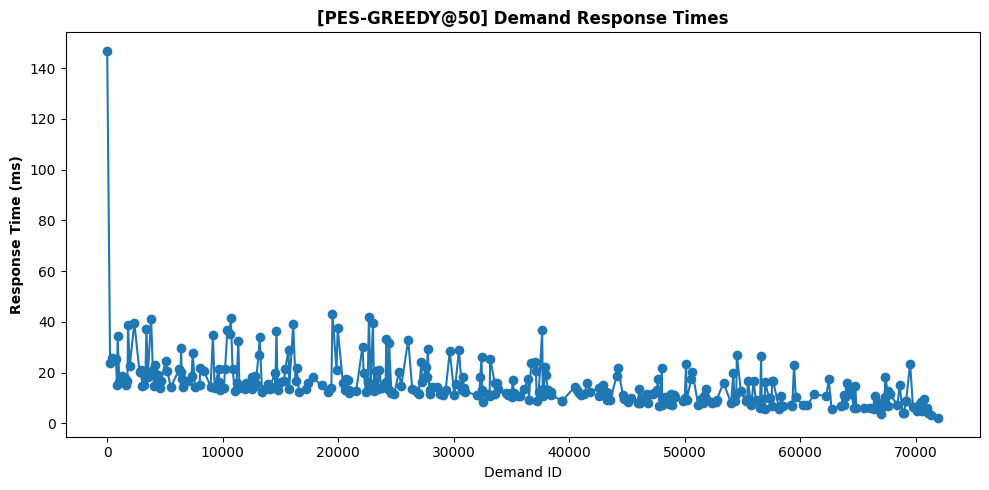

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

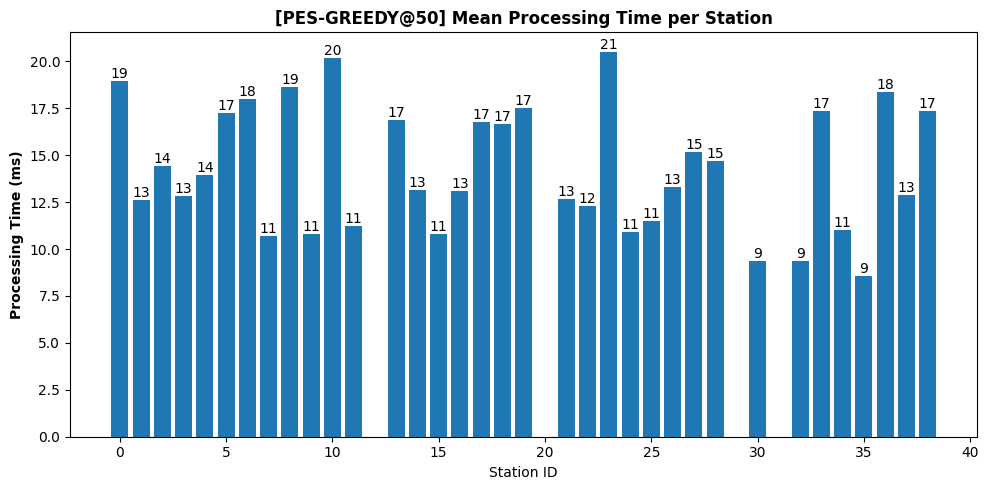

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [26]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.213194  0.034722  0.000000  0.061806       NaN   
1            0           4  0.062500  0.000000  0.000000  0.000000  0.000000   
2            0          11  0.390972  0.240972  0.062500  0.109722       NaN   
3            0          16  0.044444  0.000000  0.000000  0.000000       NaN   
4            0          19  0.139583  0.063889  0.000000  0.000000  0.000000   
5            0          39  0.000000  0.000000  0.000000  0.000000  0.000000   
6            1           0  0.048611  0.000000  0.000000  0.000000  0.000000   
7            1           2  0.083333  0.000000  0.000000  0.000000  0.000000   
8            1           3  0.106944  0.022222  0.000000  0.000000       NaN   
9            1           9  0.301389  0.078472  0.000000  0.000000       NaN   
10           1          12  0.000000  0.000000  0.000000  0.000000  0.000000   
11           1          15  0.484722  0.

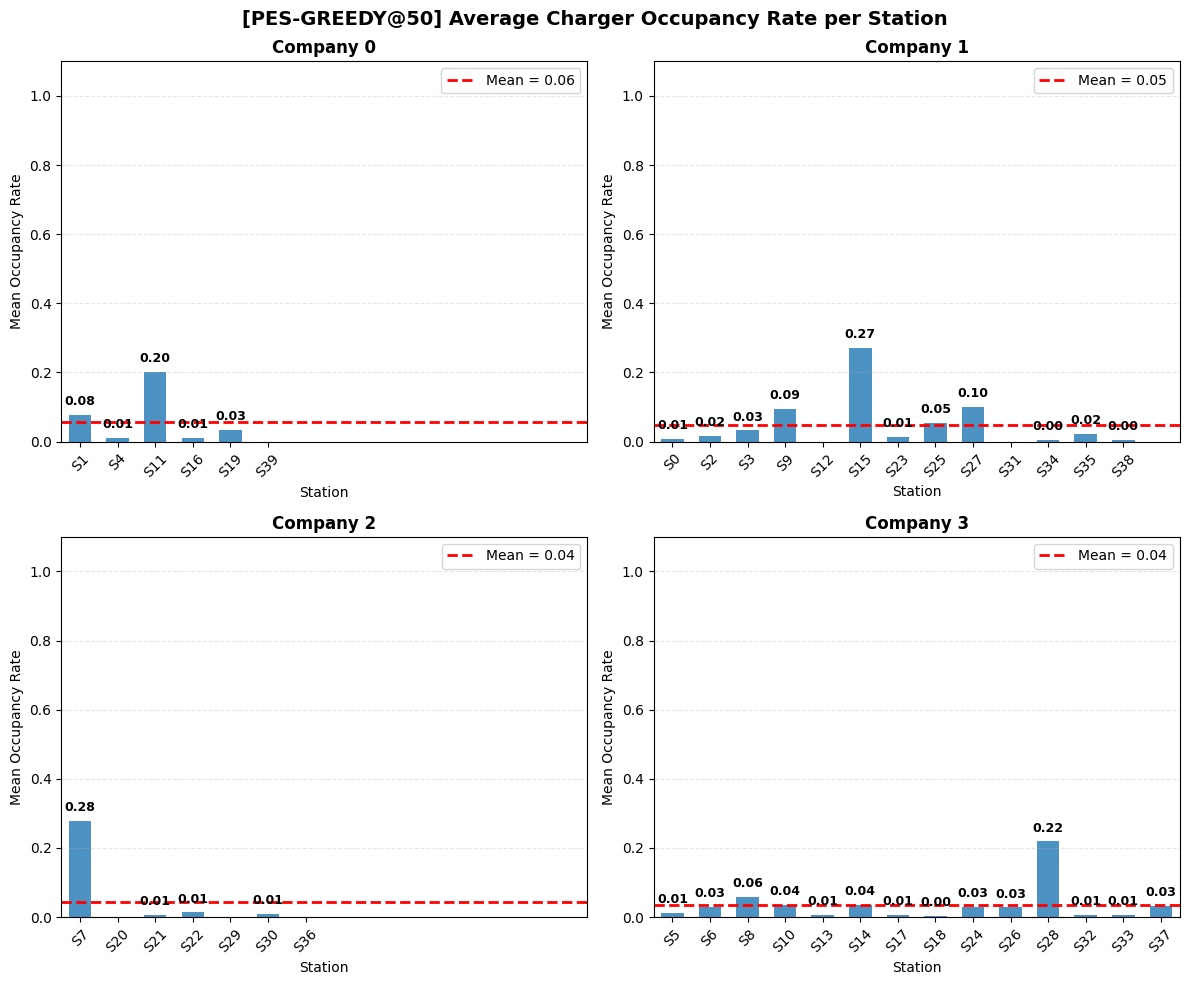

In [27]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

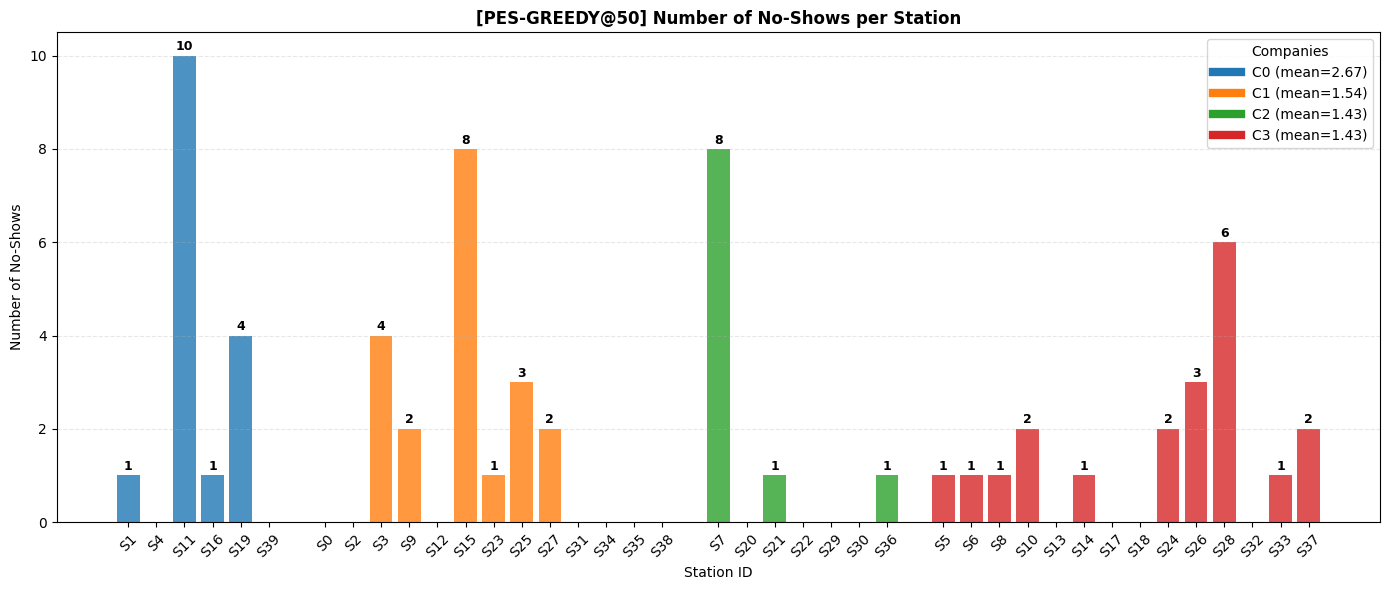

In [28]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [29]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,13,12,1,0,0,0.923077,0.076923,0.0,0.0
1,0,4,3,3,0,0,0,1.000000,0.000000,0.0,0.0
2,0,11,46,35,10,0,0,0.760870,0.217391,0.0,0.0
3,0,16,3,2,1,0,0,0.666667,0.333333,0.0,0.0
4,0,19,14,10,4,0,0,0.714286,0.285714,0.0,0.0
5,0,39,0,0,0,0,0,NaN,NaN,NaN,NaN
6,1,0,3,3,0,0,0,1.000000,0.000000,0.0,0.0
7,1,2,4,4,0,0,0,1.000000,0.000000,0.0,0.0
8,1,3,10,6,4,0,0,0.600000,0.400000,0.0,0.0
9,1,9,19,16,2,0,0,0.842105,0.105263,0.0,0.0


#### **BRAM-EV**

##### *Params*

In [30]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [31]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [32]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:34:47.027 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:34:47.382 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:34:47.887 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:34:48.953 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:34:49.915 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:34:50.720 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:34:51.201 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:34:52.073 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:34:52.191 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:34:52.449 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:34:53.131 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [33]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 15.12 kWh
  Station 1: 1.75 kWh
  Station 2: 3.23 kWh
  Station 3: 1.75 kWh
  Station 4: 0.00 kWh
  Station 5: 3.90 kWh
  Station 6: 13.12 kWh
  Station 7: 20.10 kWh
  Station 8: 3.07 kWh
  Station 9: 1.47 kWh
  Station 10: 53.12 kWh
  Station 11: 20.73 kWh
  Station 12: 9.19 kWh
  Station 13: 3.85 kWh
  Station 14: 0.00 kWh
  Station 15: 4.17 kWh
  Station 16: 0.00 kWh
  Station 17: 1.95 kWh
  Station 18: 4.08 kWh
  Station 19: 0.00 kWh
  Station 20: 4.07 kWh
  Station 21: 3.00 kWh
  Station 22: 9.85 kWh
  Station 23: 7.17 kWh
  Station 24: 15.88 kWh
  Station 25: 1.50 kWh
  Station 26: 50.65 kWh
  Station 27: 47.54 kWh
  Station 28: 1.90 kWh
  Station 29: 0.00 kWh
  Station 30: 10.86 kWh
  Station 31: 30.65 kWh
  Station 32: 4.54 kWh
  Station 33: 95.45 kWh
  Station 34: 7.96 kWh
  Station 35: 3.73 kWh
  Station 36: 55.73 kWh
  Station 37: 21.37 kWh
  Station 38: 4.05 kWh
  Station 39: 14.02 kWh

--- User Req

In [34]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

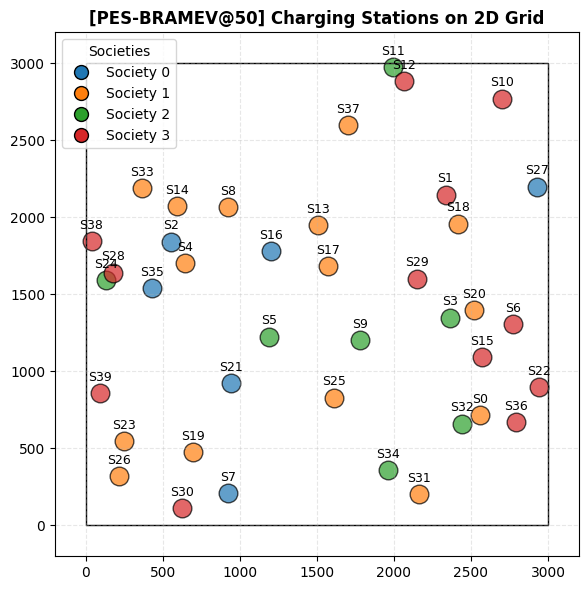

In [35]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

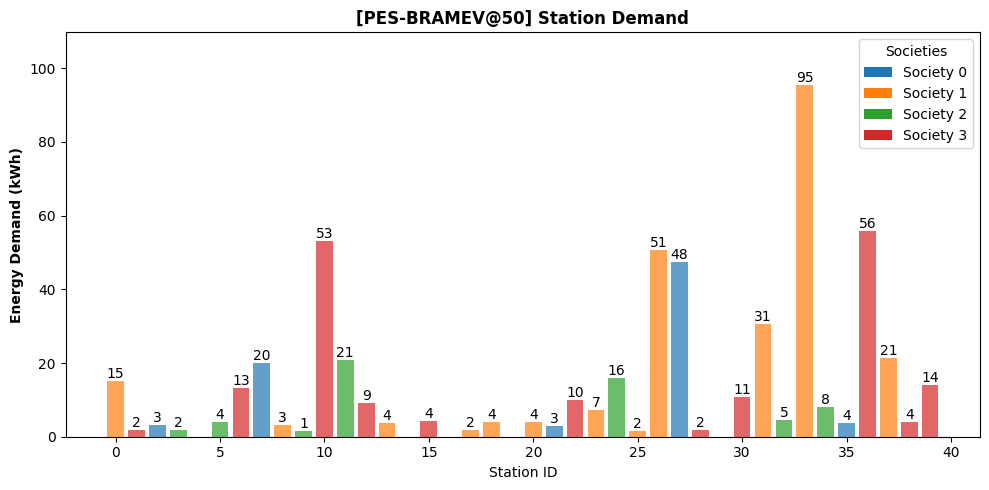

In [36]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

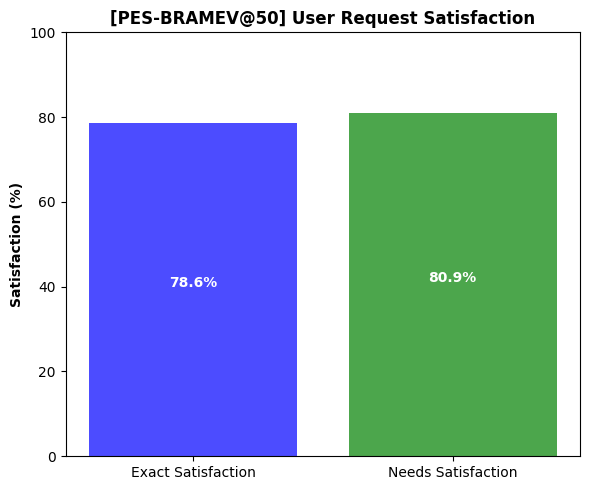

In [37]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

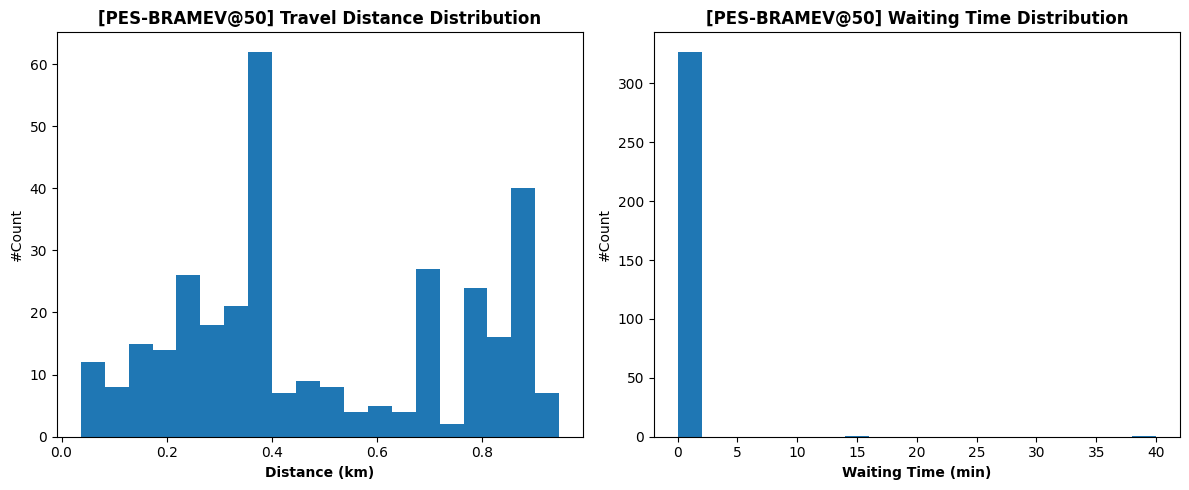

In [38]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

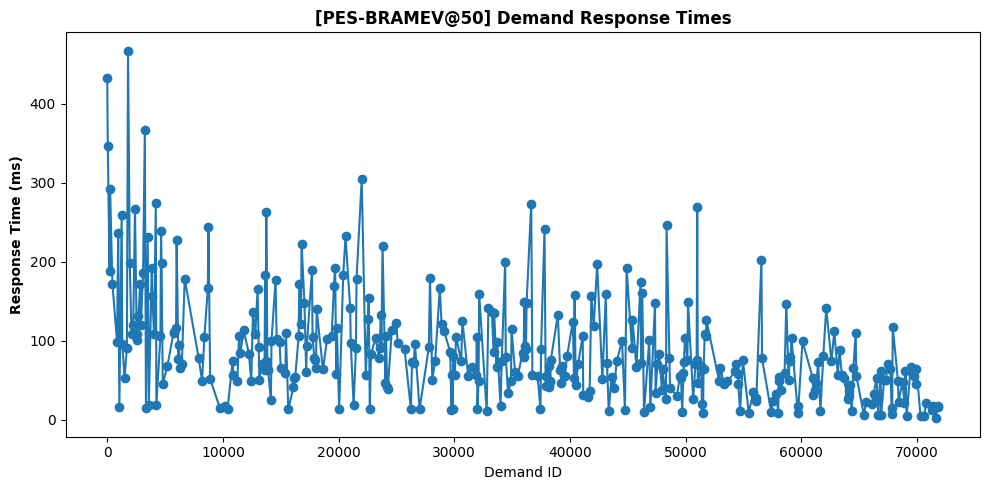

In [39]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

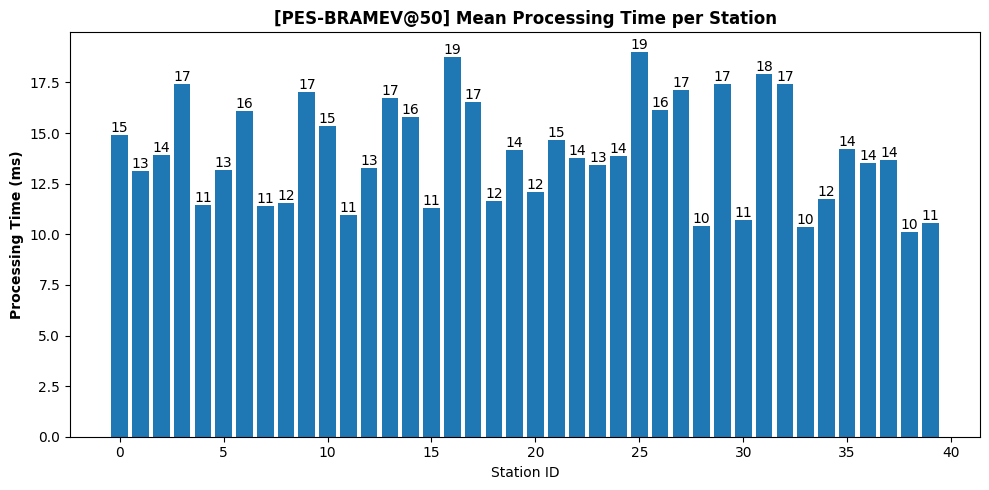

In [40]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

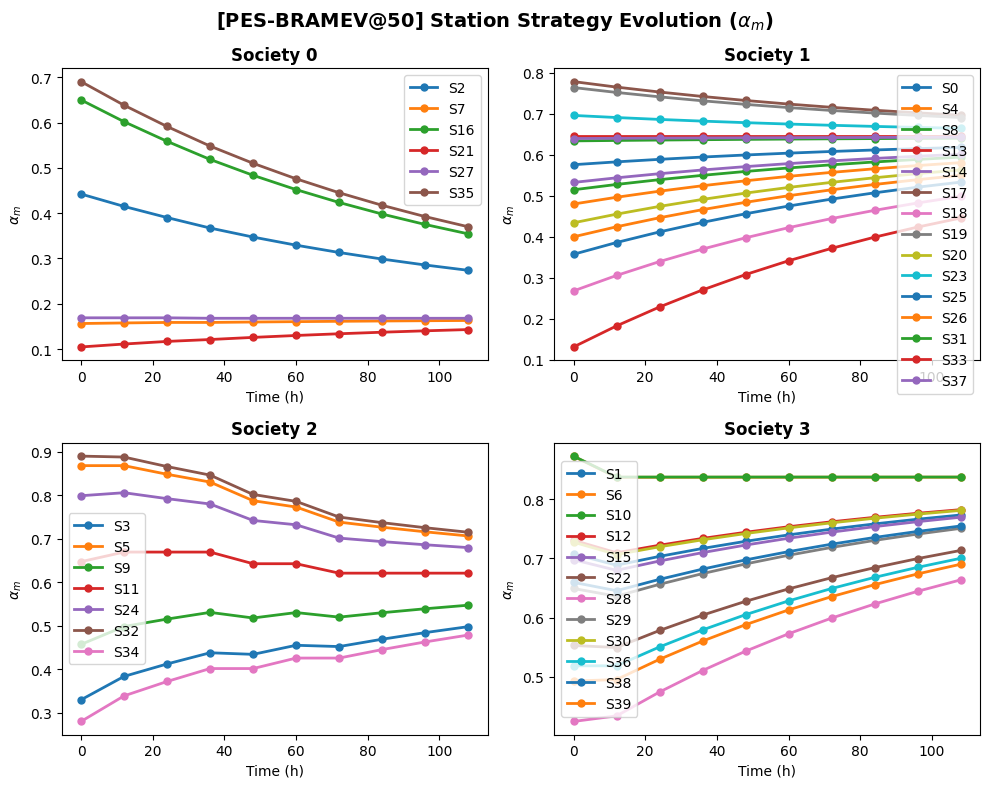

In [41]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [42]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4  borne_5  \
0            0           2  0.036111  0.000000  0.000000  0.000000  0.00000   
1            0           7  0.147222  0.097917  0.017361  0.000000      NaN   
2            0          16  0.000000  0.000000  0.000000  0.000000  0.00000   
3            0          21  0.031250  0.000000  0.000000  0.000000  0.00000   
4            0          27  0.436806  0.140278  0.017361  0.000000  0.00000   
5            0          35  0.038889  0.000000  0.000000  0.000000  0.00000   
6            1           0  0.181250  0.057639  0.000000  0.000000  0.00000   
7            1           4  0.000000  0.000000  0.000000  0.000000      NaN   
8            1           8  0.046528  0.000000  0.000000  0.000000      NaN   
9            1          13  0.029167  0.019444  0.000000  0.000000  0.00000   
10           1          14  0.000000  0.000000  0.000000  0.000000  0.00000   
11           1          17  0.027083  0.000000  0.00

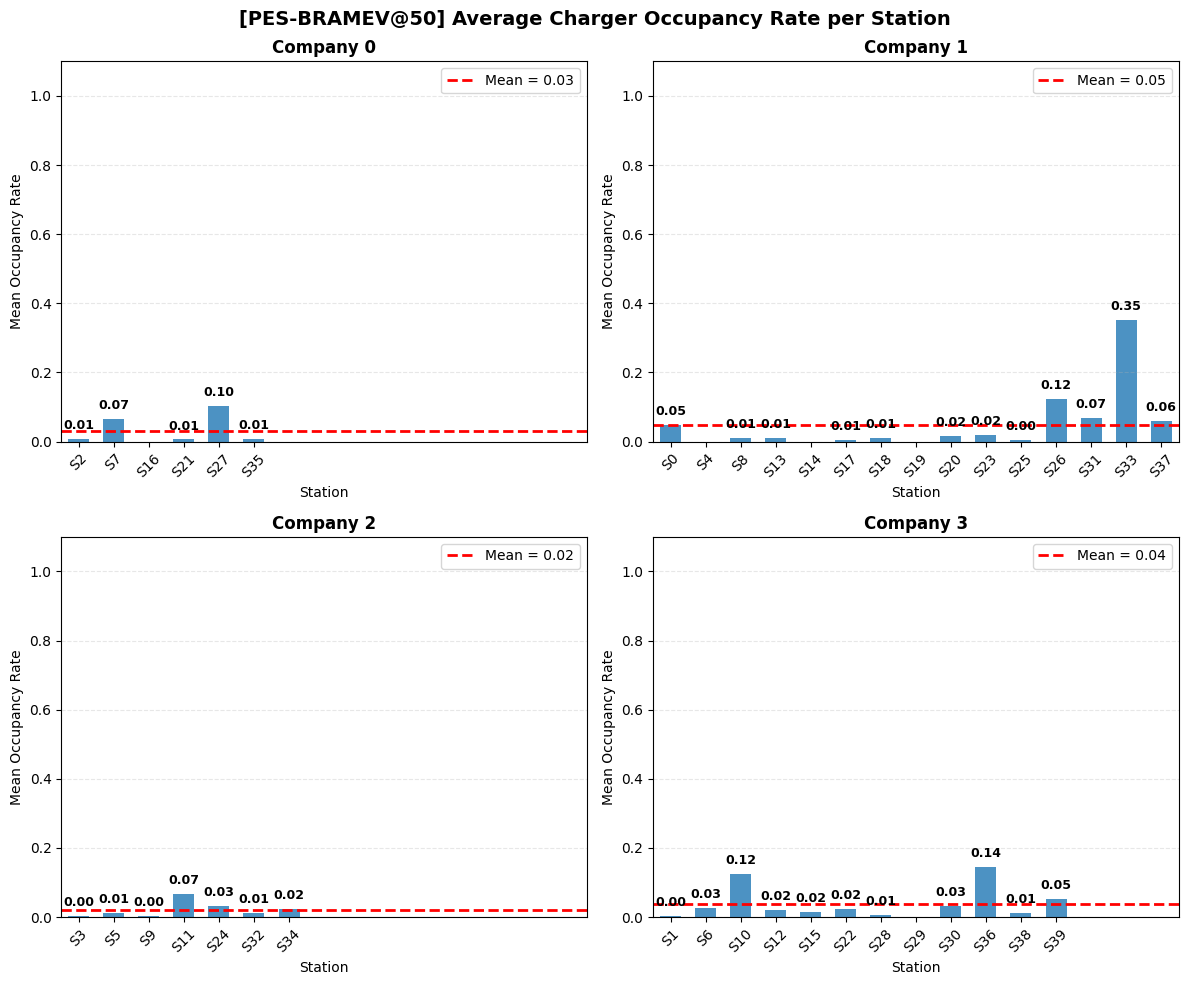

In [43]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

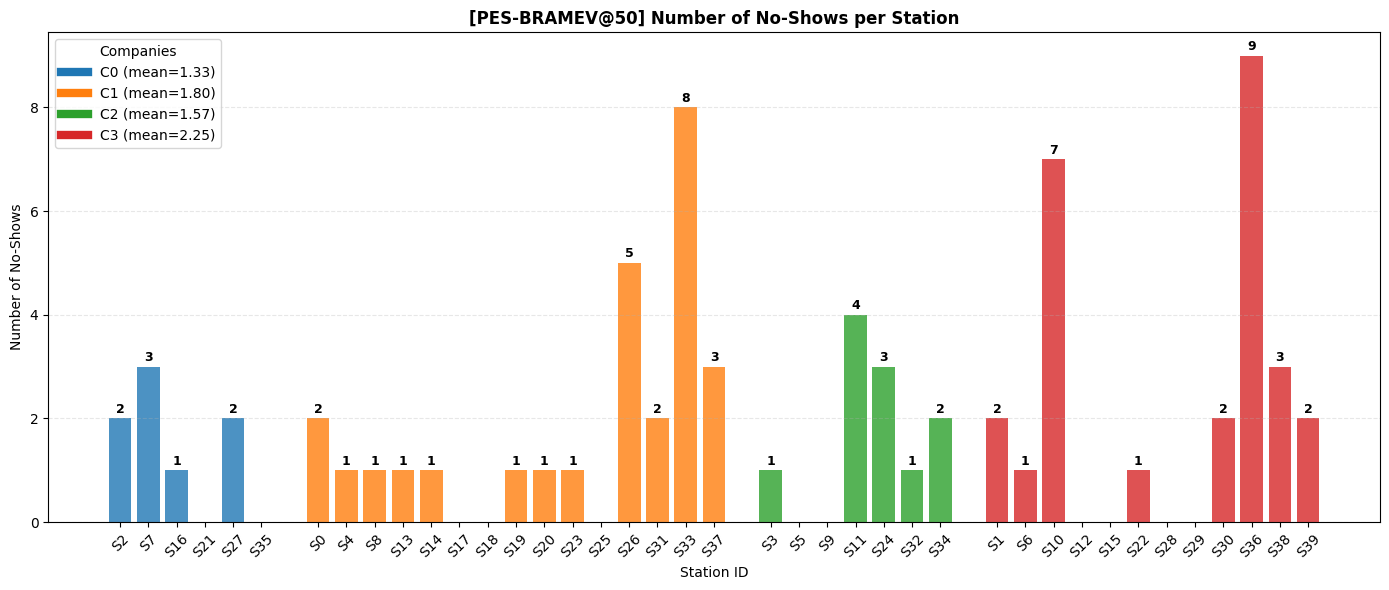

In [44]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [45]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,4,2,2,0,0,0.500000,0.500000,0.0,0.0
1,0,7,16,13,3,0,0,0.812500,0.187500,0.0,0.0
2,0,16,1,0,1,0,0,0.000000,1.000000,0.0,0.0
3,0,21,2,2,0,0,0,1.000000,0.000000,0.0,0.0
4,0,27,31,28,2,0,0,0.903226,0.064516,0.0,0.0
5,0,35,2,2,0,0,0,1.000000,0.000000,0.0,0.0
6,1,0,11,9,2,0,0,0.818182,0.181818,0.0,0.0
7,1,4,1,0,1,0,0,0.000000,1.000000,0.0,0.0
8,1,8,3,2,1,0,0,0.666667,0.333333,0.0,0.0
9,1,13,3,2,1,0,0,0.666667,0.333333,0.0,0.0


#### **COMPARISON**

##### *Params*

In [46]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

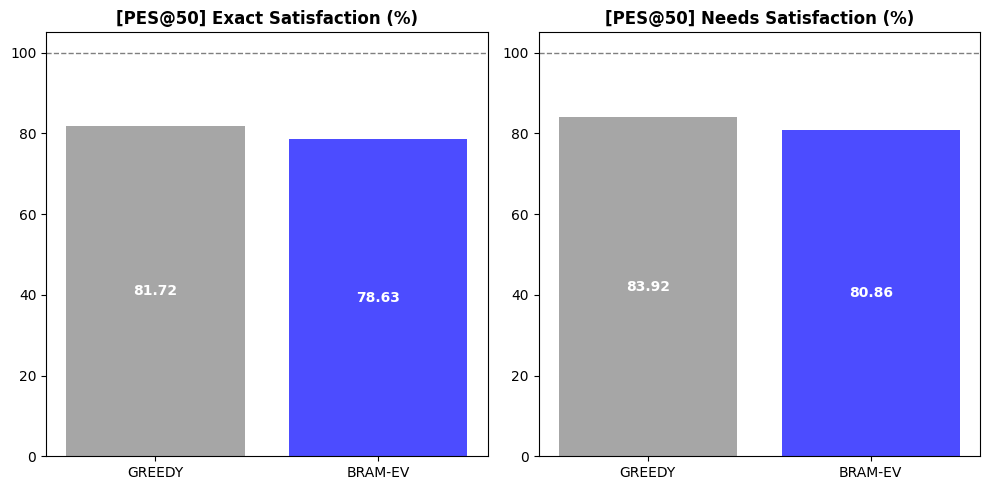

In [47]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

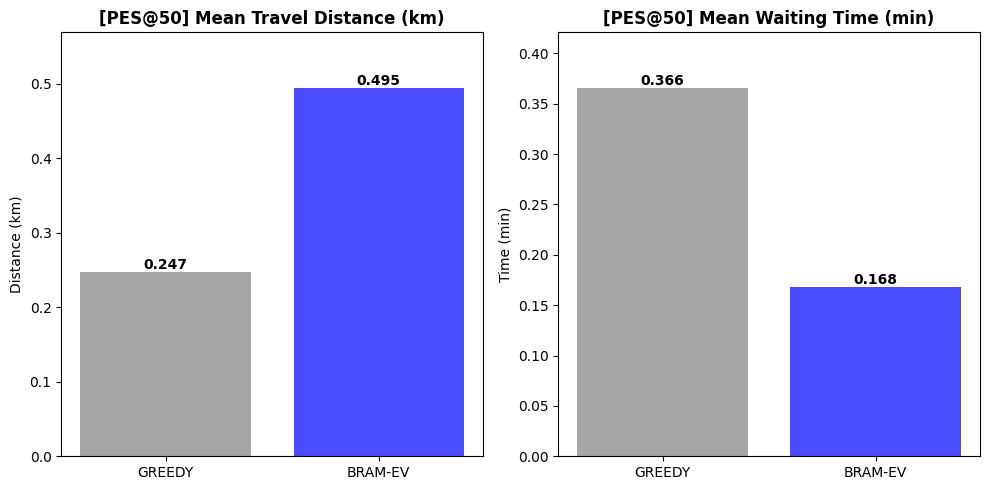

In [48]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

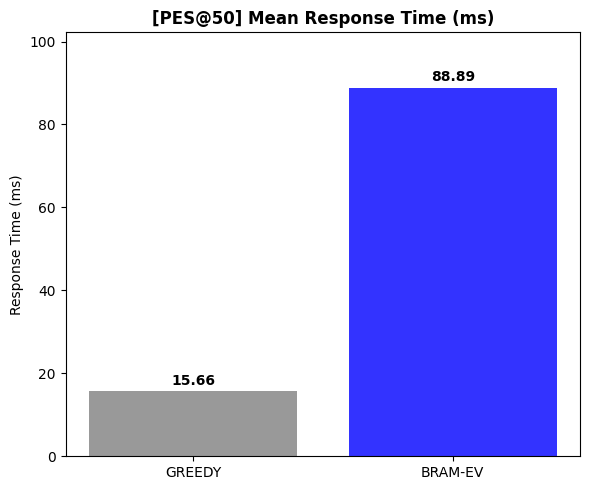

In [49]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [50]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [51]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [52]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [53]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:35:20.718 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:35:20.827 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:35:20.986 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:35:21.038 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:35:21.241 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:35:21.396 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:35:21.461 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:35:21.627 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:35:21.870 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:35:22.120 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:35:22.330 | IN

##### *Metrics*

In [54]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 14.04 kWh
  Station 2: 0.00 kWh
  Station 3: 47.79 kWh
  Station 4: 27.87 kWh
  Station 5: 16.59 kWh
  Station 6: 29.99 kWh
  Station 7: 16.54 kWh
  Station 8: 24.07 kWh
  Station 9: 1.46 kWh
  Station 10: 0.00 kWh
  Station 11: 2.27 kWh
  Station 12: 12.76 kWh
  Station 13: 28.12 kWh
  Station 14: 2.37 kWh
  Station 15: 15.40 kWh
  Station 16: 12.50 kWh
  Station 17: 20.02 kWh
  Station 18: 2.08 kWh
  Station 19: 164.92 kWh
  Station 20: 50.85 kWh
  Station 21: 1.47 kWh
  Station 22: 2.45 kWh
  Station 23: 131.29 kWh
  Station 24: 1.93 kWh
  Station 25: 143.80 kWh
  Station 26: 8.08 kWh
  Station 27: 15.28 kWh
  Station 28: 33.55 kWh
  Station 29: 0.00 kWh
  Station 30: 0.00 kWh
  Station 31: 44.72 kWh
  Station 32: 0.00 kWh
  Station 33: 0.00 kWh
  Station 34: 0.00 kWh
  Station 35: 25.41 kWh
  Station 36: 101.57 kWh
  Station 37: 17.28 kWh
  Station 38: 44.35 kWh
  Station 39: 2.30 kWh


In [55]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

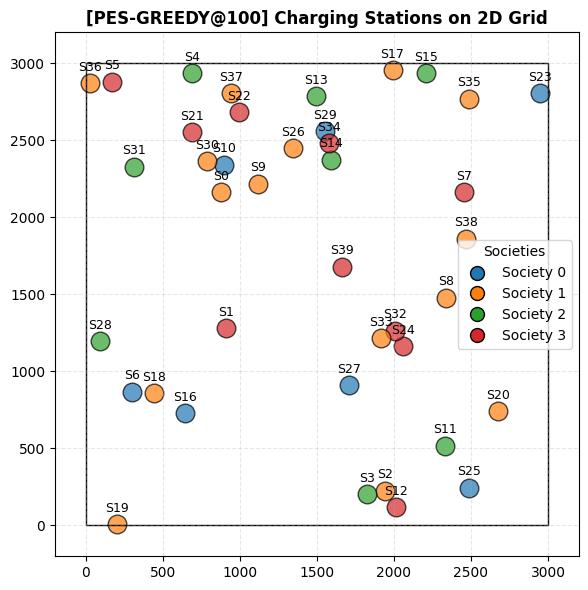

In [56]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

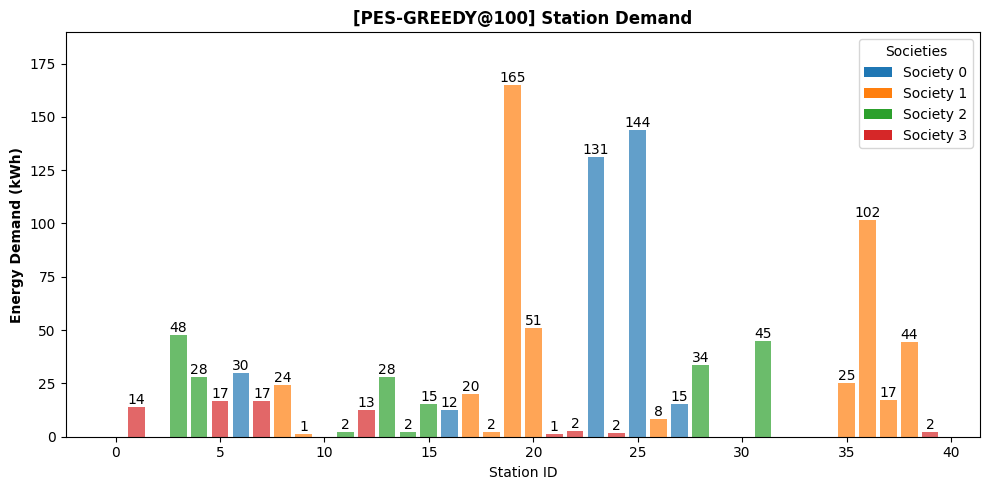

In [57]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

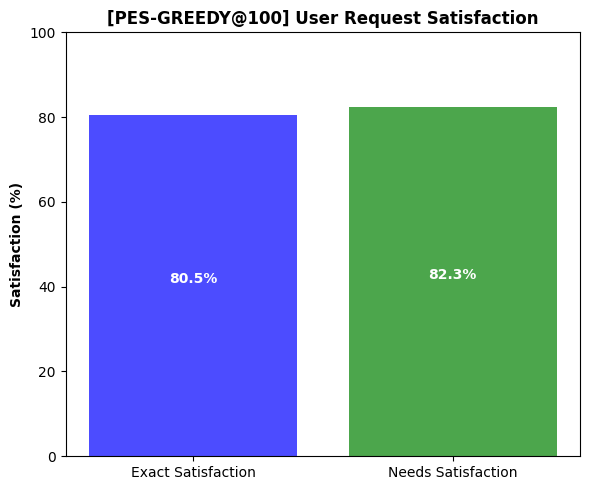

In [58]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

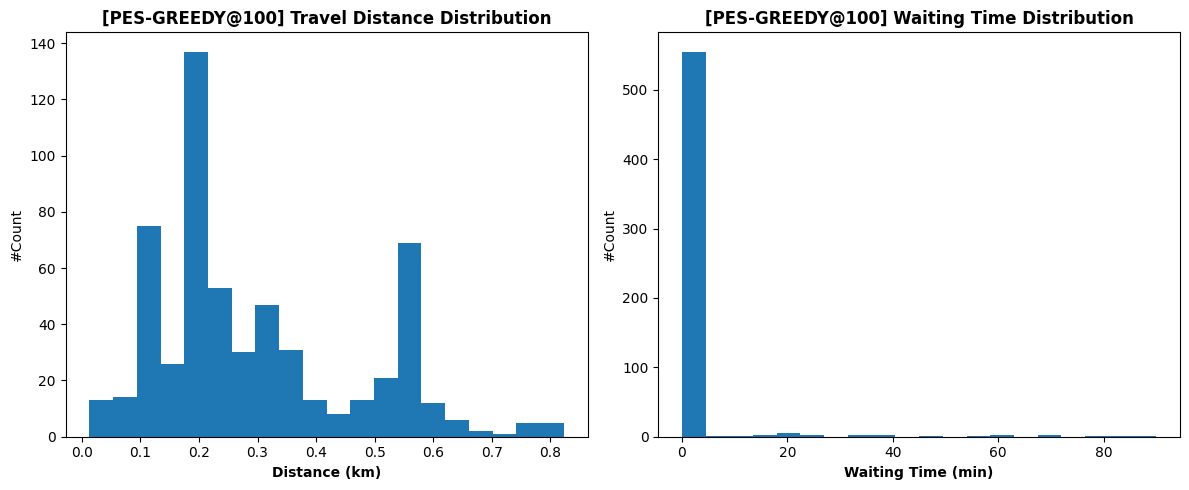

In [59]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

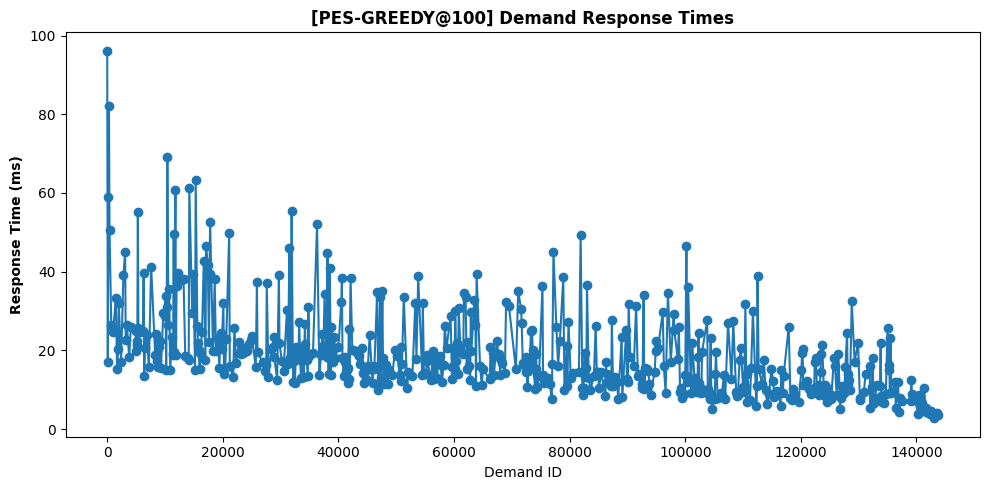

In [60]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

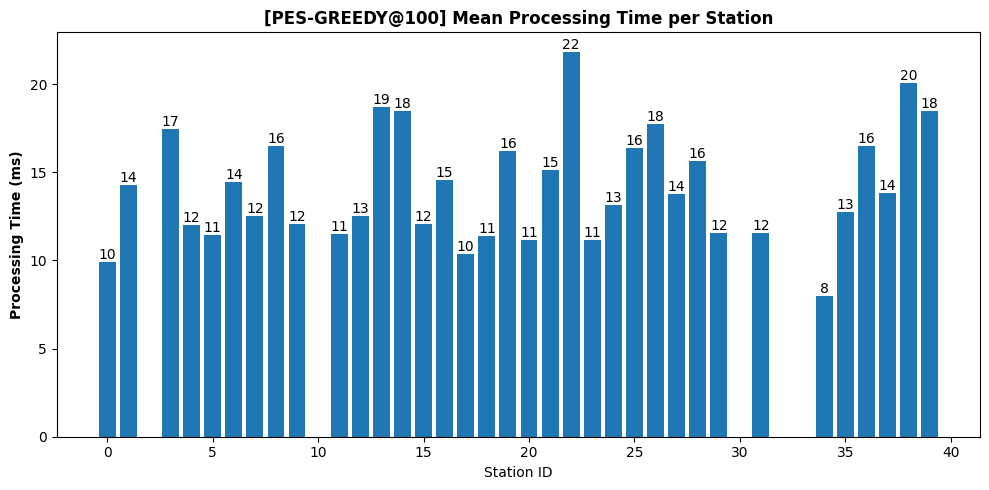

In [61]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [62]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           6  0.249306  0.127778  0.000000  0.000000  0.034028   
1            0          10  0.000000  0.000000  0.000000  0.000000  0.000000   
2            0          16  0.142361  0.040972  0.000000  0.000000  0.000000   
3            0          23  0.700000  0.577083  0.245139  0.412500       NaN   
4            0          25  0.549306  0.520833  0.259722  0.049306  0.240278   
5            0          27  0.164583  0.075694  0.000000  0.000000       NaN   
6            0          29  0.000000  0.000000  0.000000  0.000000       NaN   
7            1           0  0.000000  0.000000  0.000000  0.000000       NaN   
8            1           2  0.000000  0.000000  0.000000  0.000000  0.000000   
9            1           8  0.215972  0.122917  0.000000  0.000000  0.027778   
10           1           9  0.017361  0.000000  0.000000  0.000000  0.000000   
11           1          17  0.152778  0.

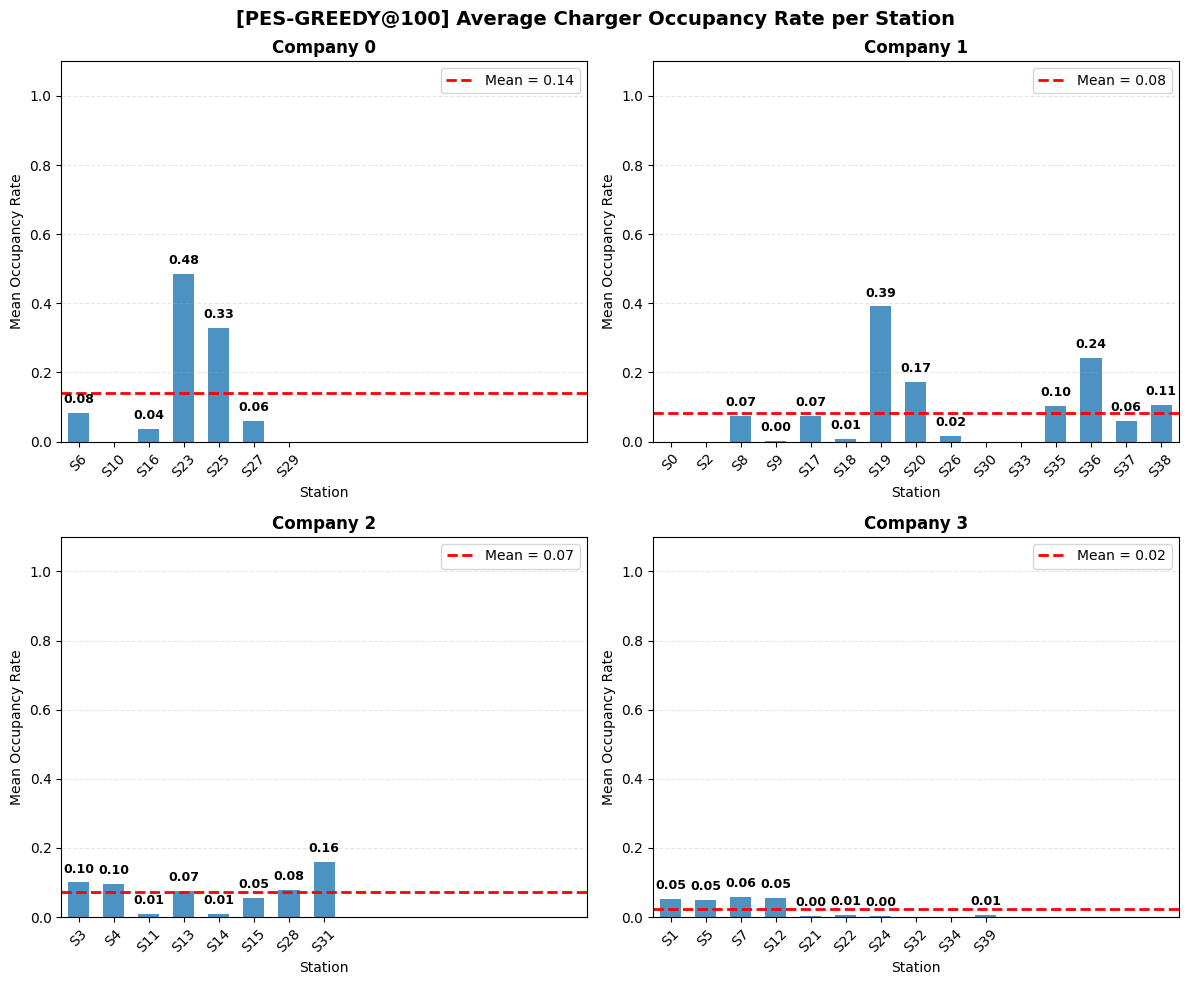

In [63]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

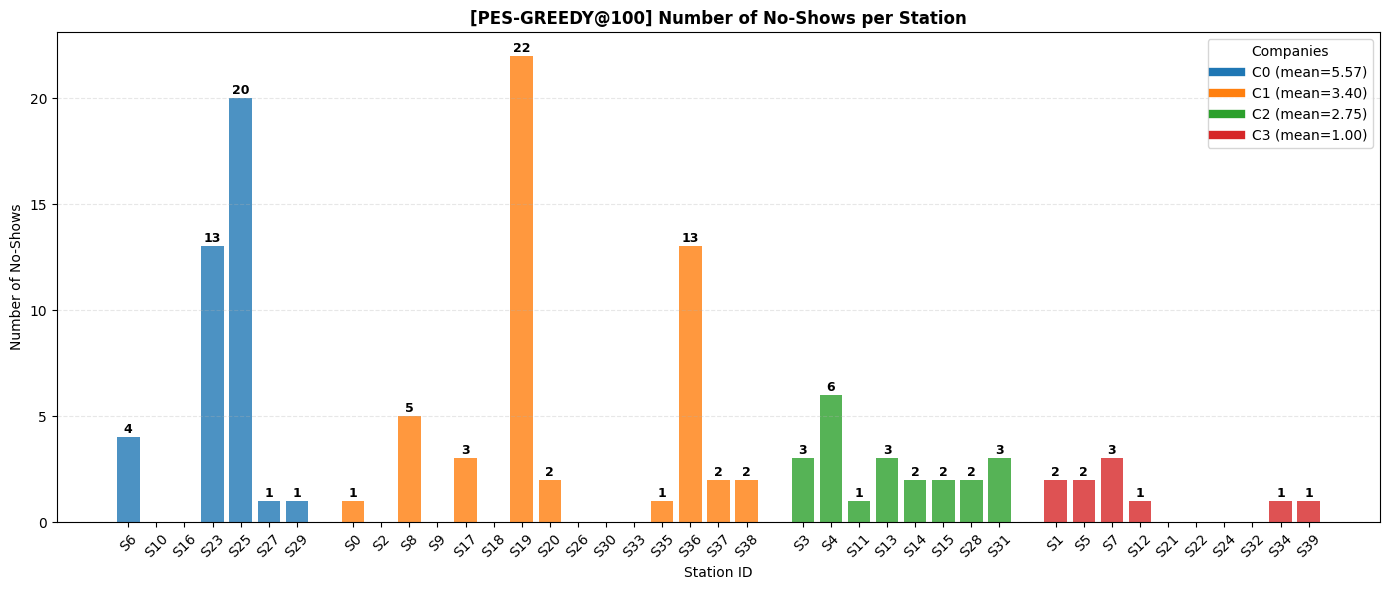

In [64]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [65]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,6,21,17,4,0,0,0.809524,0.190476,0.0,0.0
1,0,10,0,0,0,0,0,NaN,NaN,NaN,NaN
2,0,16,7,7,0,0,0,1.000000,0.000000,0.0,0.0
3,0,23,86,73,13,0,0,0.848837,0.151163,0.0,0.0
4,0,25,97,76,20,0,0,0.783505,0.206186,0.0,0.0
5,0,27,9,8,1,0,0,0.888889,0.111111,0.0,0.0
6,0,29,1,0,1,0,0,0.000000,1.000000,0.0,0.0
7,1,0,1,0,1,0,0,0.000000,1.000000,0.0,0.0
8,1,2,0,0,0,0,0,NaN,NaN,NaN,NaN
9,1,8,18,13,5,0,0,0.722222,0.277778,0.0,0.0


#### **BRAM-EV**

##### *Params*

In [66]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [67]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [68]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:35:36.833 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:35:37.469 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:35:38.292 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:35:39.049 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:35:39.289 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:35:41.441 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:35:42.642 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:35:43.529 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:35:43.723 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:35:44.688 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:35:45.784 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [69]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 9.66 kWh
  Station 1: 106.65 kWh
  Station 2: 5.42 kWh
  Station 3: 109.36 kWh
  Station 4: 9.18 kWh
  Station 5: 20.47 kWh
  Station 6: 28.68 kWh
  Station 7: 4.18 kWh
  Station 8: 18.60 kWh
  Station 9: 89.53 kWh
  Station 10: 57.85 kWh
  Station 11: 2.39 kWh
  Station 12: 11.07 kWh
  Station 13: 9.93 kWh
  Station 14: 4.57 kWh
  Station 15: 25.57 kWh
  Station 16: 15.77 kWh
  Station 17: 3.52 kWh
  Station 18: 16.07 kWh
  Station 19: 22.36 kWh
  Station 20: 30.62 kWh
  Station 21: 61.59 kWh
  Station 22: 23.68 kWh
  Station 23: 9.98 kWh
  Station 24: 16.60 kWh
  Station 25: 47.05 kWh
  Station 26: 19.69 kWh
  Station 27: 50.03 kWh
  Station 28: 20.10 kWh
  Station 29: 112.72 kWh
  Station 30: 57.80 kWh
  Station 31: 1.70 kWh
  Station 32: 6.78 kWh
  Station 33: 7.43 kWh
  Station 34: 12.27 kWh
  Station 35: 51.89 kWh
  Station 36: 7.08 kWh
  Station 37: 1.70 kWh
  Station 38: 1.57 kWh
  Station 39: 3.50 kWh


In [70]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

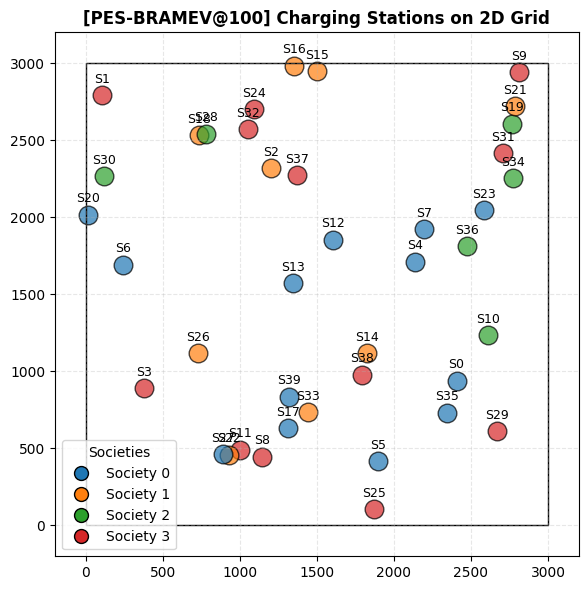

In [71]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

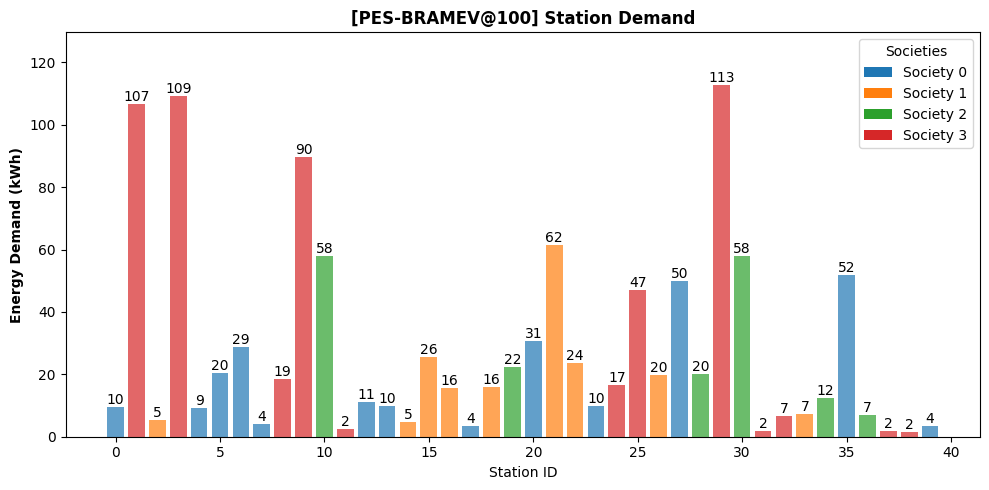

In [72]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

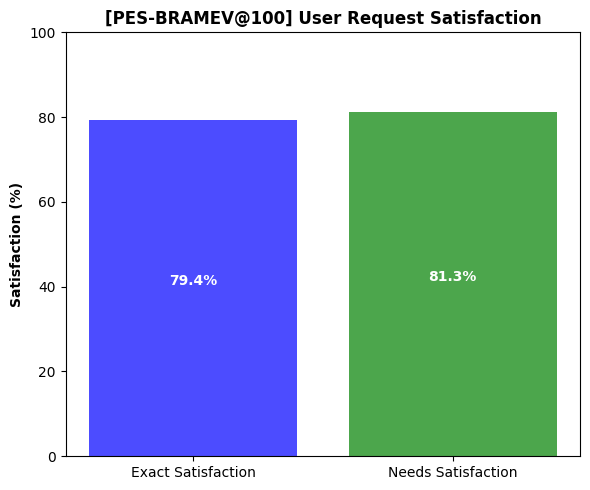

In [73]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

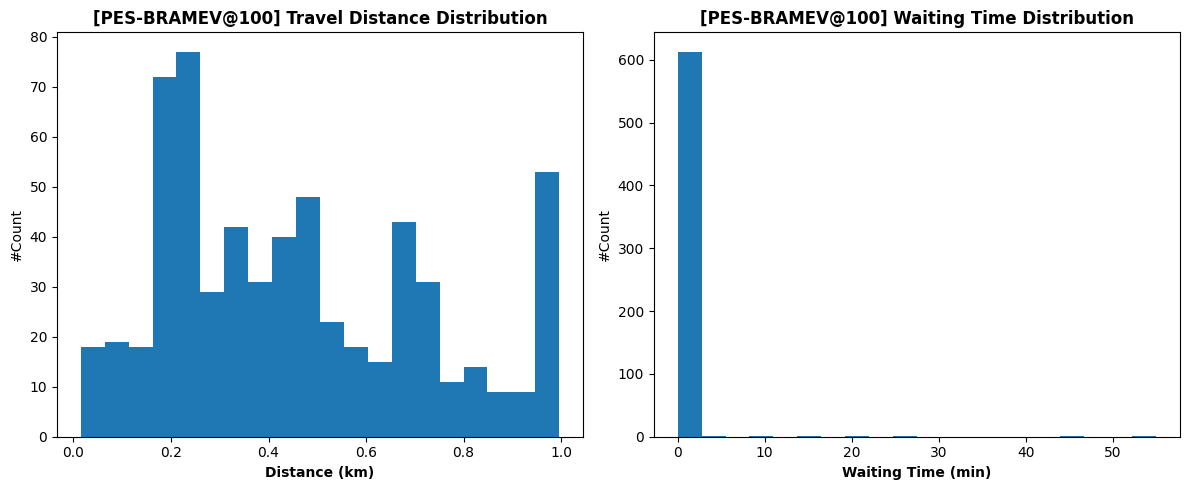

In [74]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

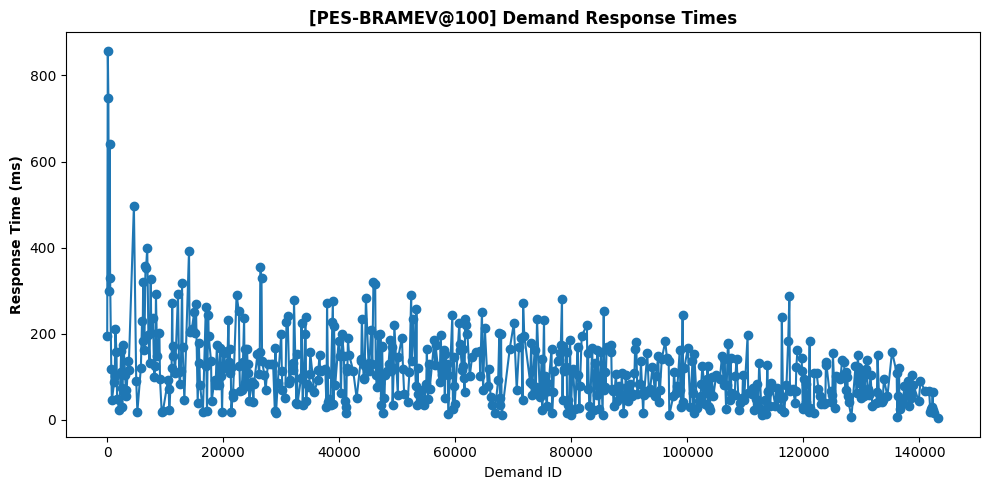

In [75]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

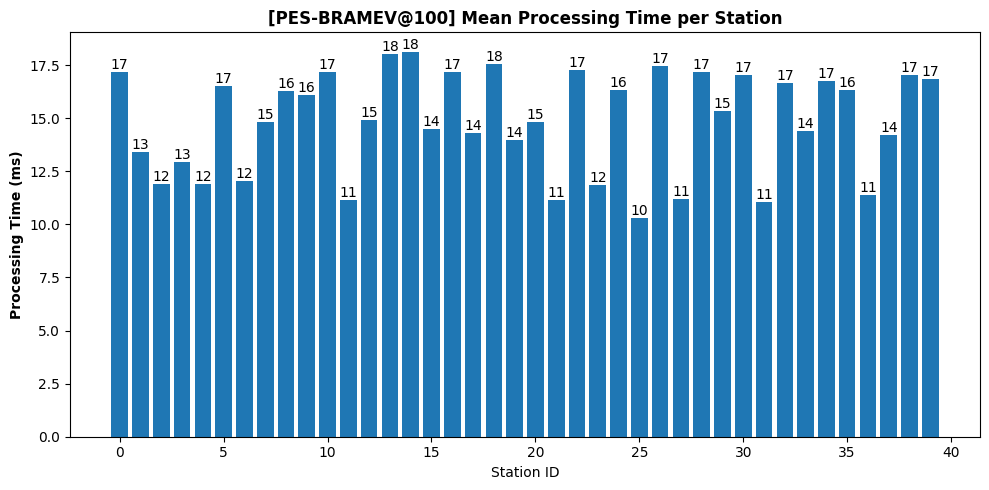

In [76]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

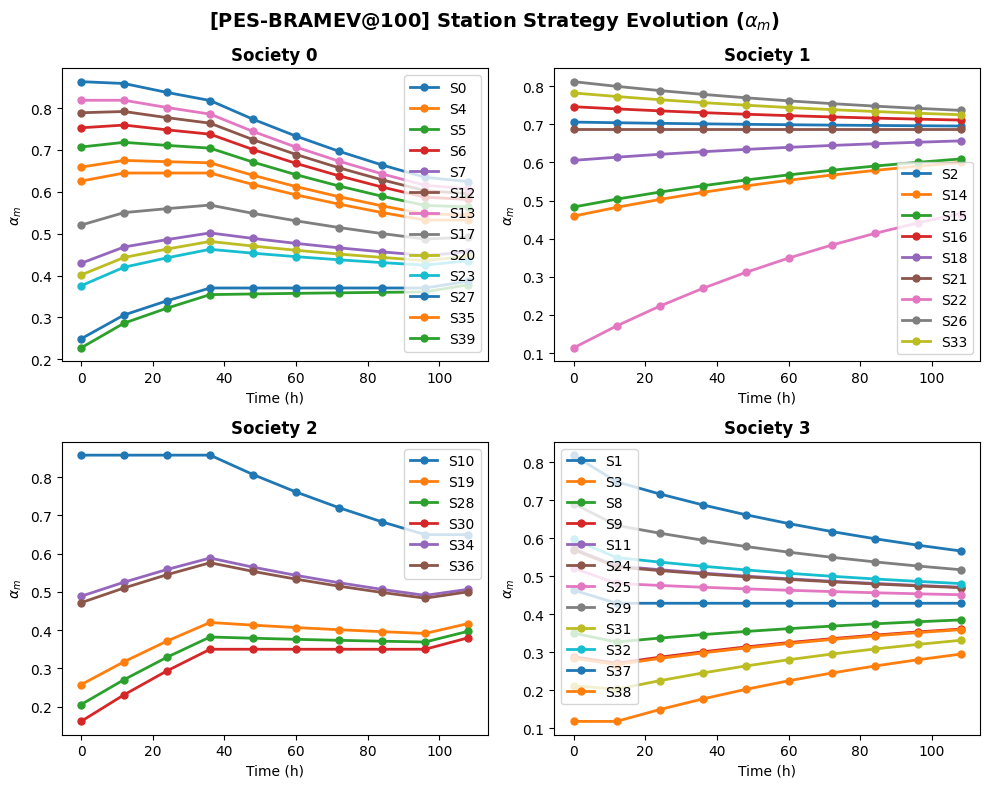

In [77]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [78]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.111806  0.000000  0.000000  0.000000  0.000000   
1            0           4  0.122917  0.000000  0.000000  0.000000       NaN   
2            0           5  0.160417  0.081250  0.000000  0.000000  0.000000   
3            0           6  0.238889  0.113194  0.000000  0.022917       NaN   
4            0           7  0.070833  0.000000  0.000000  0.000000  0.000000   
5            0          12  0.157639  0.016667  0.000000  0.000000  0.000000   
6            0          13  0.104167  0.022222  0.000000  0.000000  0.000000   
7            0          17  0.042361  0.000000  0.000000  0.000000  0.000000   
8            0          20  0.273611  0.123611  0.000000  0.000000  0.000000   
9            0          23  0.105556  0.047917  0.000000  0.000000       NaN   
10           0          27  0.401389  0.174306  0.022222  0.086111       NaN   
11           0          35  0.481944  0.

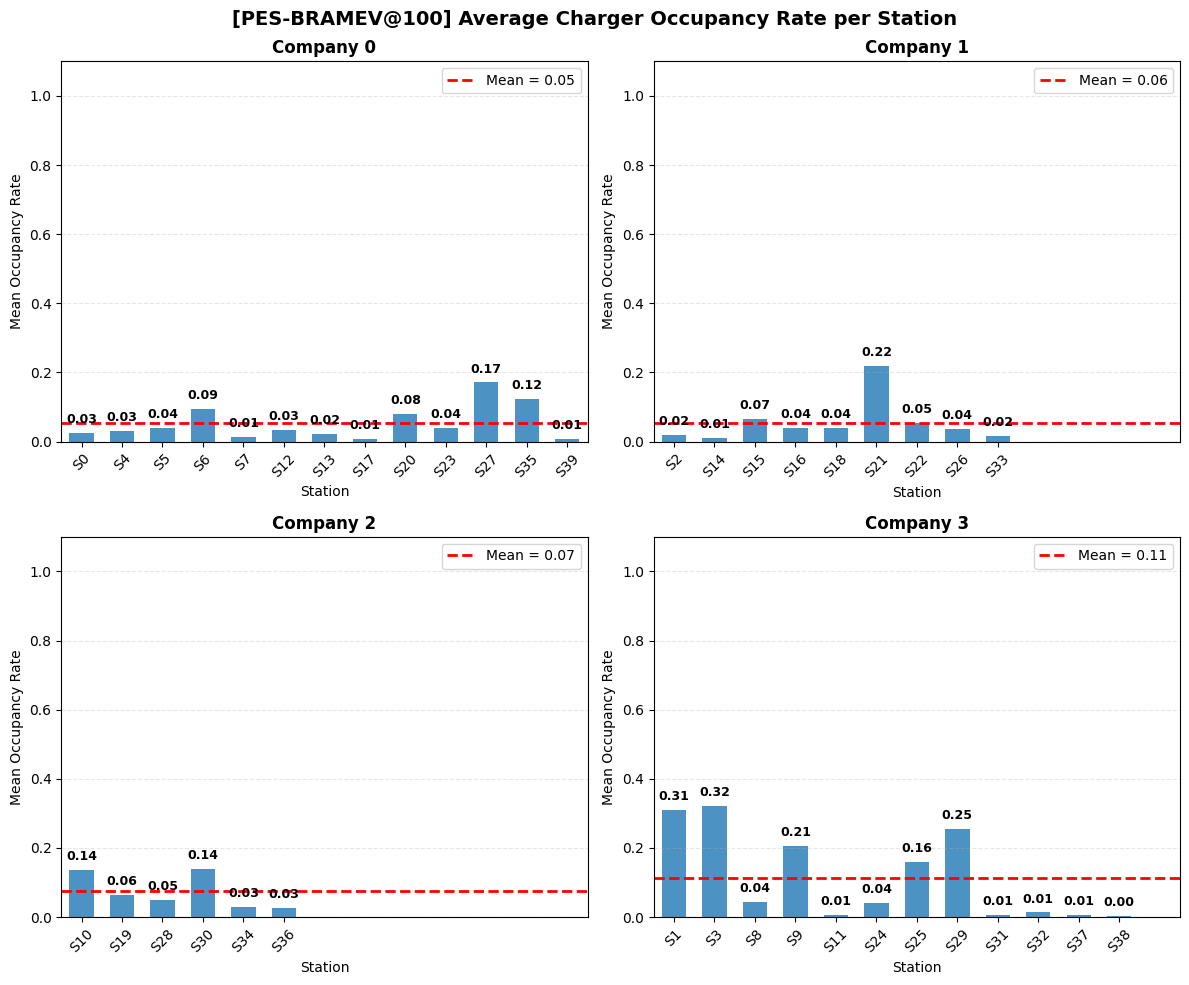

In [79]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

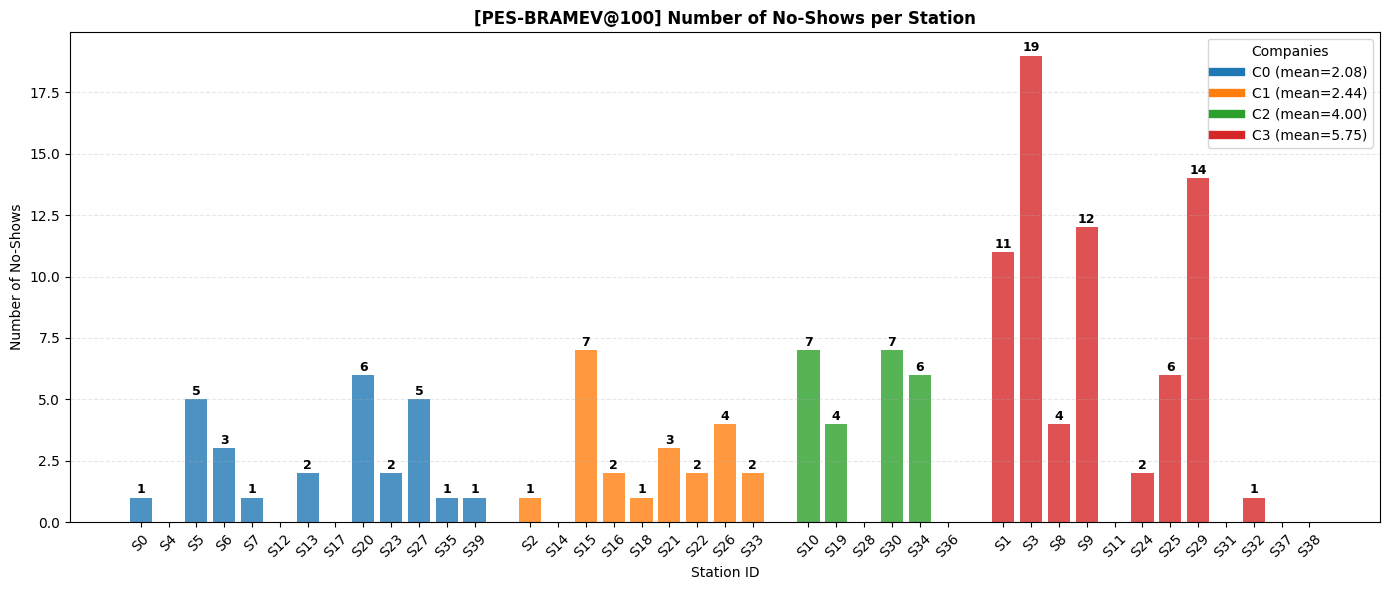

In [80]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [81]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,8,6,1,0,0,0.750000,0.125000,0.0,0.0
1,0,4,5,5,0,0,0,1.000000,0.000000,0.0,0.0
2,0,5,16,11,5,0,0,0.687500,0.312500,0.0,0.0
3,0,6,22,18,3,0,0,0.818182,0.136364,0.0,0.0
4,0,7,3,2,1,0,0,0.666667,0.333333,0.0,0.0
5,0,12,6,6,0,0,0,1.000000,0.000000,0.0,0.0
6,0,13,8,6,2,0,0,0.750000,0.250000,0.0,0.0
7,0,17,2,2,0,0,0,1.000000,0.000000,0.0,0.0
8,0,20,23,17,6,0,0,0.739130,0.260870,0.0,0.0
9,0,23,8,6,2,0,0,0.750000,0.250000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [82]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

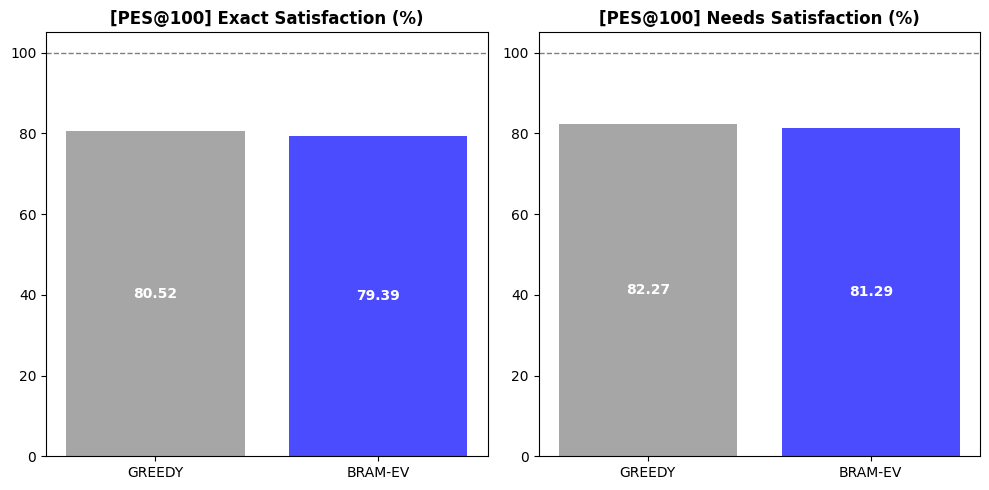

In [83]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

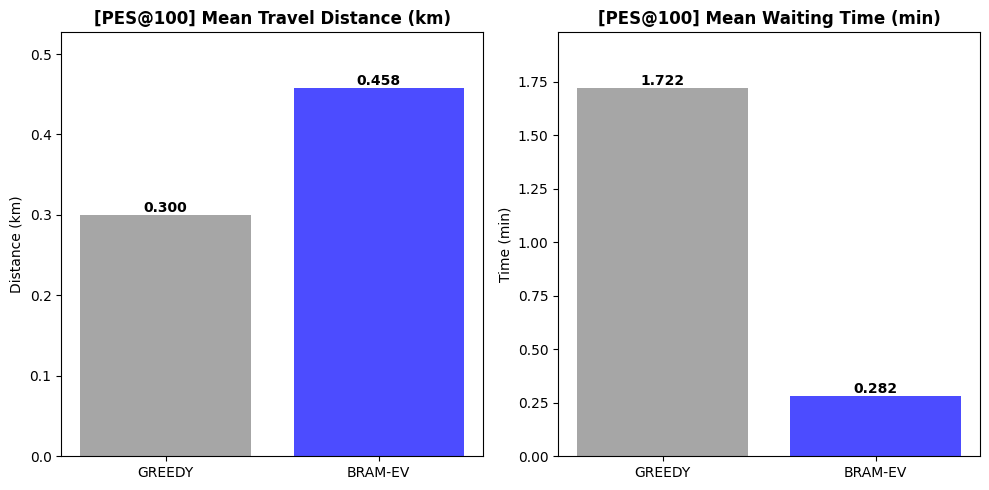

In [84]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

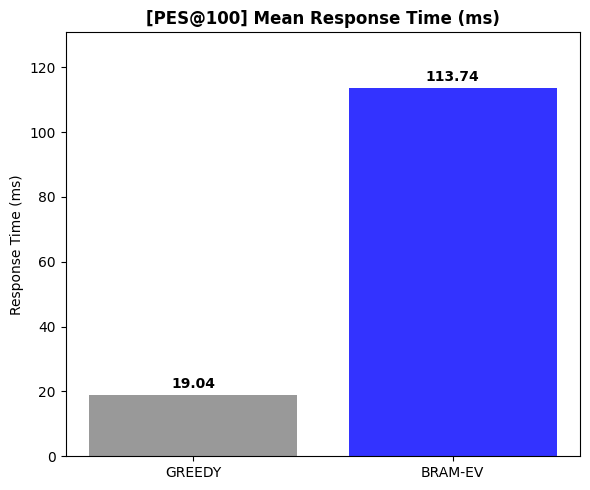

In [85]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [86]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [87]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/150cars


##### *Initialisation*

In [88]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [89]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:36:47.805 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:36:47.945 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:36:48.110 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:36:48.439 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:36:48.686 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:36:49.004 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:36:49.316 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:36:49.573 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:36:49.865 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:36:50.055 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:36:50.443 | IN

##### *Metrics*

In [90]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 33.86 kWh
  Station 1: 1.73 kWh
  Station 2: 14.84 kWh
  Station 3: 0.75 kWh
  Station 4: 38.65 kWh
  Station 5: 65.25 kWh
  Station 6: 8.22 kWh
  Station 7: 37.12 kWh
  Station 8: 79.92 kWh
  Station 9: 29.18 kWh
  Station 10: 66.72 kWh
  Station 11: 2.07 kWh
  Station 12: 7.47 kWh
  Station 13: 16.34 kWh
  Station 14: 44.53 kWh
  Station 15: 29.98 kWh
  Station 16: 175.04 kWh
  Station 17: 83.24 kWh
  Station 18: 2.93 kWh
  Station 19: 7.86 kWh
  Station 20: 62.77 kWh
  Station 21: 181.20 kWh
  Station 22: 25.79 kWh
  Station 23: 7.93 kWh
  Station 24: 12.36 kWh
  Station 25: 6.13 kWh
  Station 26: 141.99 kWh
  Station 27: 5.80 kWh
  Station 28: 70.32 kWh
  Station 29: 20.49 kWh
  Station 30: 14.40 kWh
  Station 31: 19.07 kWh
  Station 32: 195.09 kWh
  Station 33: 16.06 kWh
  Station 34: 1.50 kWh
  Station 35: 20.60 kWh
  Station 36: 4.13 kWh
  Station 37: 5.53 kWh
  Station 38: 34.03 kWh
  Station 39: 24.39 

In [91]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

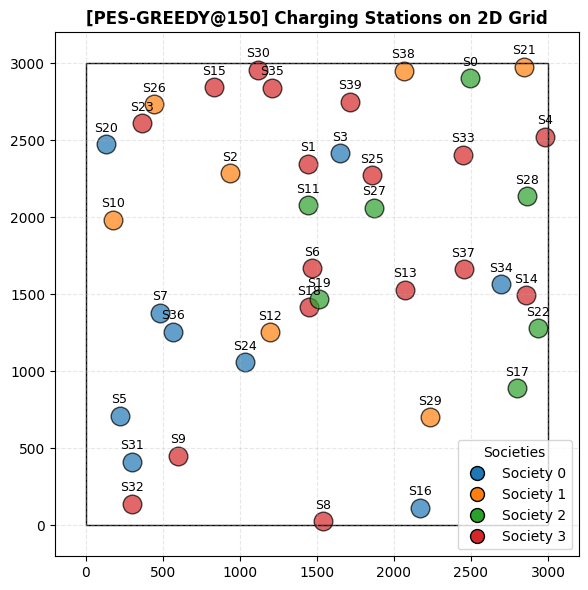

In [92]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

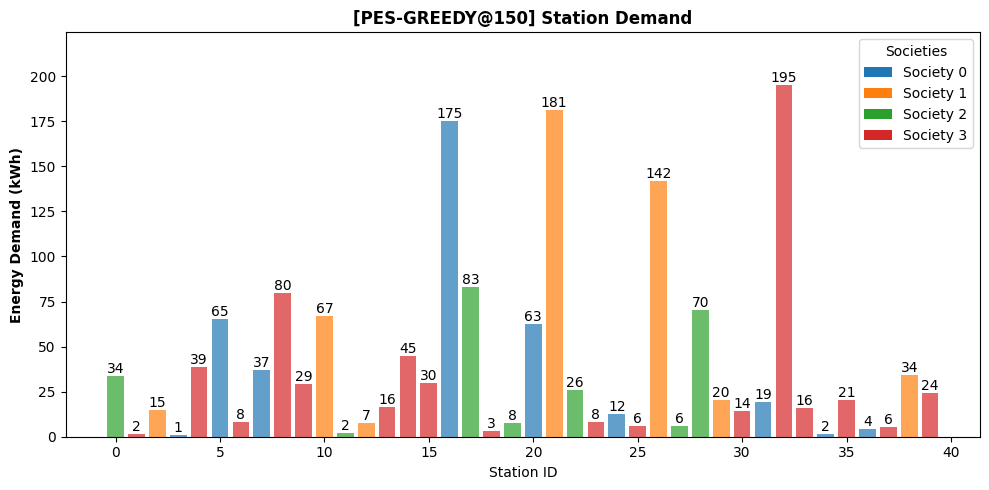

In [93]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

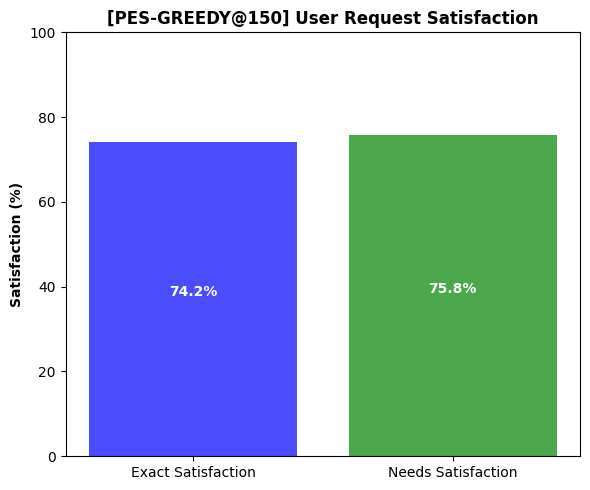

In [94]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

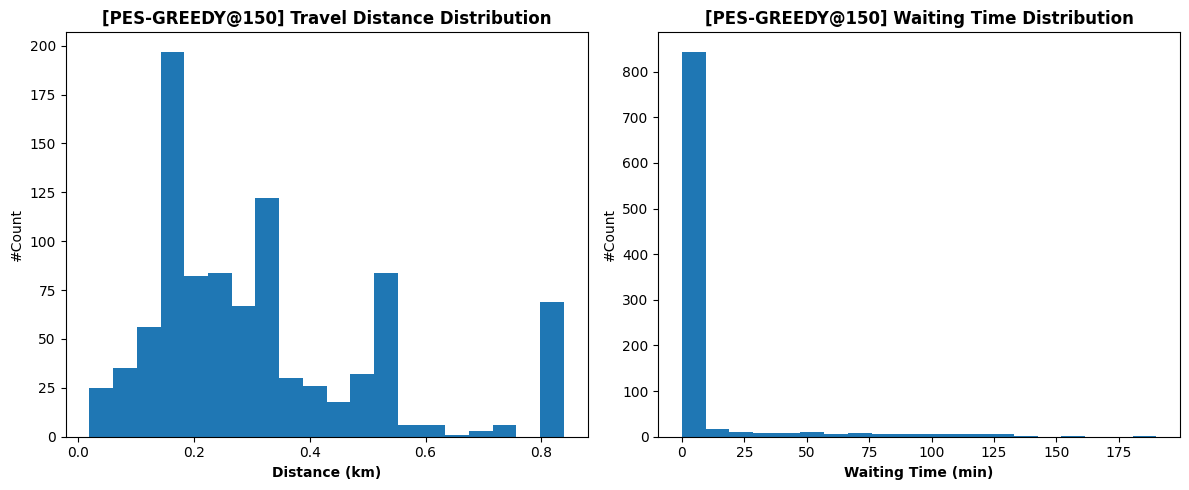

In [95]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

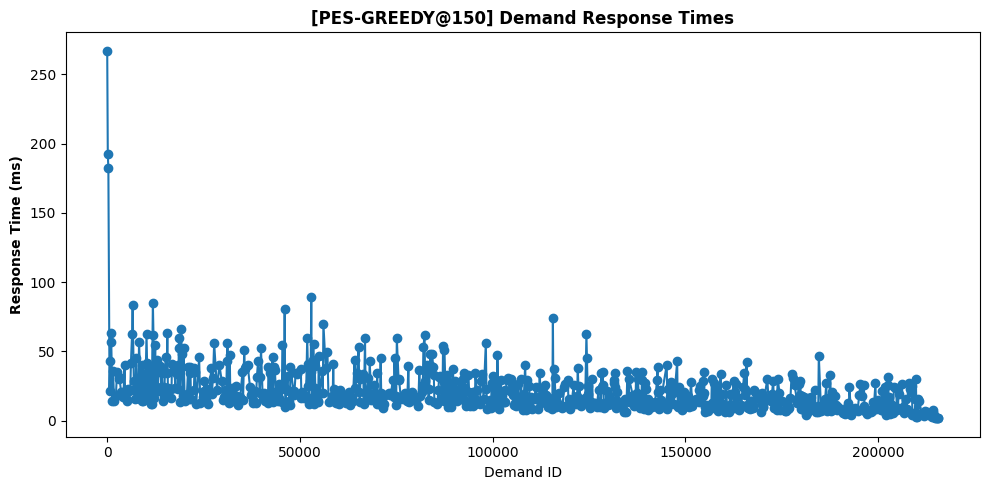

In [96]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

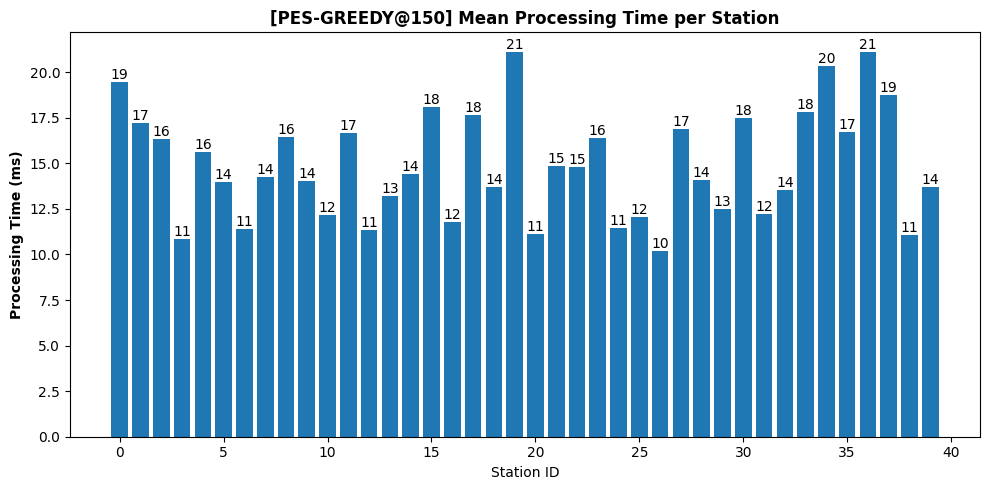

In [97]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [98]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.012500  0.000000  0.000000  0.000000  0.000000   
1            0           5  0.420139  0.305556  0.032639  0.095833  0.054167   
2            0           7  0.344444  0.130556  0.022222  0.000000  0.053472   
3            0          16  0.475000  0.585417  0.568750  0.413194  0.470139   
4            0          20  0.329861  0.256944  0.109722  0.177083       NaN   
5            0          24  0.115972  0.038194  0.000000  0.000000       NaN   
6            0          31  0.119444  0.102083  0.000000  0.000000  0.031944   
7            0          34  0.025000  0.000000  0.000000  0.000000  0.000000   
8            0          36  0.069444  0.000000  0.000000  0.000000  0.000000   
9            1           2  0.209028  0.018056  0.000000  0.000000  0.000000   
10           1          10  0.518056  0.288194  0.088194  0.103472       NaN   
11           1          12  0.112500  0.

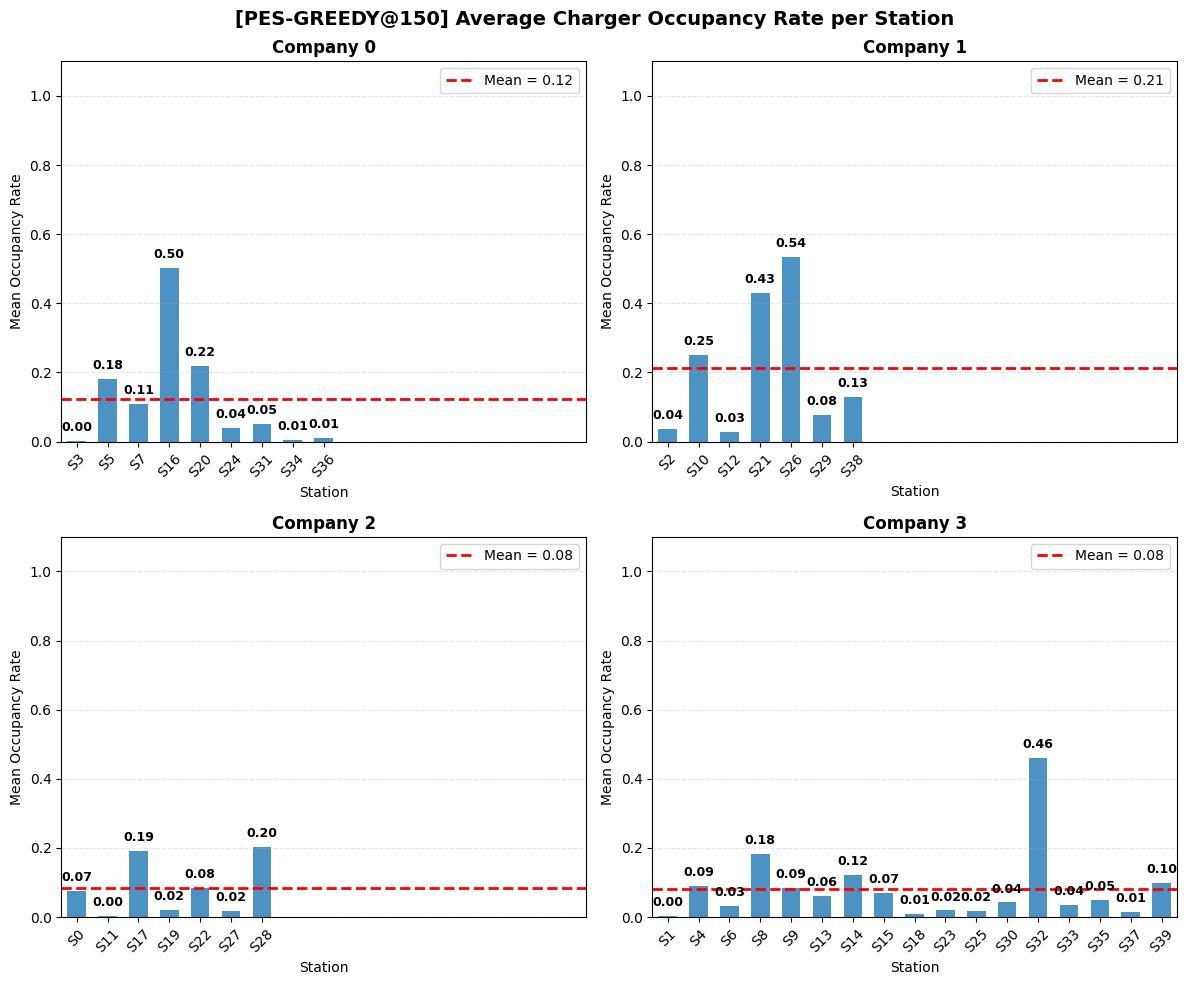

In [99]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

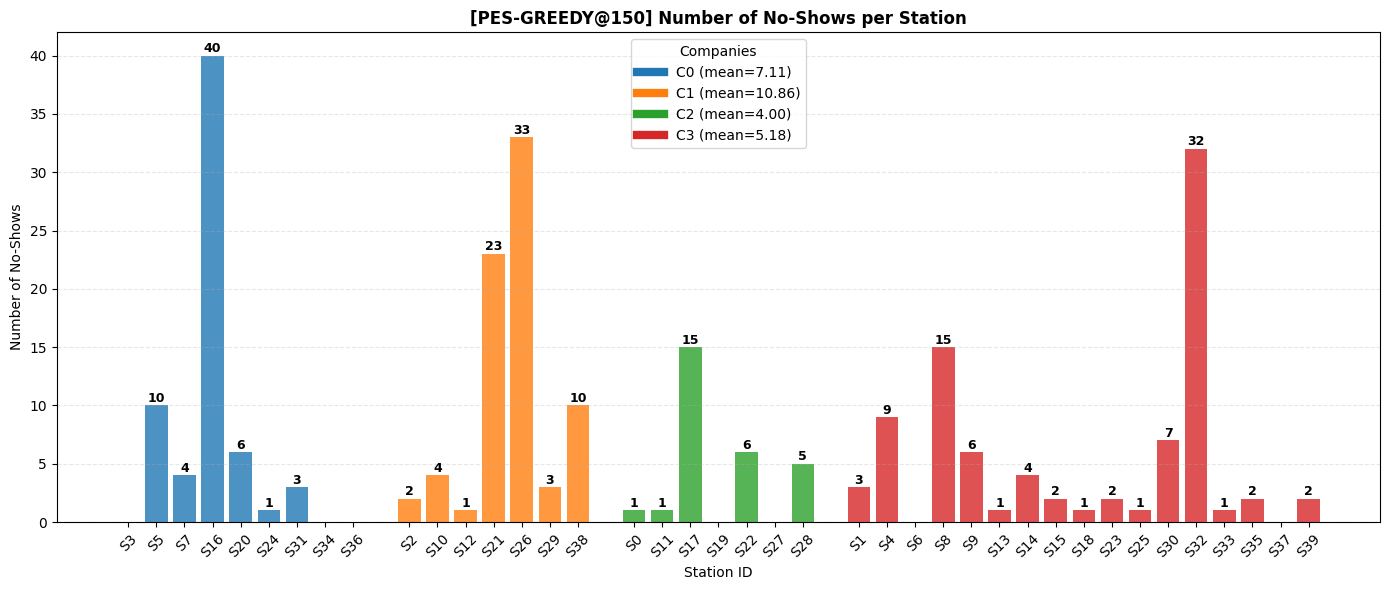

In [100]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [101]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
1,0,5,46,36,10,0,0,0.782609,0.217391,0.000000,0.000000
2,0,7,25,21,4,0,0,0.840000,0.160000,0.000000,0.000000
3,0,16,156,106,40,3,2,0.679487,0.256410,0.019231,0.012821
4,0,20,45,39,6,0,0,0.866667,0.133333,0.000000,0.000000
5,0,24,10,9,1,0,0,0.900000,0.100000,0.000000,0.000000
6,0,31,13,10,3,0,0,0.769231,0.230769,0.000000,0.000000
7,0,34,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
8,0,36,2,2,0,0,0,1.000000,0.000000,0.000000,0.000000
9,1,2,11,9,2,0,0,0.818182,0.181818,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [102]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [103]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [104]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:37:11.450 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:37:11.875 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:37:12.180 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:37:13.380 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:37:14.273 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:37:16.793 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:37:18.428 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:37:20.390 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:37:21.157 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:37:22.881 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:37:24.519 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [105]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 9.70 kWh
  Station 1: 50.94 kWh
  Station 2: 30.78 kWh
  Station 3: 37.15 kWh
  Station 4: 7.16 kWh
  Station 5: 46.58 kWh
  Station 6: 2.07 kWh
  Station 7: 16.26 kWh
  Station 8: 25.02 kWh
  Station 9: 13.62 kWh
  Station 10: 32.39 kWh
  Station 11: 15.86 kWh
  Station 12: 99.95 kWh
  Station 13: 11.84 kWh
  Station 14: 52.31 kWh
  Station 15: 4.62 kWh
  Station 16: 152.57 kWh
  Station 17: 69.08 kWh
  Station 18: 28.51 kWh
  Station 19: 7.02 kWh
  Station 20: 14.13 kWh
  Station 21: 0.00 kWh
  Station 22: 150.87 kWh
  Station 23: 39.77 kWh
  Station 24: 186.65 kWh
  Station 25: 8.27 kWh
  Station 26: 4.75 kWh
  Station 27: 5.75 kWh
  Station 28: 30.53 kWh
  Station 29: 75.48 kWh
  Station 30: 29.41 kWh
  Station 31: 13.02 kWh
  Station 32: 14.03 kWh
  Station 33: 29.21 kWh
  Station 34: 12.07 kWh
  Station 35: 5.38 kWh
  Station 36: 0.00 kWh
  Station 37: 201.97 kWh
  Station 38: 29.48 kWh
  Station 39: 24.3

In [106]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

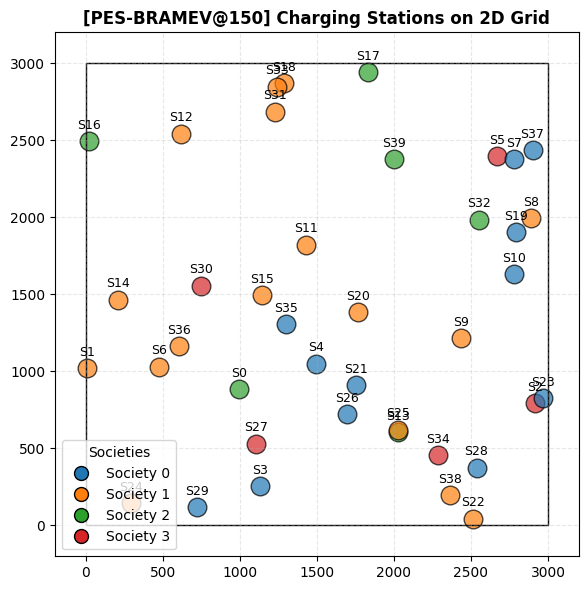

In [107]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

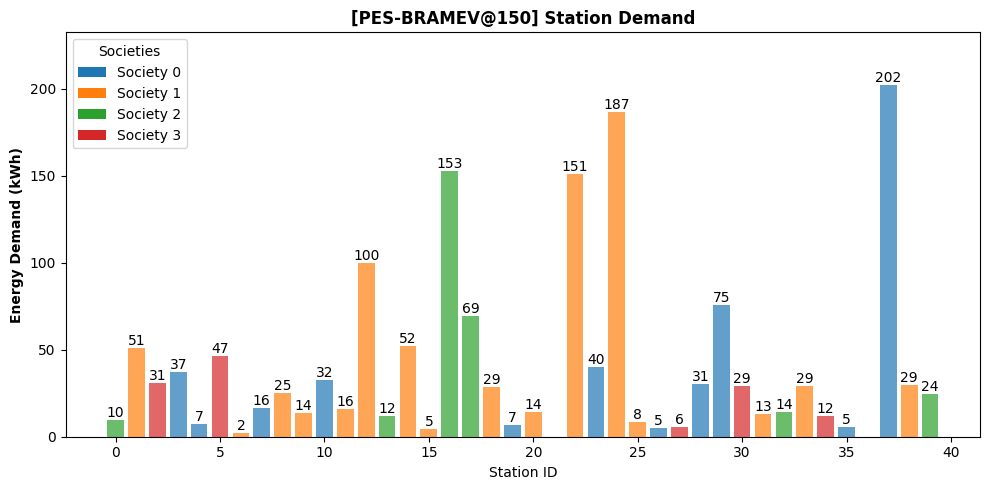

In [108]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

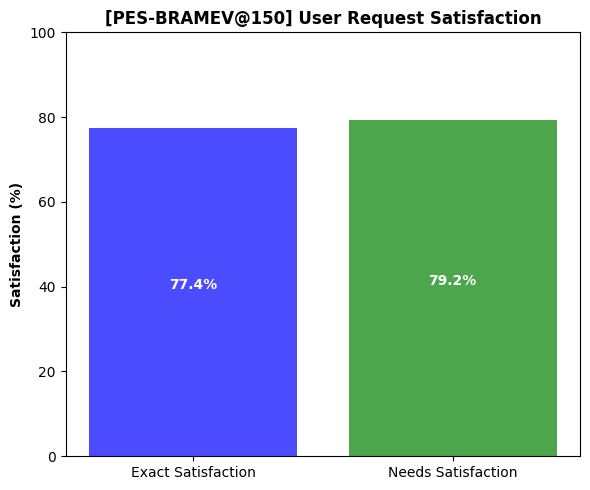

In [109]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

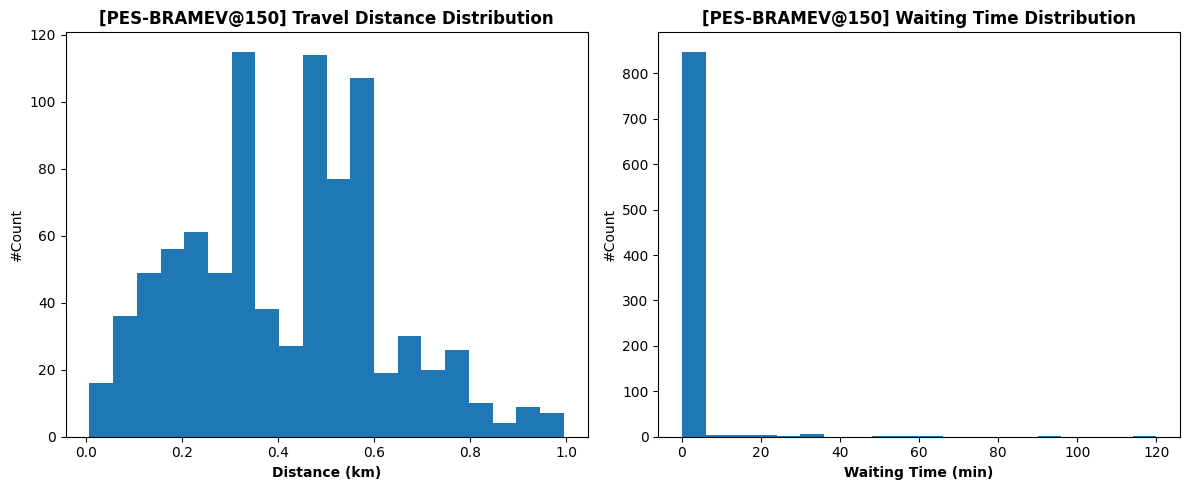

In [110]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

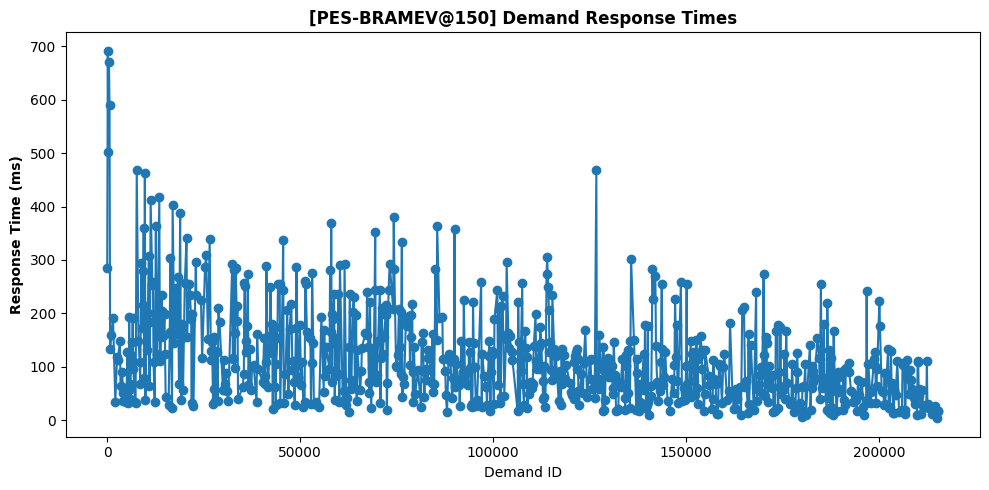

In [111]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

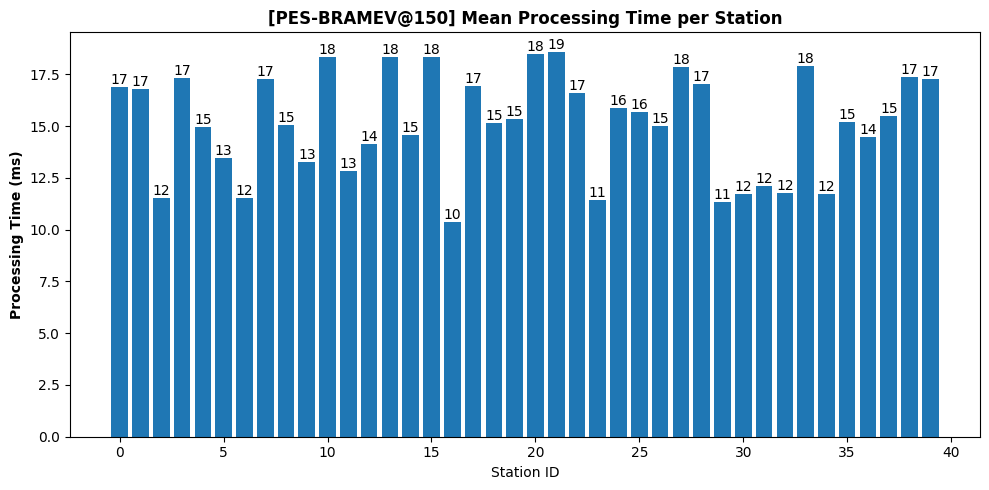

In [112]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

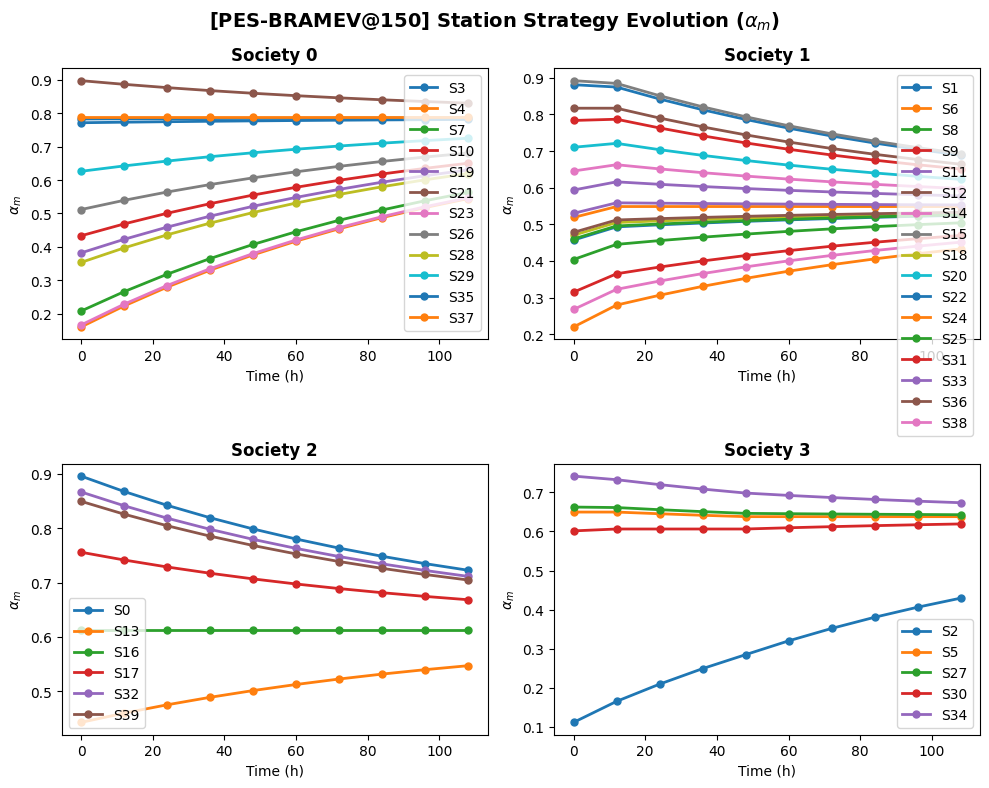

In [113]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [114]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.336806  0.109722  0.009722  0.000000  0.047222   
1            0           4  0.094444  0.000000  0.000000  0.000000  0.000000   
2            0           7  0.172917  0.040972  0.000000  0.000000  0.000000   
3            0          10  0.240972  0.133333  0.000000  0.000000  0.000000   
4            0          19  0.081250  0.000000  0.000000  0.000000  0.000000   
5            0          21  0.000000  0.000000  0.000000  0.000000  0.000000   
6            0          23  0.284722  0.202083  0.050000  0.122222       NaN   
7            0          26  0.041667  0.014583  0.000000  0.000000  0.000000   
8            0          28  0.301389  0.156944  0.000000  0.000000  0.000000   
9            0          29  0.525694  0.285417  0.167361  0.119444       NaN   
10           0          35  0.081944  0.000000  0.000000  0.000000  0.000000   
11           0          37  0.600694  0.

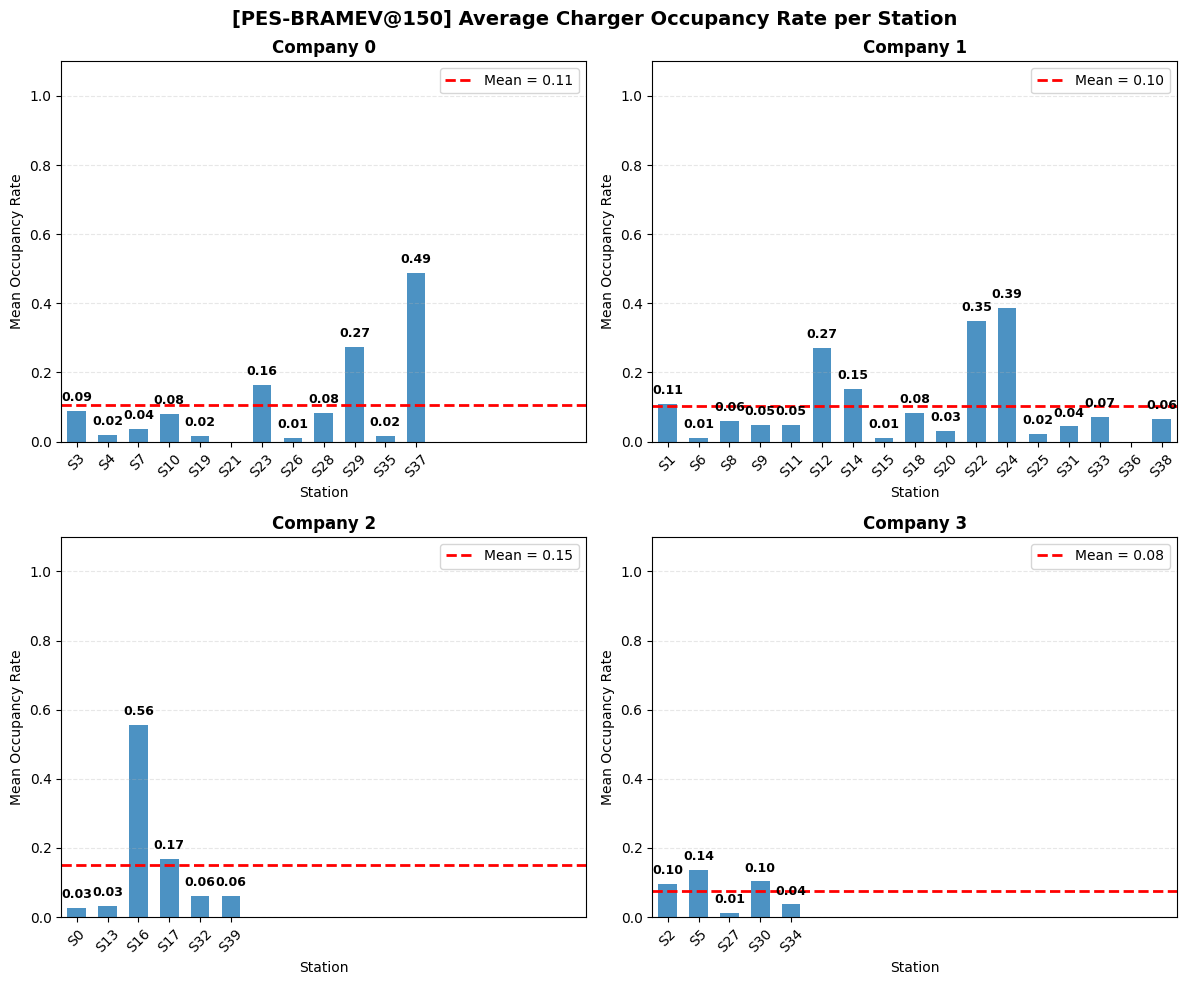

In [115]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

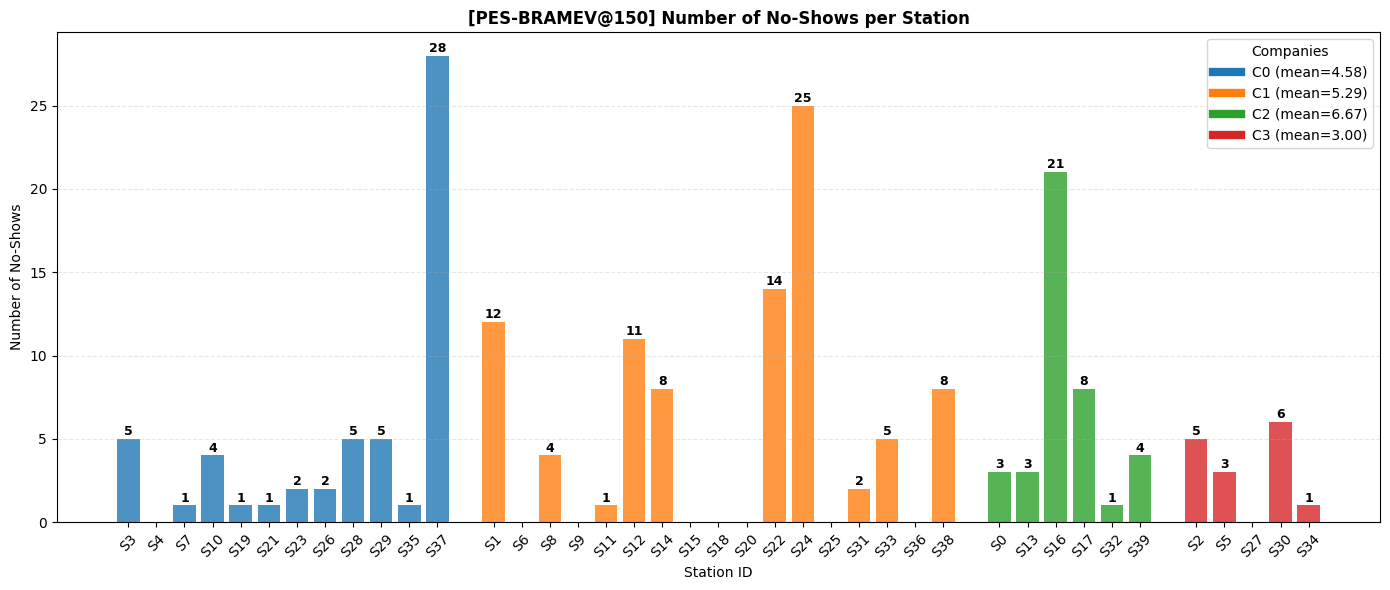

In [116]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [117]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,26,20,5,0,0,0.769231,0.192308,0.0,0.0
1,0,4,5,5,0,0,0,1.000000,0.000000,0.0,0.0
2,0,7,11,10,1,0,0,0.909091,0.090909,0.0,0.0
3,0,10,20,16,4,0,0,0.800000,0.200000,0.0,0.0
4,0,19,5,4,1,0,0,0.800000,0.200000,0.0,0.0
5,0,21,1,0,1,0,0,0.000000,1.000000,0.0,0.0
6,0,23,24,22,2,0,0,0.916667,0.083333,0.0,0.0
7,0,26,5,3,2,0,0,0.600000,0.400000,0.0,0.0
8,0,28,23,18,5,0,0,0.782609,0.217391,0.0,0.0
9,0,29,50,44,5,0,0,0.880000,0.100000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [118]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

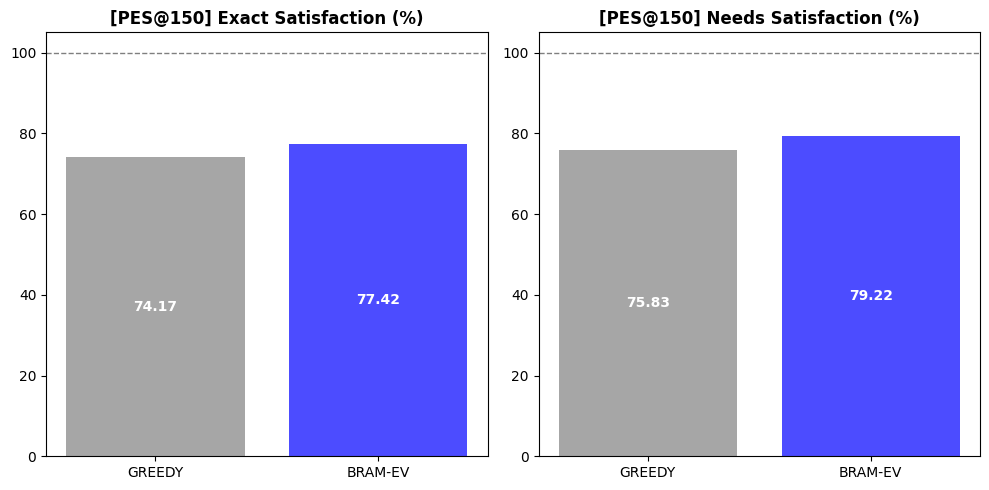

In [119]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

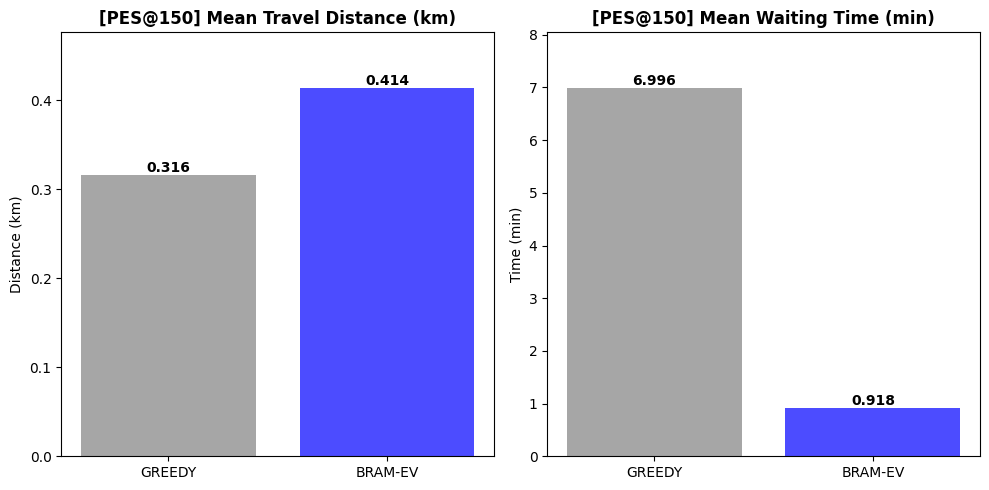

In [120]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

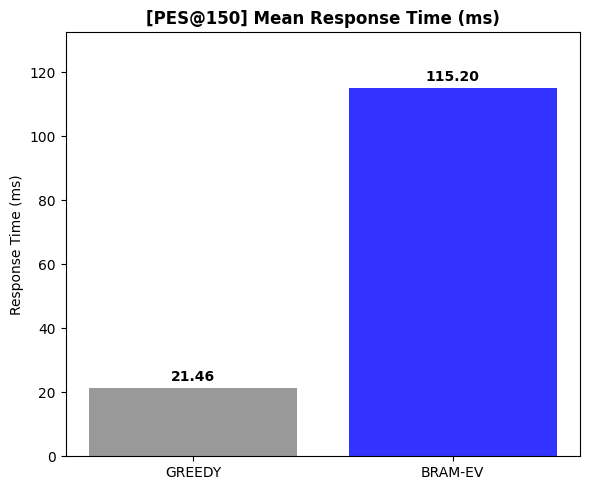

In [121]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [122]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [123]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [124]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [125]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:38:43.075 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:38:43.468 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:38:43.690 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:38:44.096 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:38:44.412 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:38:44.616 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:38:44.917 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:38:45.238 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:38:45.481 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:38:45.899 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:38:46.432 | IN

##### *Metrics*

In [126]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 60.69 kWh
  Station 1: 1.69 kWh
  Station 2: 9.54 kWh
  Station 3: 7.25 kWh
  Station 4: 17.75 kWh
  Station 5: 38.48 kWh
  Station 6: 137.66 kWh
  Station 7: 8.30 kWh
  Station 8: 228.59 kWh
  Station 9: 7.53 kWh
  Station 10: 11.32 kWh
  Station 11: 4.44 kWh
  Station 12: 28.76 kWh
  Station 13: 44.64 kWh
  Station 14: 3.16 kWh
  Station 15: 67.43 kWh
  Station 16: 45.16 kWh
  Station 17: 0.00 kWh
  Station 18: 189.28 kWh
  Station 19: 6.72 kWh
  Station 20: 73.00 kWh
  Station 21: 21.52 kWh
  Station 22: 3.23 kWh
  Station 23: 3.10 kWh
  Station 24: 76.69 kWh
  Station 25: 269.48 kWh
  Station 26: 8.55 kWh
  Station 27: 82.21 kWh
  Station 28: 3.84 kWh
  Station 29: 73.47 kWh
  Station 30: 46.97 kWh
  Station 31: 5.80 kWh
  Station 32: 15.51 kWh
  Station 33: 12.07 kWh
  Station 34: 101.69 kWh
  Station 35: 139.67 kWh
  Station 36: 89.78 kWh
  Station 37: 11.14 kWh
  Station 38: 88.14 kWh
  Station 39: 22.03

In [127]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

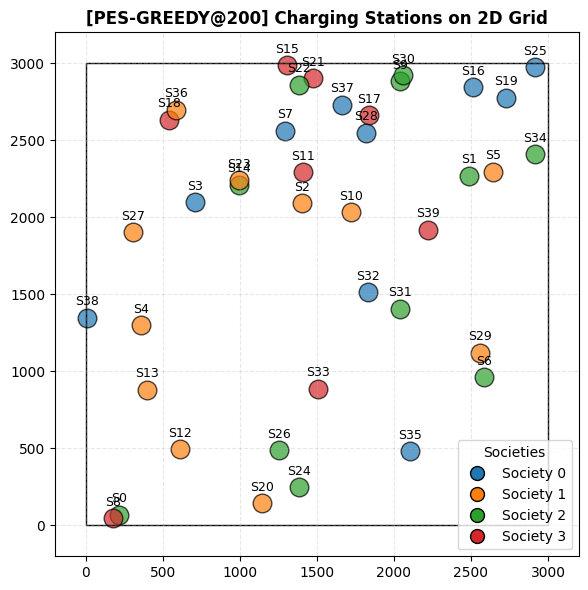

In [128]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

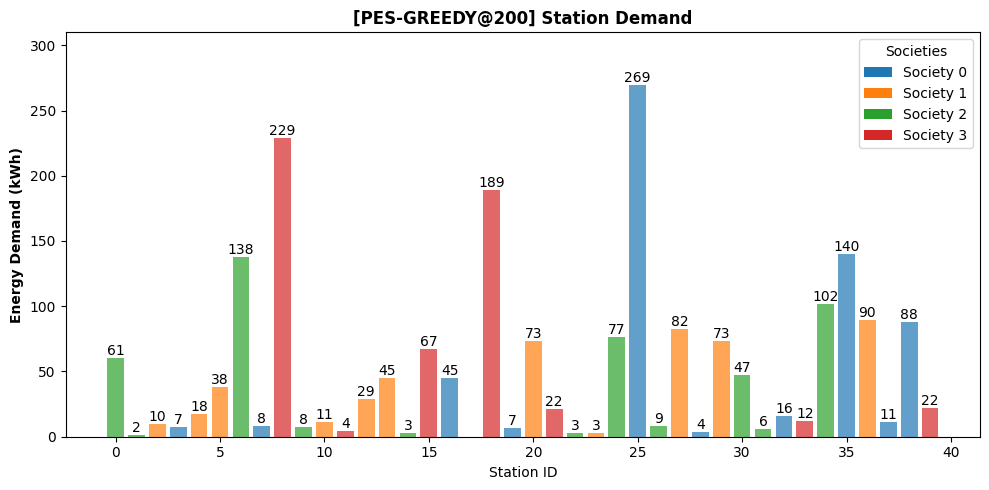

In [129]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

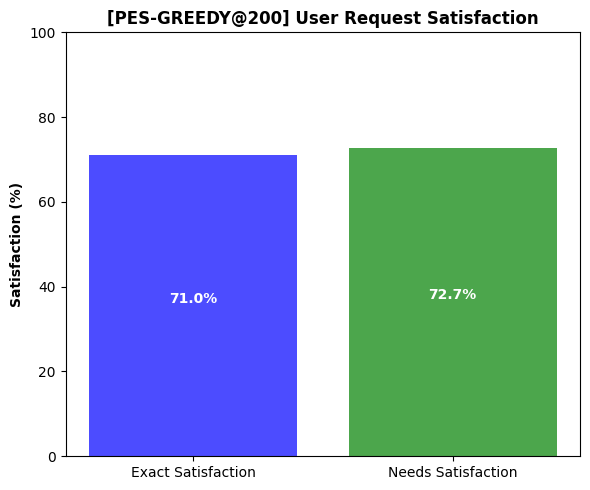

In [130]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

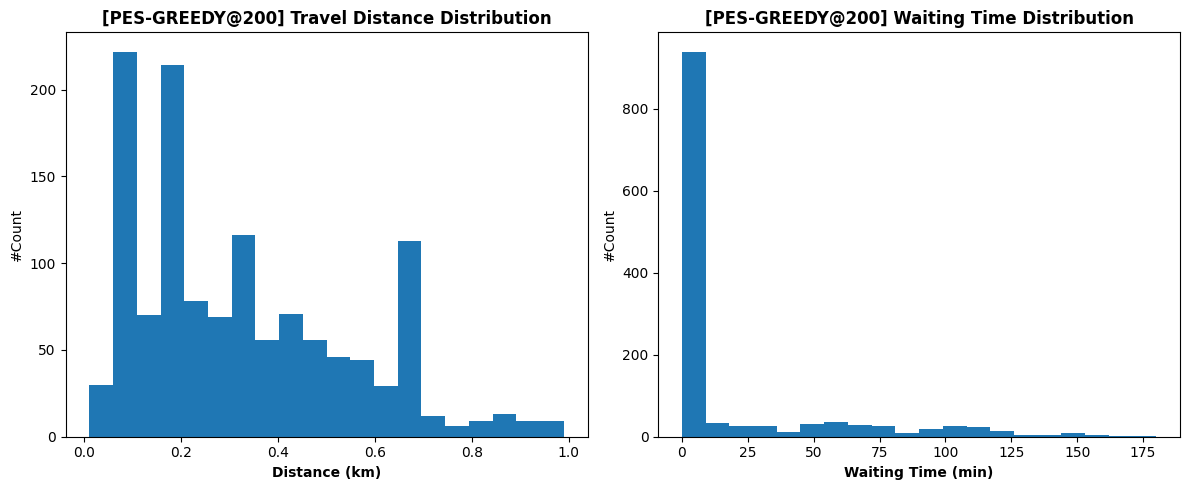

In [131]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

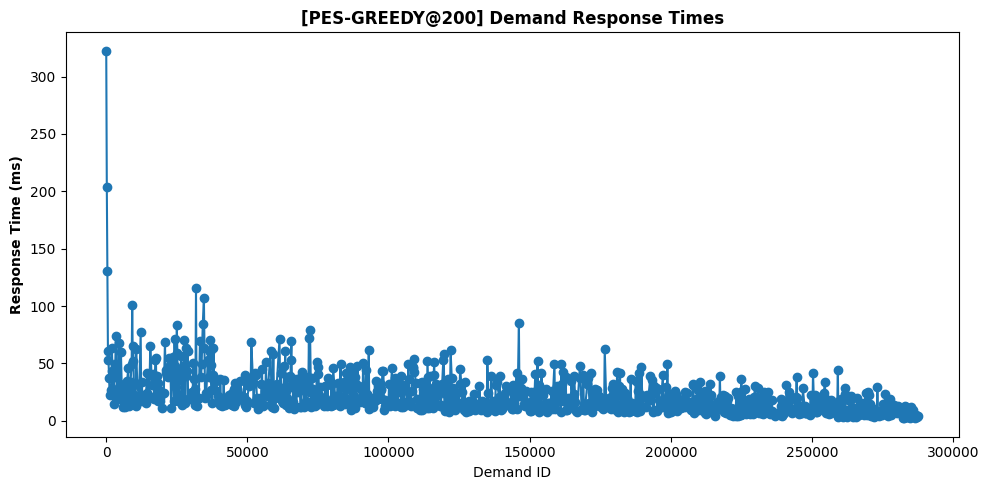

In [132]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

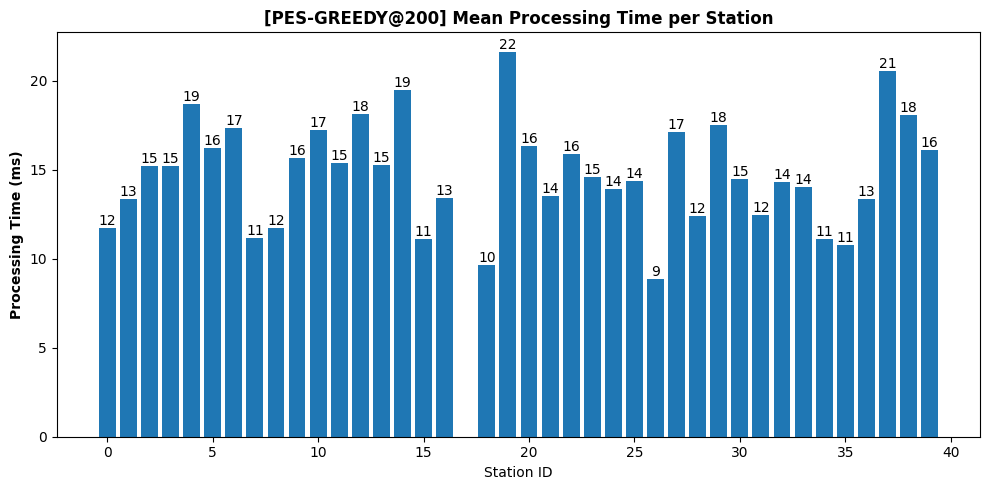

In [133]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [134]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.088194  0.034722  0.000000  0.000000  0.000000   
1            0           7  0.129167  0.000000  0.000000  0.000000       NaN   
2            0          16  0.406944  0.186806  0.054167  0.026389  0.000000   
3            0          19  0.097222  0.022917  0.000000  0.000000  0.000000   
4            0          25  0.608333  0.718056  0.670833  0.591667  0.663194   
5            0          28  0.056250  0.007639  0.000000  0.000000       NaN   
6            0          32  0.188194  0.038889  0.000000  0.000000  0.000000   
7            0          35  0.597917  0.531250  0.438194  0.446528       NaN   
8            0          37  0.176389  0.000000  0.000000  0.000000  0.000000   
9            0          38  0.555556  0.356944  0.077083  0.000000  0.051389   
10           1           2  0.105556  0.025694  0.000000  0.000000  0.000000   
11           1           4  0.222917  0.

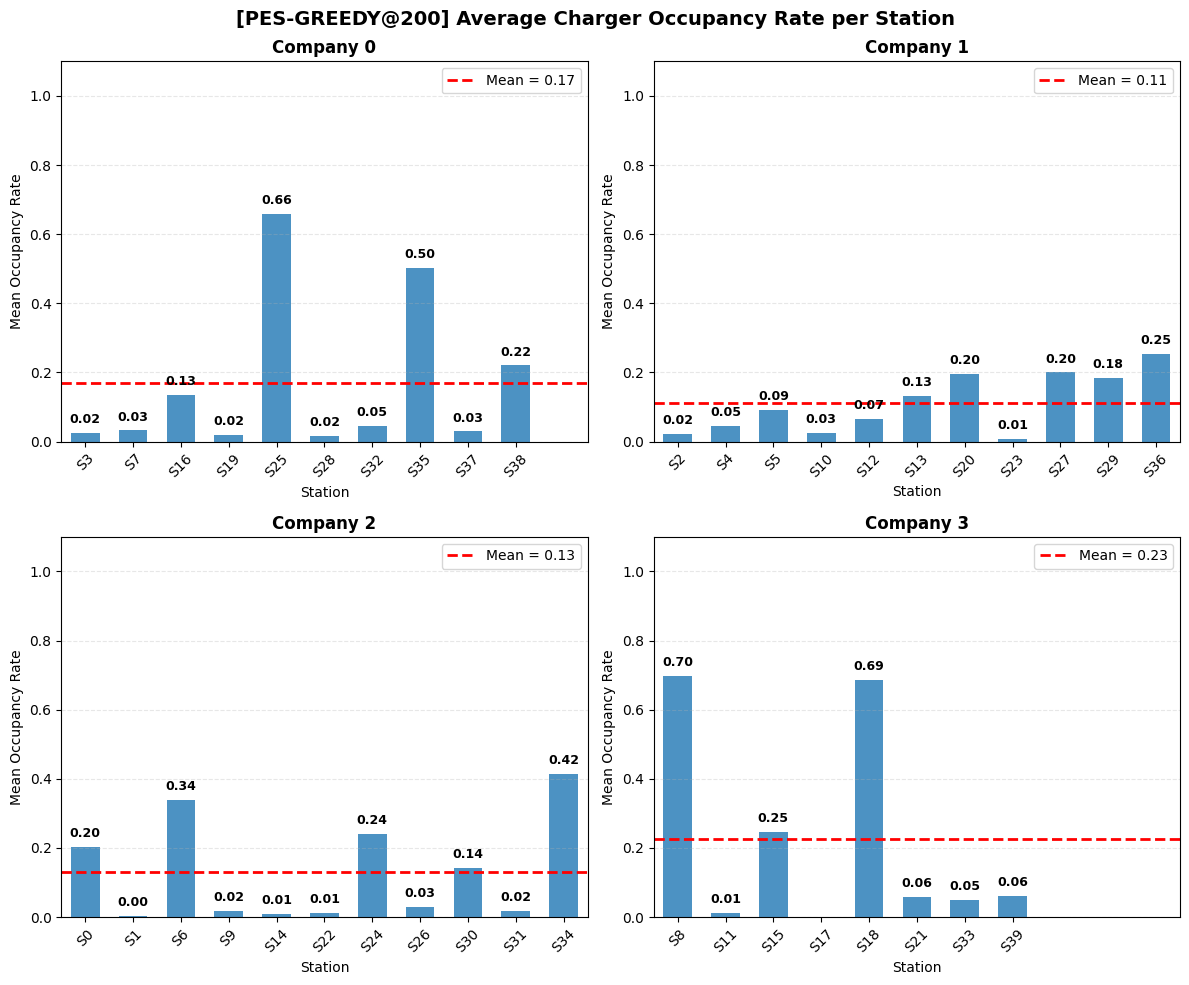

In [135]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

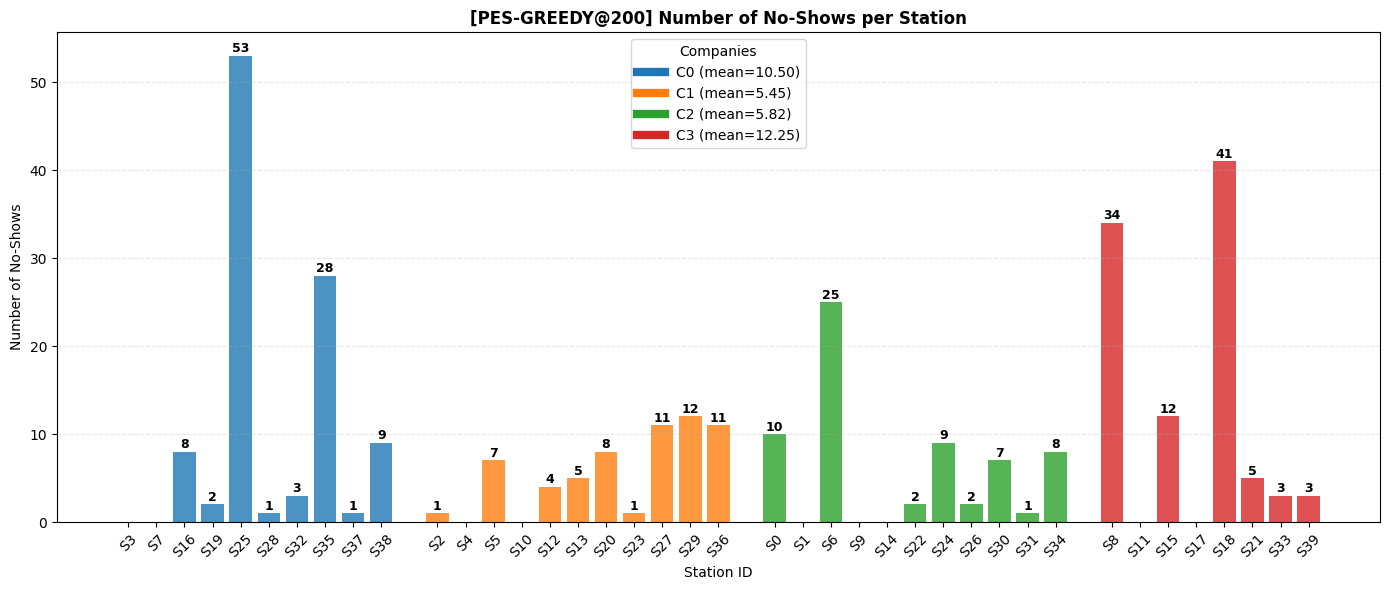

In [136]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [137]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,5,5,0,0,0,1.000000,0.000000,0.000000,0.000000
1,0,7,6,5,0,0,0,0.833333,0.000000,0.000000,0.000000
2,0,16,35,26,8,0,0,0.742857,0.228571,0.000000,0.000000
3,0,19,6,4,2,0,0,0.666667,0.333333,0.000000,0.000000
4,0,25,231,170,53,6,1,0.735931,0.229437,0.025974,0.004329
5,0,28,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
6,0,32,11,8,3,0,0,0.727273,0.272727,0.000000,0.000000
7,0,35,116,83,28,1,1,0.715517,0.241379,0.008621,0.008621
8,0,37,6,5,1,0,0,0.833333,0.166667,0.000000,0.000000
9,0,38,59,49,9,0,0,0.830508,0.152542,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [138]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [139]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [140]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:39:16.151 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:39:21.049 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:39:22.916 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:39:24.596 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:39:25.968 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:39:27.746 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:39:29.026 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:39:30.513 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:39:32.893 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:39:35.910 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:39:37.342 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [141]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 17.25 kWh
  Station 1: 155.74 kWh
  Station 2: 186.62 kWh
  Station 3: 5.68 kWh
  Station 4: 7.12 kWh
  Station 5: 16.10 kWh
  Station 6: 202.12 kWh
  Station 7: 19.02 kWh
  Station 8: 74.87 kWh
  Station 9: 10.98 kWh
  Station 10: 116.82 kWh
  Station 11: 29.67 kWh
  Station 12: 54.62 kWh
  Station 13: 185.78 kWh
  Station 14: 15.02 kWh
  Station 15: 6.58 kWh
  Station 16: 52.55 kWh
  Station 17: 239.70 kWh
  Station 18: 80.70 kWh
  Station 19: 6.55 kWh
  Station 20: 8.53 kWh
  Station 21: 45.27 kWh
  Station 22: 46.73 kWh
  Station 23: 107.50 kWh
  Station 24: 8.06 kWh
  Station 25: 67.95 kWh
  Station 26: 11.15 kWh
  Station 27: 17.81 kWh
  Station 28: 6.09 kWh
  Station 29: 26.42 kWh
  Station 30: 44.42 kWh
  Station 31: 5.10 kWh
  Station 32: 10.39 kWh
  Station 33: 6.15 kWh
  Station 34: 47.74 kWh
  Station 35: 17.76 kWh
  Station 36: 53.20 kWh
  Station 37: 60.14 kWh
  Station 38: 81.38 kWh
  Station 39:

In [142]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

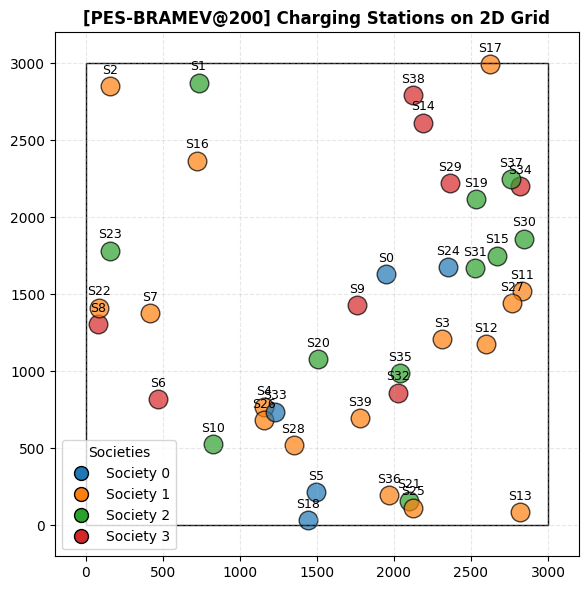

In [143]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

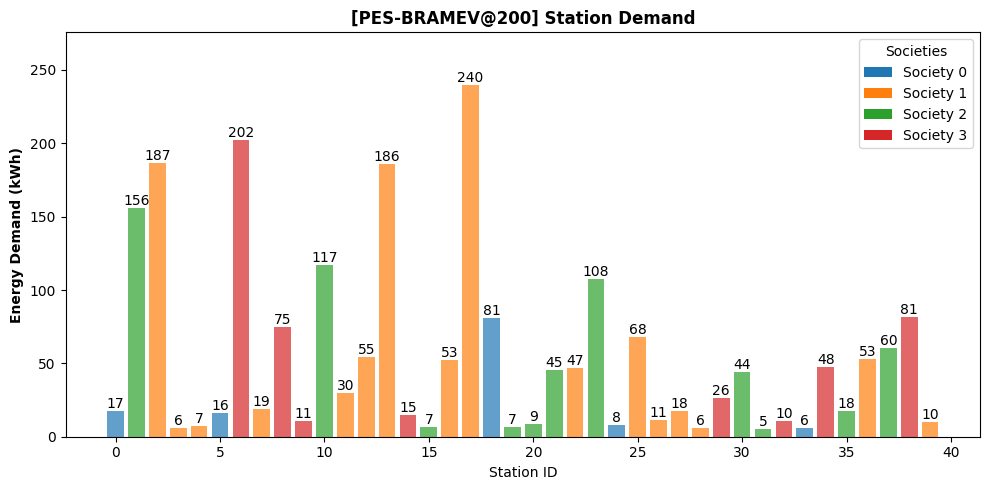

In [144]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

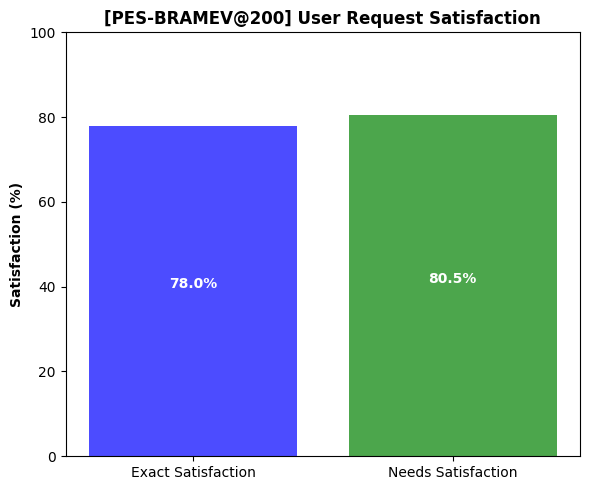

In [145]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

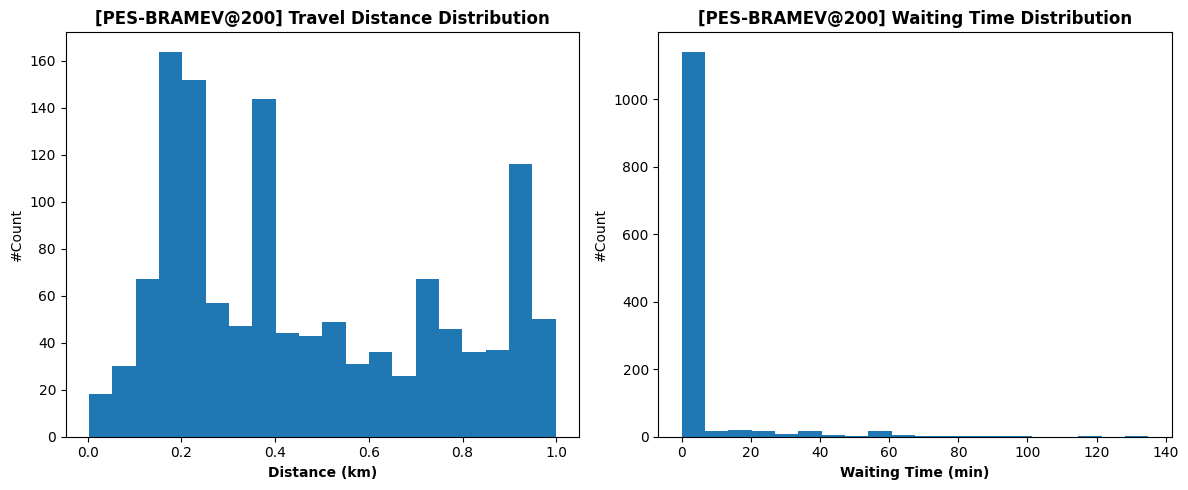

In [146]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

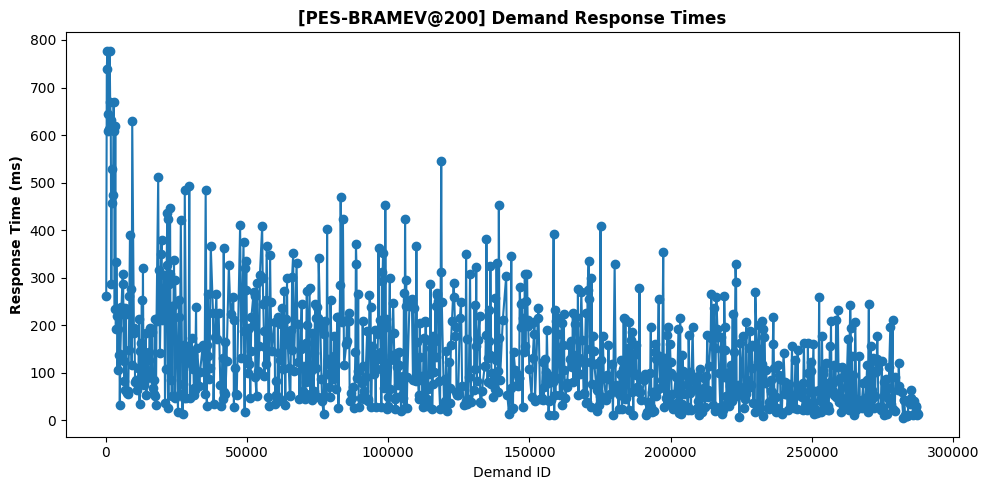

In [147]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

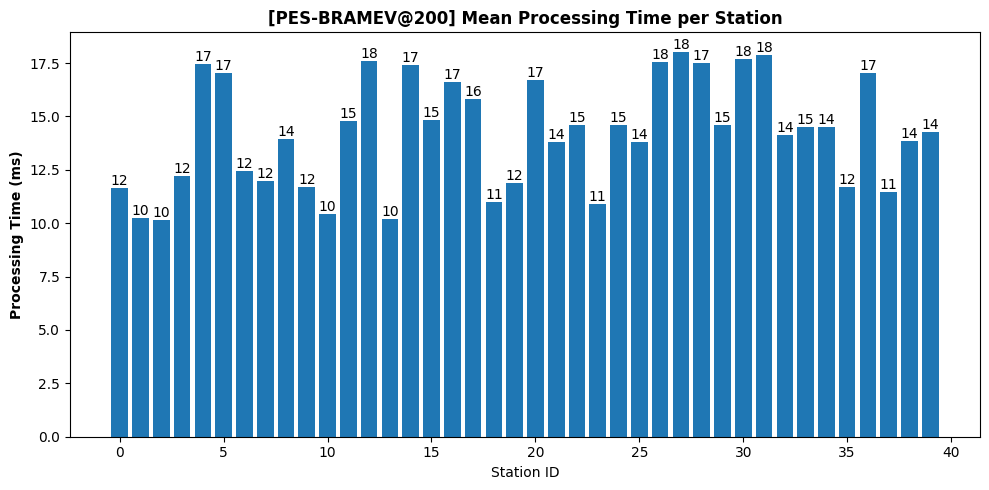

In [148]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

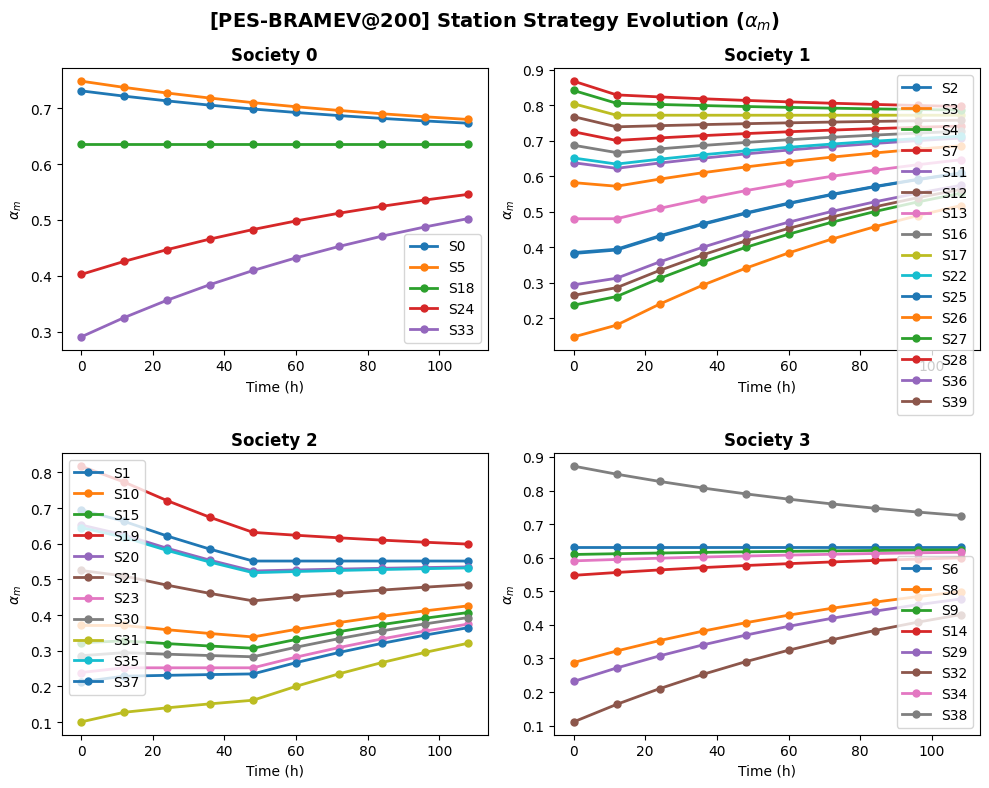

In [149]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [150]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.228472  0.000000  0.000000  0.023611       NaN   
1            0           5  0.224306  0.026389  0.000000  0.000000  0.000000   
2            0          18  0.542361  0.259722  0.204167  0.156944       NaN   
3            0          24  0.079861  0.044444  0.000000  0.000000  0.000000   
4            0          33  0.085417  0.000000  0.000000  0.000000  0.000000   
5            1           2  0.795139  0.679167  0.606944  0.572222       NaN   
6            1           3  0.077778  0.034722  0.000000  0.000000       NaN   
7            1           4  0.090972  0.000000  0.000000  0.000000  0.000000   
8            1           7  0.161111  0.070833  0.015972  0.065972       NaN   
9            1          11  0.361111  0.135417  0.000000  0.000000  0.000000   
10           1          12  0.504861  0.220139  0.056944  0.000000  0.000000   
11           1          13  0.733333  0.

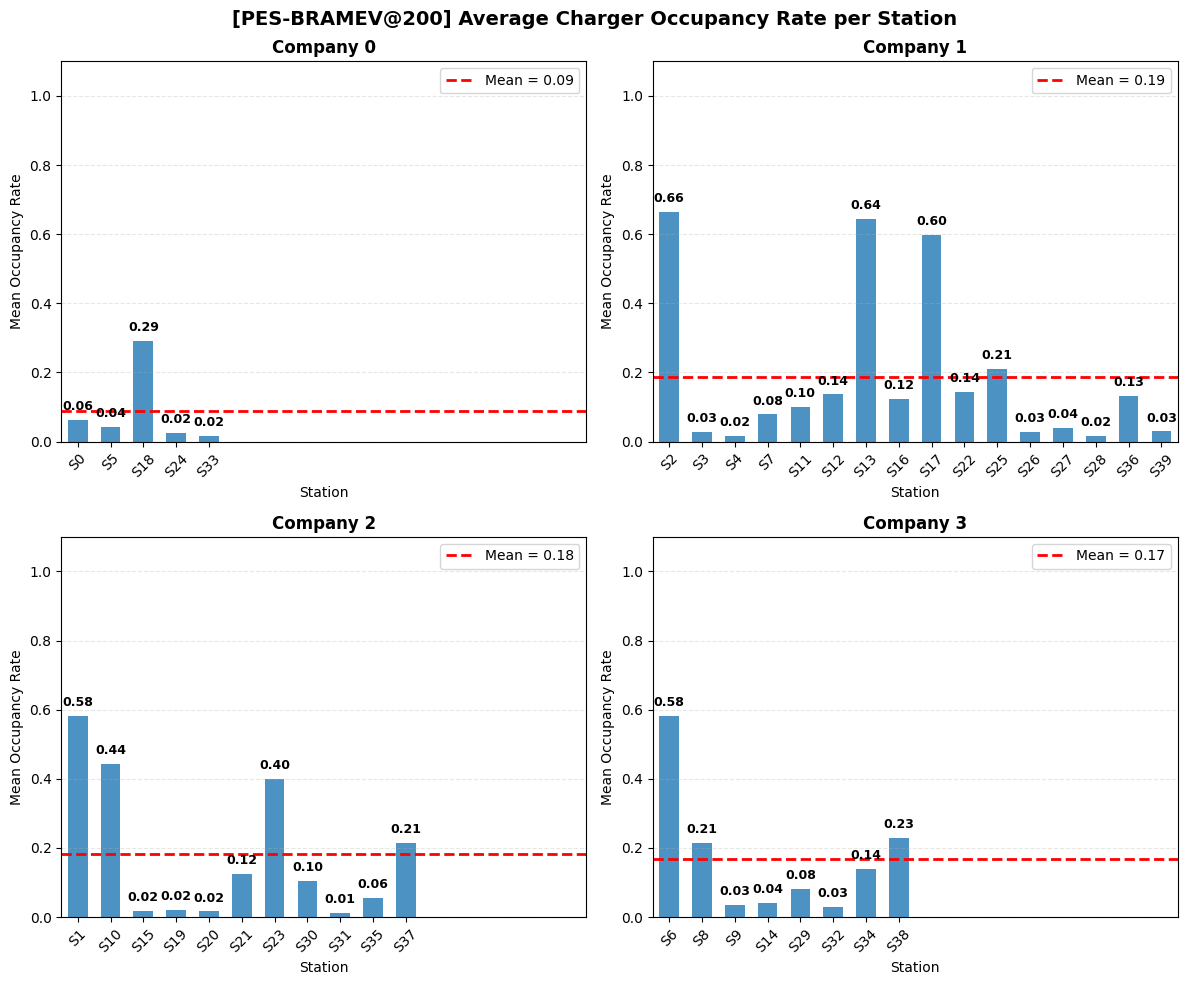

In [151]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

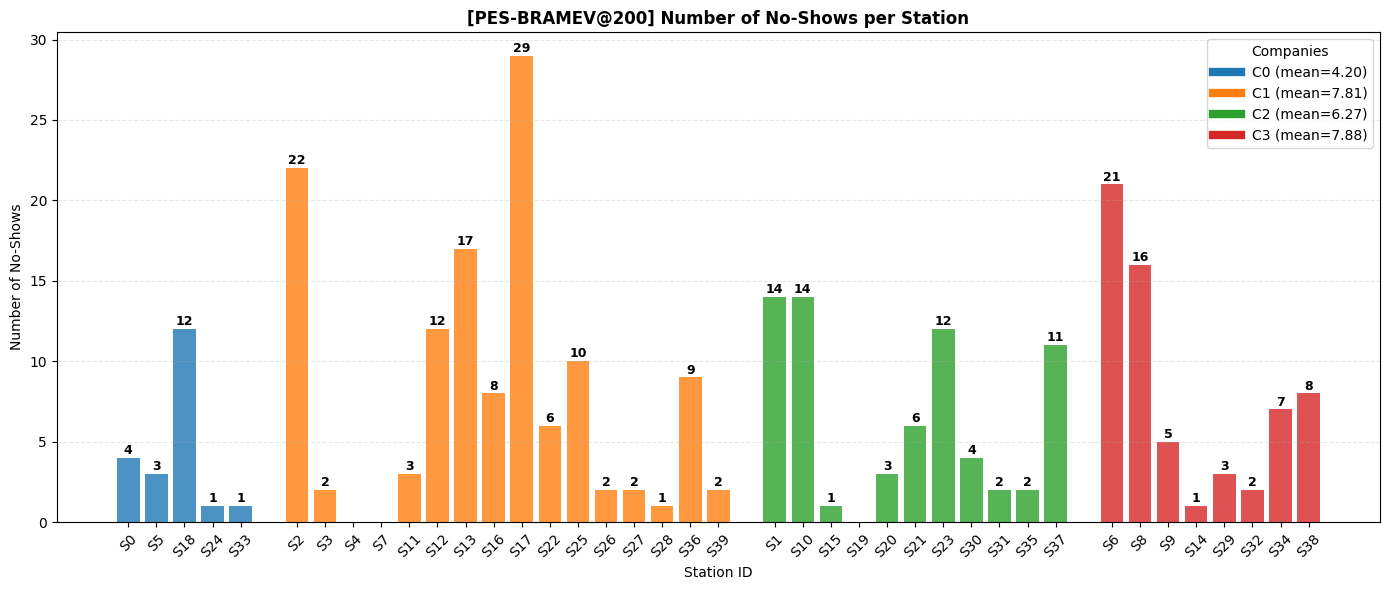

In [152]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [153]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,14,10,4,0,0,0.714286,0.285714,0.0,0.000000
1,0,5,13,10,3,0,0,0.769231,0.230769,0.0,0.000000
2,0,18,58,46,12,0,0,0.793103,0.206897,0.0,0.000000
3,0,24,6,5,1,0,0,0.833333,0.166667,0.0,0.000000
4,0,33,4,3,1,0,0,0.750000,0.250000,0.0,0.000000
5,1,2,133,110,22,0,0,0.827068,0.165414,0.0,0.000000
6,1,3,5,3,2,0,0,0.600000,0.400000,0.0,0.000000
7,1,4,4,4,0,0,0,1.000000,0.000000,0.0,0.000000
8,1,7,13,12,0,0,0,0.923077,0.000000,0.0,0.000000
9,1,11,21,18,3,0,0,0.857143,0.142857,0.0,0.000000


#### **COMPARISON**

##### *Params*

In [154]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

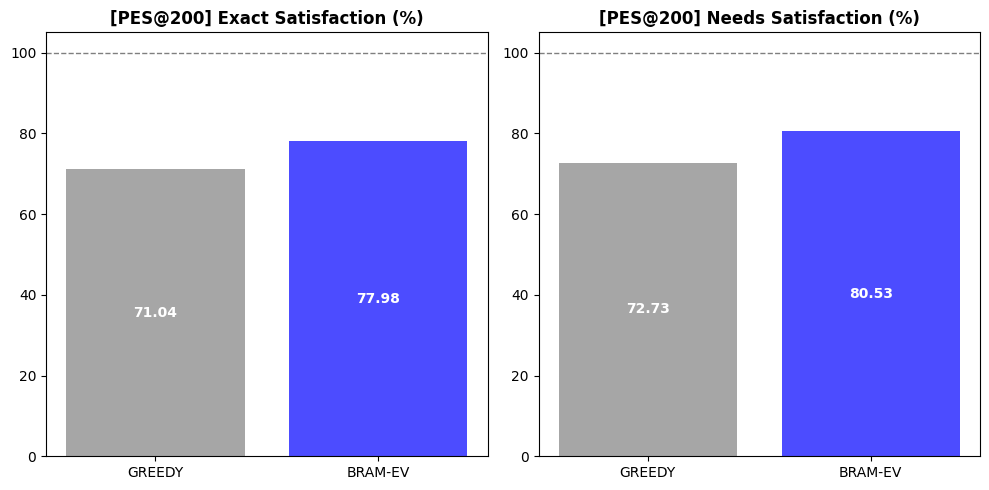

In [155]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

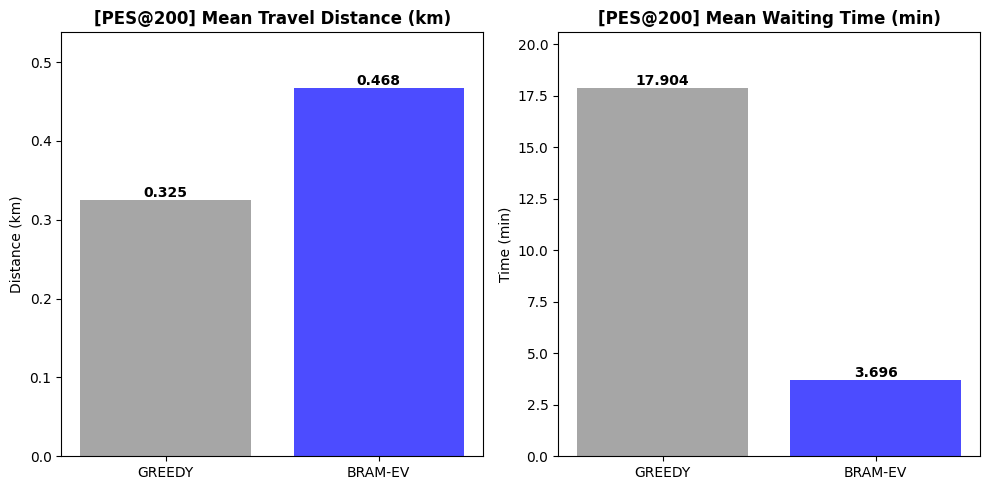

In [156]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

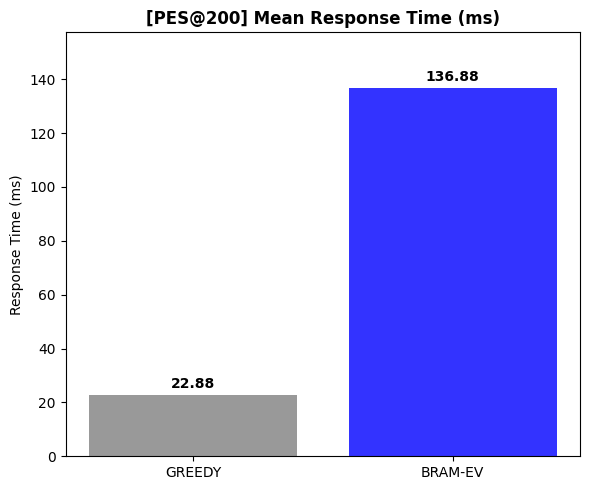

In [157]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [158]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [159]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [160]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [161]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:41:31.351 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-13 23:41:31.722 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-13 23:41:32.070 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-13 23:41:32.474 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-13 23:41:33.048 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-13 23:41:33.384 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-13 23:41:33.887 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-13 23:41:34.253 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-13 23:41:34.591 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-13 23:41:35.015 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-13 23:41:35.354 | IN

##### *Metrics*

In [162]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.50 kWh
  Station 1: 205.98 kWh
  Station 2: 12.38 kWh
  Station 3: 82.33 kWh
  Station 4: 20.33 kWh
  Station 5: 29.70 kWh
  Station 6: 5.09 kWh
  Station 7: 1.47 kWh
  Station 8: 0.85 kWh
  Station 9: 13.45 kWh
  Station 10: 113.42 kWh
  Station 11: 13.33 kWh
  Station 12: 70.16 kWh
  Station 13: 94.64 kWh
  Station 14: 12.93 kWh
  Station 15: 27.86 kWh
  Station 16: 68.97 kWh
  Station 17: 43.16 kWh
  Station 18: 36.61 kWh
  Station 19: 0.00 kWh
  Station 20: 292.14 kWh
  Station 21: 10.57 kWh
  Station 22: 111.67 kWh
  Station 23: 89.92 kWh
  Station 24: 29.62 kWh
  Station 25: 60.33 kWh
  Station 26: 18.28 kWh
  Station 27: 15.17 kWh
  Station 28: 138.85 kWh
  Station 29: 303.09 kWh
  Station 30: 11.19 kWh
  Station 31: 56.89 kWh
  Station 32: 126.16 kWh
  Station 33: 60.88 kWh
  Station 34: 65.90 kWh
  Station 35: 235.53 kWh
  Station 36: 25.43 kWh
  Station 37: 12.24 kWh
  Station 38: 95.87 kWh
  Statio

In [163]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

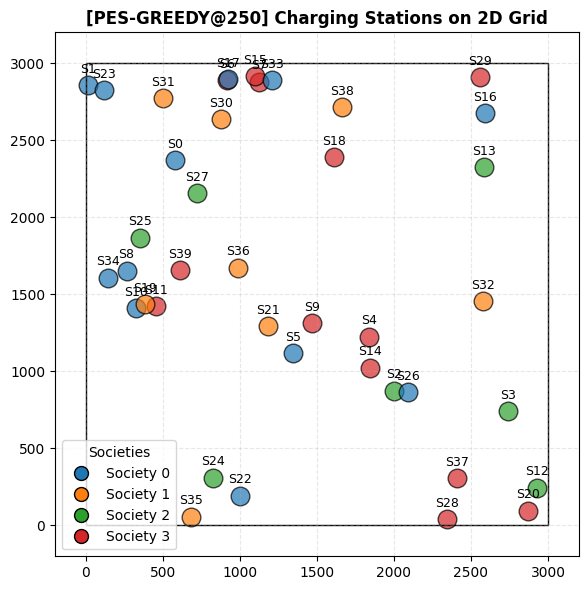

In [164]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

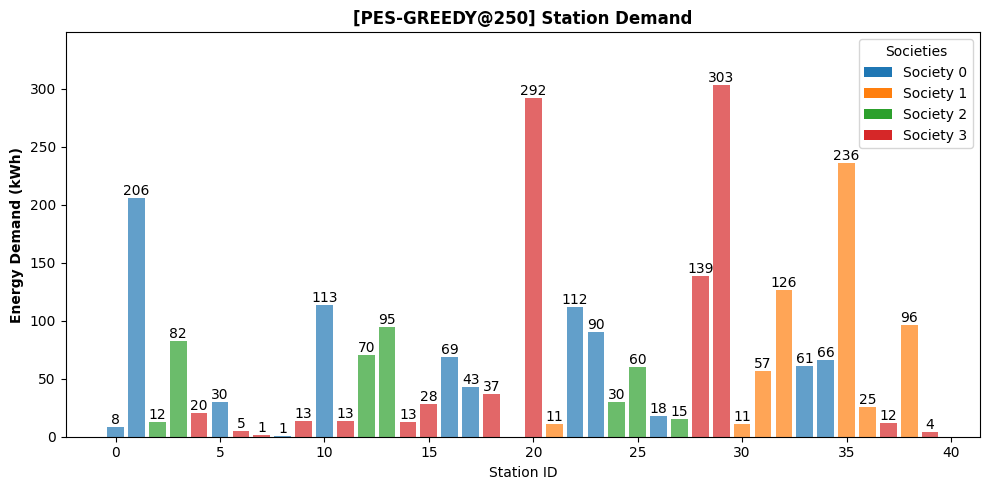

In [165]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

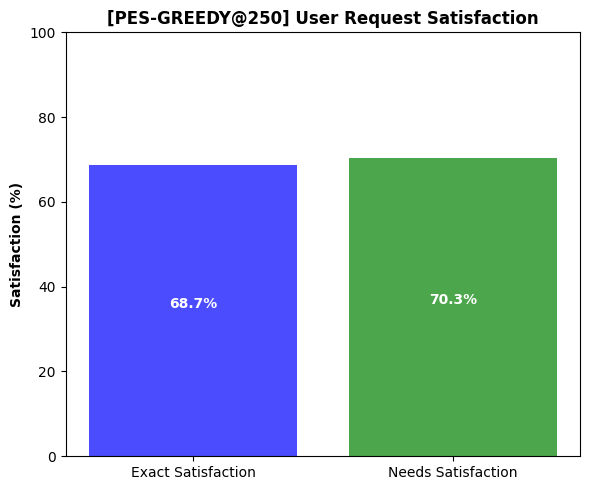

In [166]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

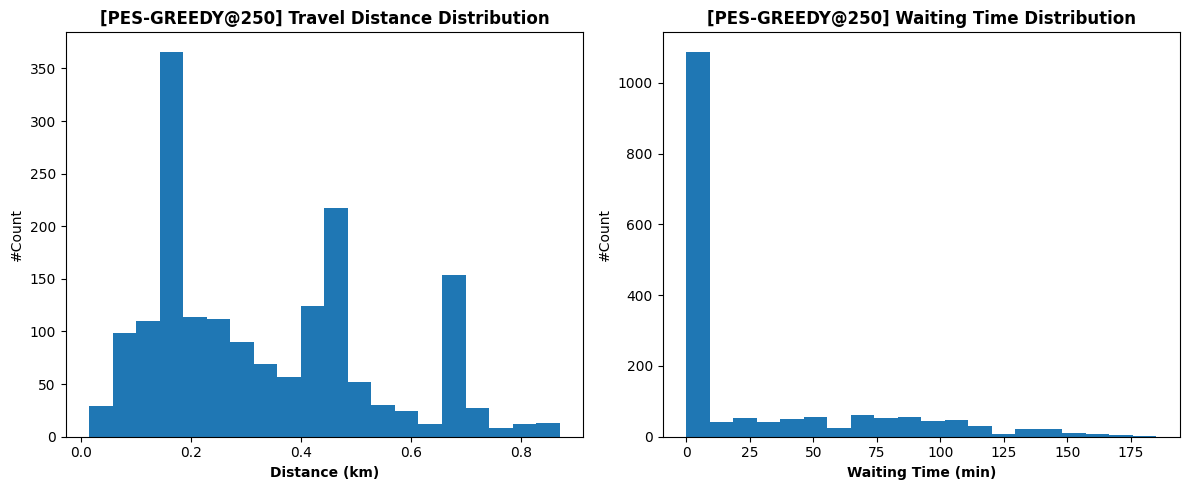

In [167]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

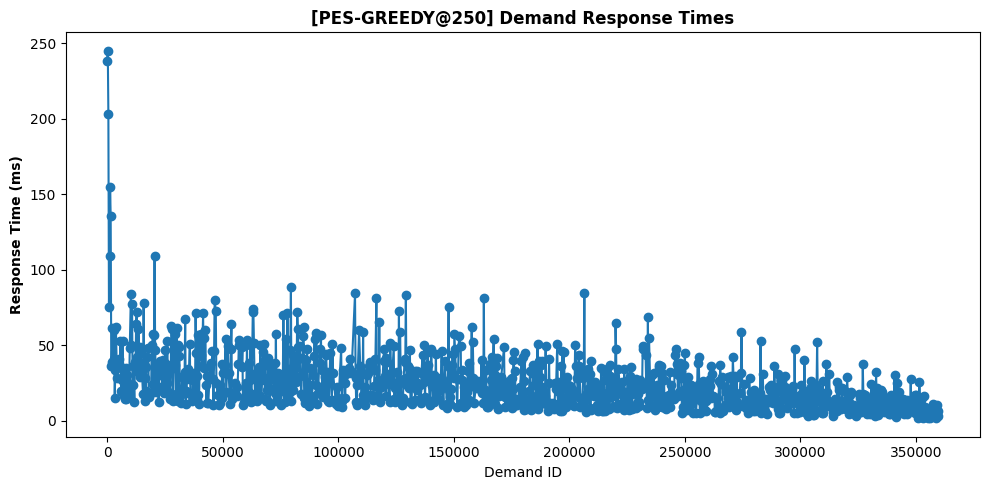

In [168]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

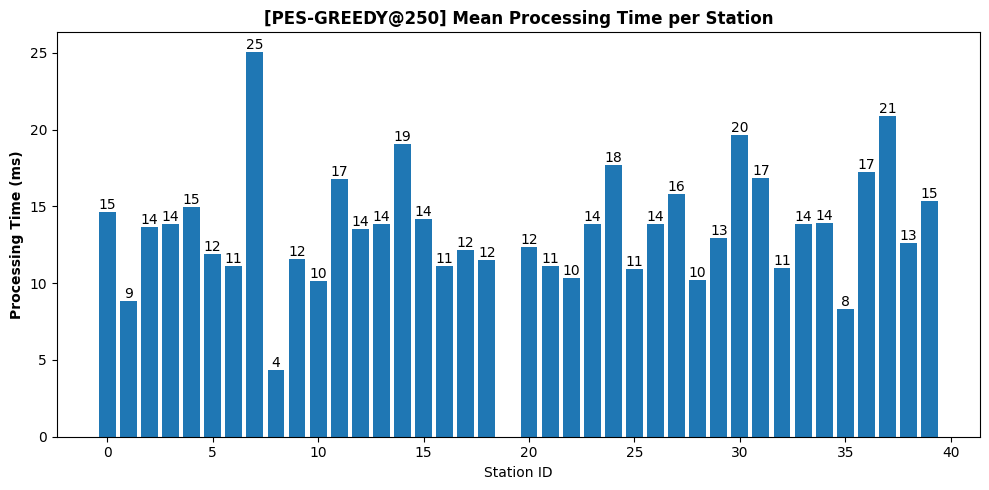

In [169]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [170]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.111111  0.000000  0.000000  0.000000  0.000000   
1            0           1  0.748611  0.809028  0.632639  0.734028       NaN   
2            0           5  0.327083  0.129861  0.000000  0.000000       NaN   
3            0           8  0.011806  0.000000  0.000000  0.000000  0.000000   
4            0          10  0.442361  0.394444  0.407639  0.417361       NaN   
5            0          16  0.566667  0.272222  0.070139  0.056250       NaN   
6            0          17  0.309722  0.232639  0.013889  0.072917       NaN   
7            0          22  0.641667  0.459028  0.270833  0.356250       NaN   
8            0          23  0.531250  0.332639  0.204167  0.020833  0.238889   
9            0          26  0.259722  0.020833  0.000000  0.000000  0.000000   
10           0          33  0.542361  0.242361  0.089583  0.000000  0.021528   
11           0          34  0.490972  0.

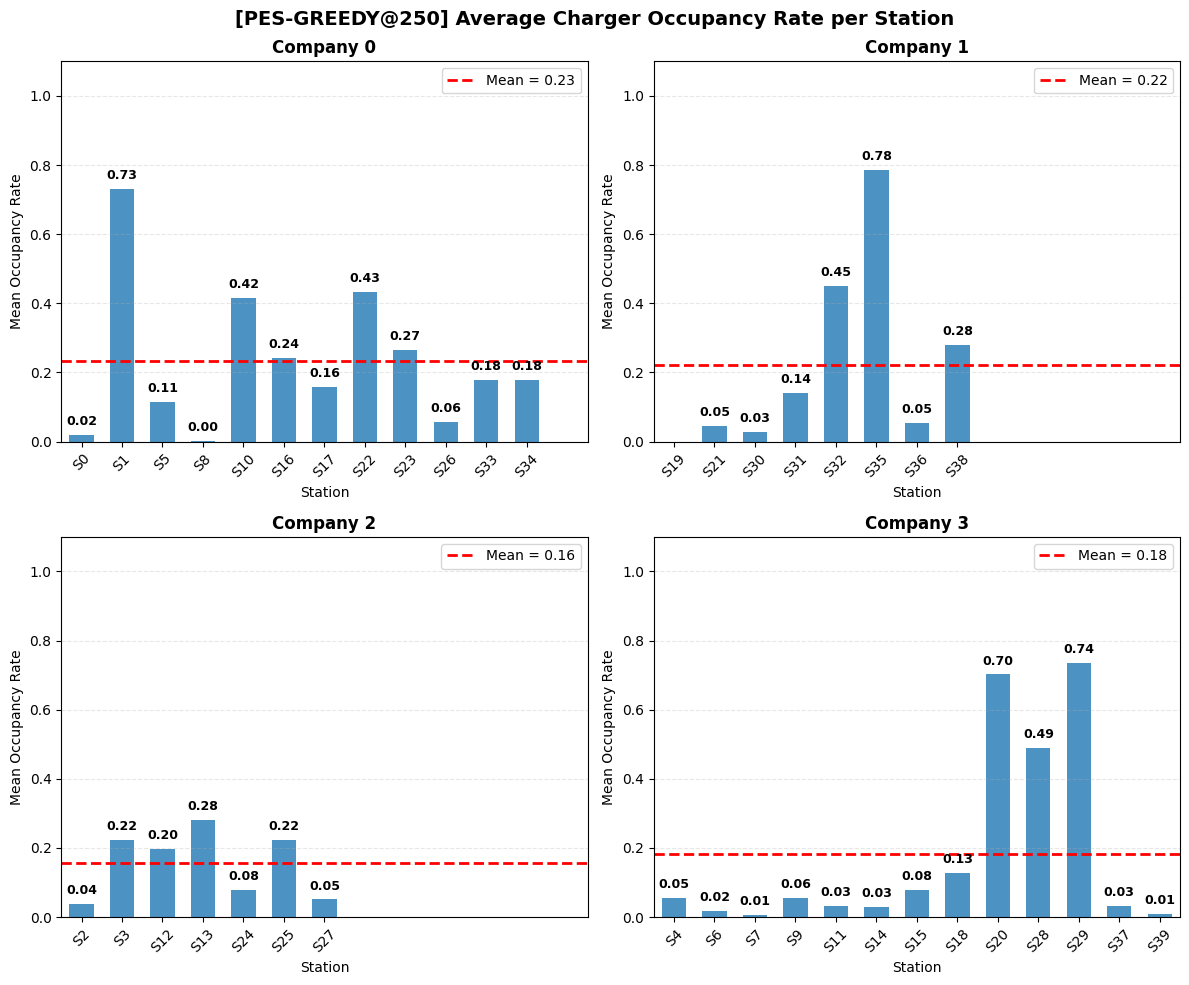

In [171]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

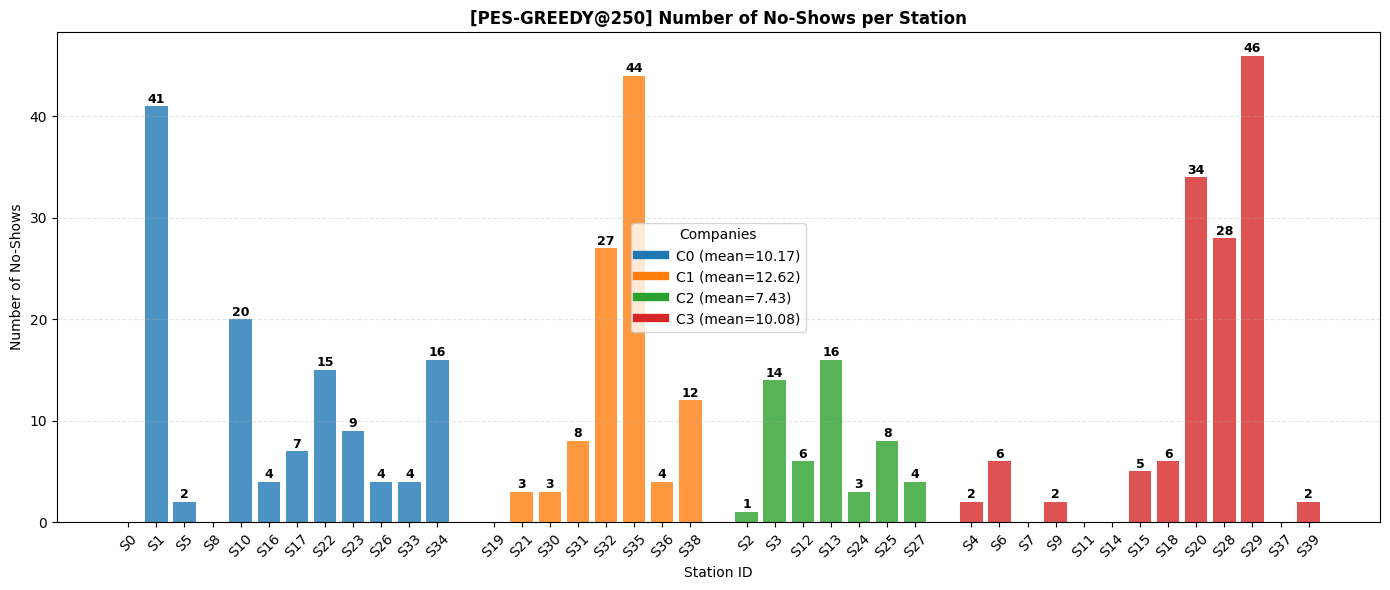

In [172]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [173]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,6,6,0,0,0,1.000000,0.000000,0.000000,0.000000
1,0,1,205,155,41,4,4,0.756098,0.200000,0.019512,0.019512
2,0,5,19,17,2,0,0,0.894737,0.105263,0.000000,0.000000
3,0,8,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
4,0,10,88,66,20,0,0,0.750000,0.227273,0.000000,0.000000
5,0,16,42,38,4,0,0,0.904762,0.095238,0.000000,0.000000
6,0,17,31,24,7,0,0,0.774194,0.225806,0.000000,0.000000
7,0,22,82,66,15,0,0,0.804878,0.182927,0.000000,0.000000
8,0,23,62,53,9,0,0,0.854839,0.145161,0.000000,0.000000
9,0,26,16,12,4,0,0,0.750000,0.250000,0.000000,0.000000


#### **BRAM-EV**

##### *Params*

In [174]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [175]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [176]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 23:42:09.935 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 23:42:13.774 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 23:42:15.399 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 23:42:17.258 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 23:42:19.338 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 23:42:21.383 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 23:42:23.232 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 23:42:25.945 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 23:42:29.839 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 23:42:31.973 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 23:42:34.257 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [177]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 15.06 kWh
  Station 1: 31.32 kWh
  Station 2: 7.54 kWh
  Station 3: 12.02 kWh
  Station 4: 32.79 kWh
  Station 5: 21.42 kWh
  Station 6: 90.48 kWh
  Station 7: 69.72 kWh
  Station 8: 39.42 kWh
  Station 9: 81.73 kWh
  Station 10: 154.56 kWh
  Station 11: 224.15 kWh
  Station 12: 28.72 kWh
  Station 13: 16.32 kWh
  Station 14: 146.78 kWh
  Station 15: 18.18 kWh
  Station 16: 106.61 kWh
  Station 17: 130.44 kWh
  Station 18: 220.23 kWh
  Station 19: 62.02 kWh
  Station 20: 174.67 kWh
  Station 21: 95.71 kWh
  Station 22: 203.91 kWh
  Station 23: 71.23 kWh
  Station 24: 104.15 kWh
  Station 25: 15.39 kWh
  Station 26: 12.33 kWh
  Station 27: 80.86 kWh
  Station 28: 18.74 kWh
  Station 29: 48.29 kWh
  Station 30: 91.70 kWh
  Station 31: 8.01 kWh
  Station 32: 18.23 kWh
  Station 33: 51.67 kWh
  Station 34: 43.83 kWh
  Station 35: 60.50 kWh
  Station 36: 1.27 kWh
  Station 37: 14.54 kWh
  Station 38: 26.98 kWh
  Sta

In [178]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

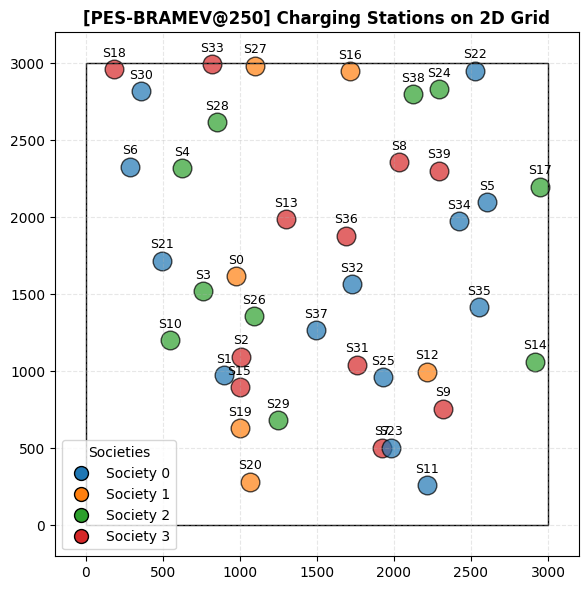

In [179]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

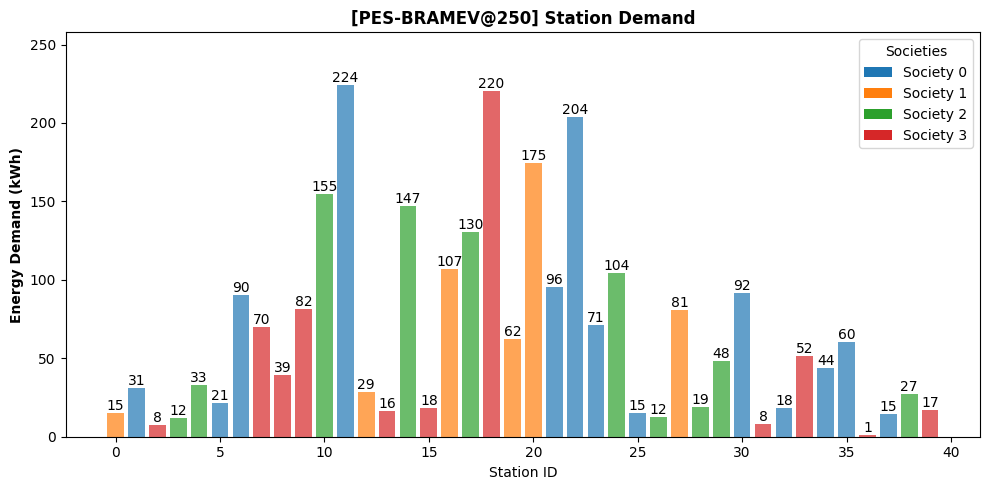

In [180]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

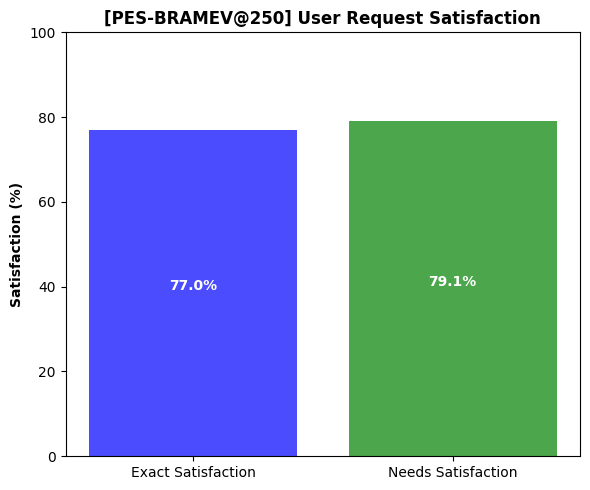

In [181]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

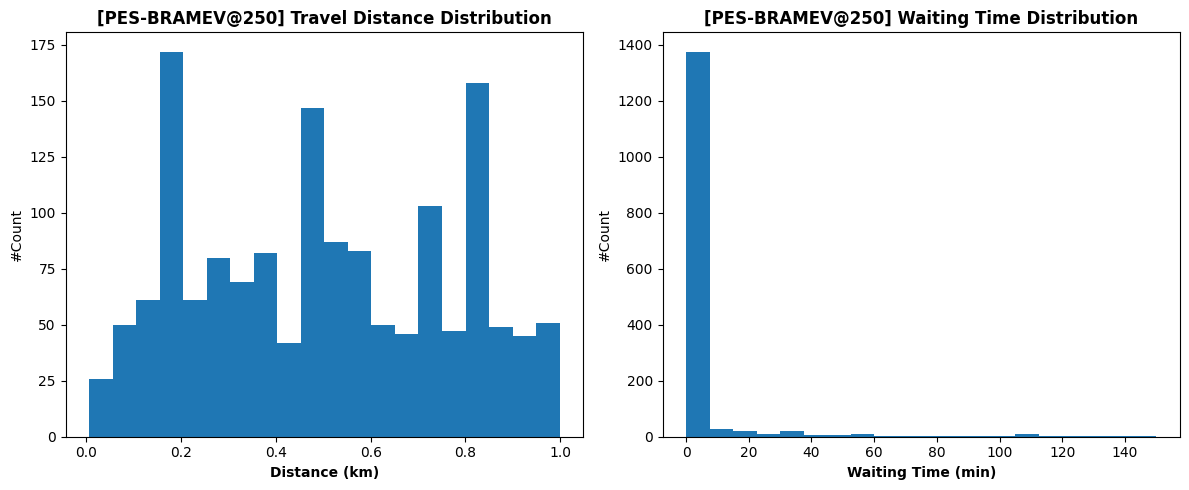

In [182]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

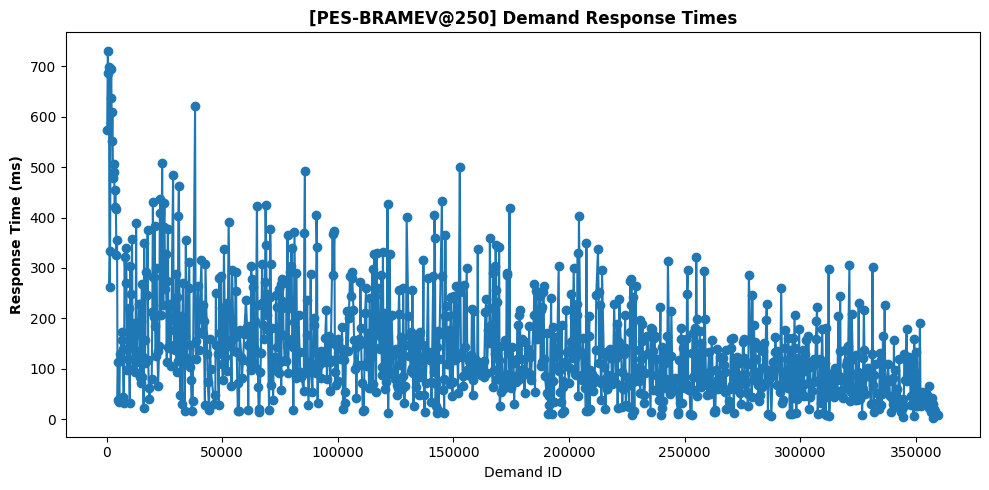

In [183]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

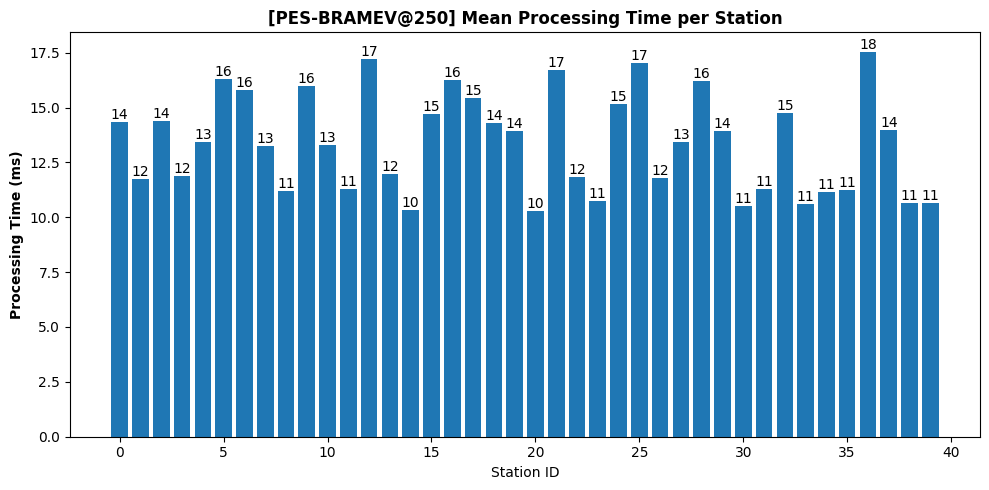

In [184]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

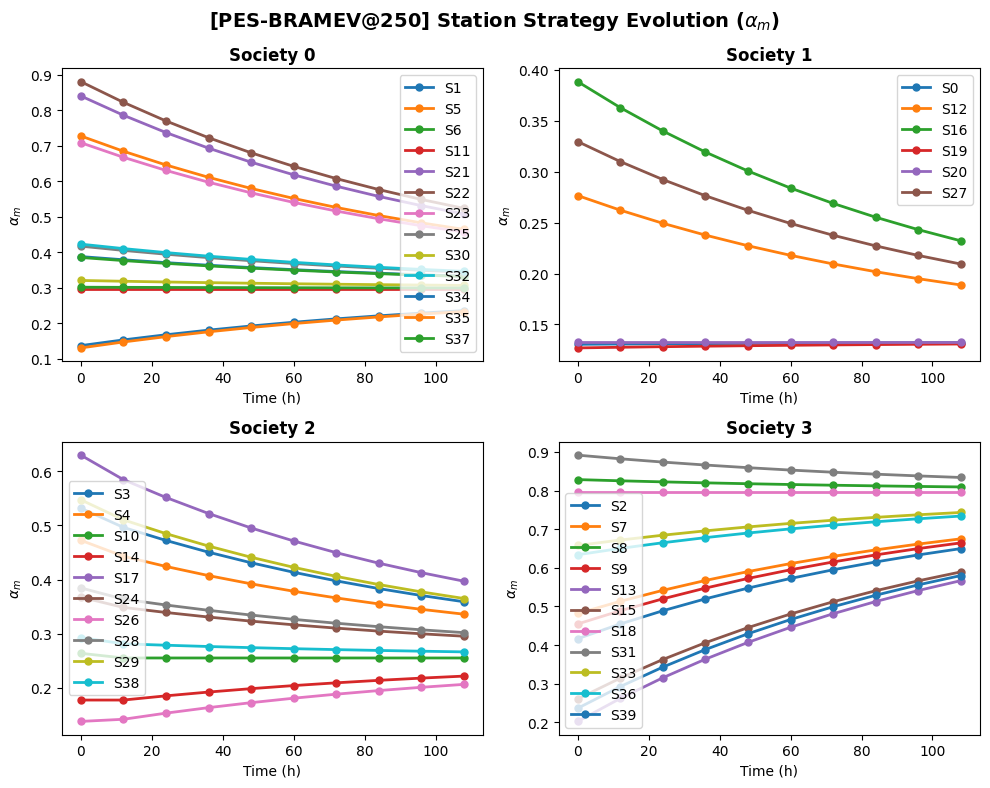

In [185]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [186]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.251389  0.111111  0.013889  0.089583       NaN   
1            0           5  0.234722  0.088889  0.000000  0.000000  0.000000   
2            0           6  0.503472  0.435417  0.172222  0.060417  0.055556   
3            0          11  0.677083  0.752083  0.688194  0.597222  0.511806   
4            0          21  0.360417  0.502083  0.152778  0.020139  0.168056   
5            0          22  0.660417  0.717361  0.561806  0.463194  0.635417   
6            0          23  0.495139  0.295139  0.111806  0.202778       NaN   
7            0          25  0.185417  0.072222  0.000000  0.000000  0.000000   
8            0          30  0.446528  0.474306  0.190278  0.229167       NaN   
9            0          32  0.122917  0.056944  0.000000  0.024306  0.034028   
10           0          34  0.372222  0.176389  0.073611  0.082639       NaN   
11           0          35  0.512500  0.

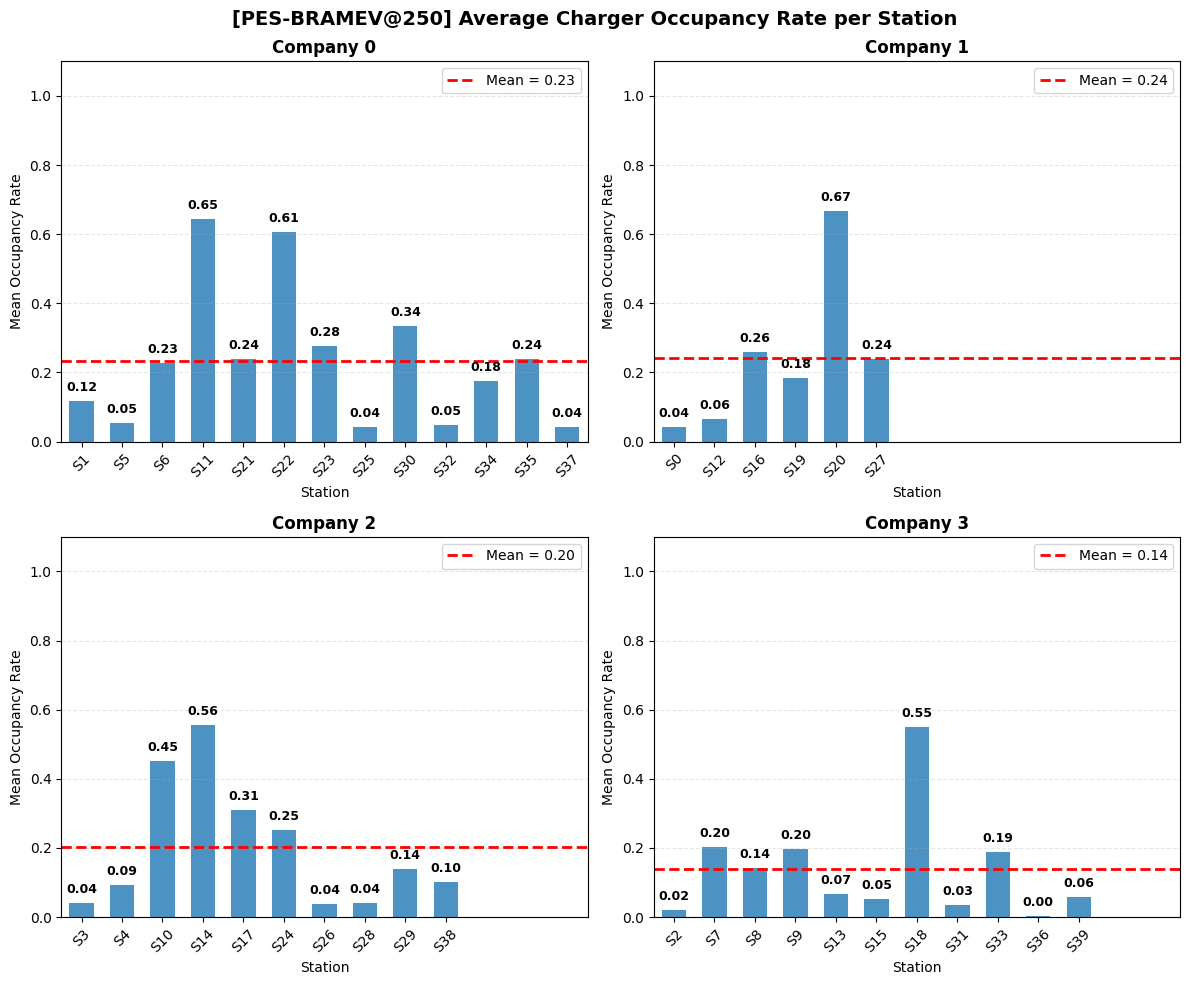

In [187]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

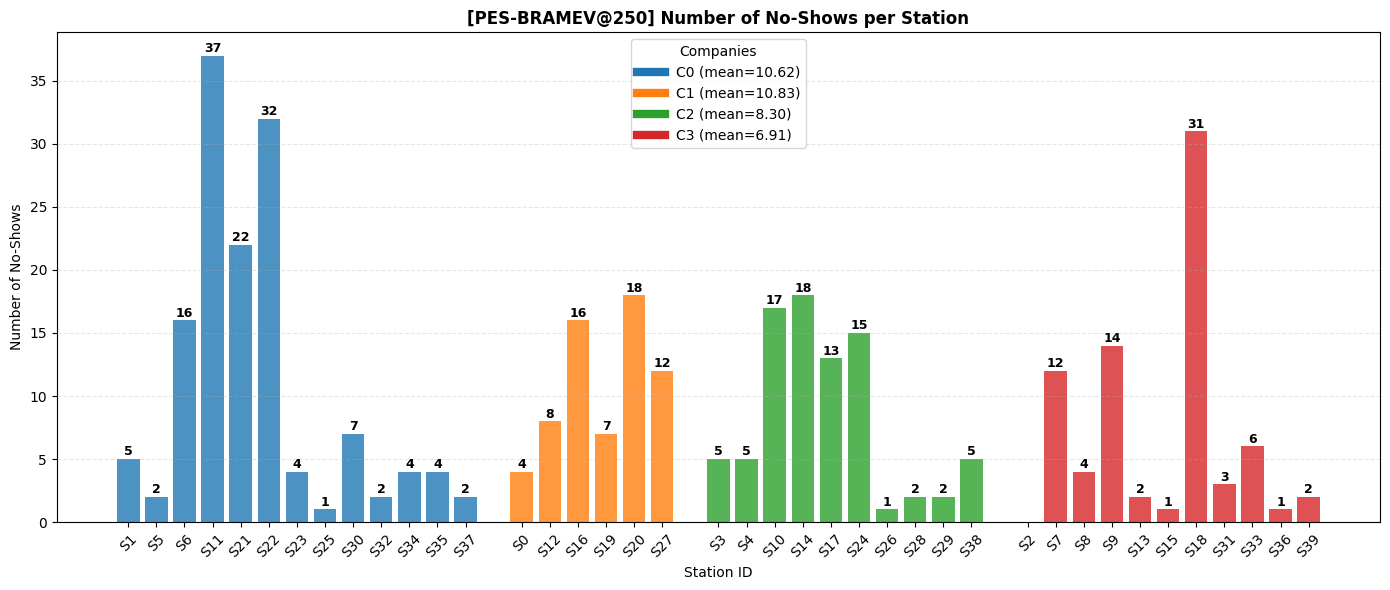

In [188]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [189]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,23,18,5,0,0,0.782609,0.217391,0.000000,0.0
1,0,5,13,11,2,0,0,0.846154,0.153846,0.000000,0.0
2,0,6,66,50,16,0,0,0.757576,0.242424,0.000000,0.0
3,0,11,177,136,37,3,0,0.768362,0.209040,0.016949,0.0
4,0,21,78,55,22,0,0,0.705128,0.282051,0.000000,0.0
5,0,22,149,114,32,0,0,0.765101,0.214765,0.000000,0.0
6,0,23,45,41,4,0,0,0.911111,0.088889,0.000000,0.0
7,0,25,10,9,1,0,0,0.900000,0.100000,0.000000,0.0
8,0,30,59,51,7,0,0,0.864407,0.118644,0.000000,0.0
9,0,32,12,10,2,0,0,0.833333,0.166667,0.000000,0.0


#### **COMPARISON**

##### *Params*

In [190]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

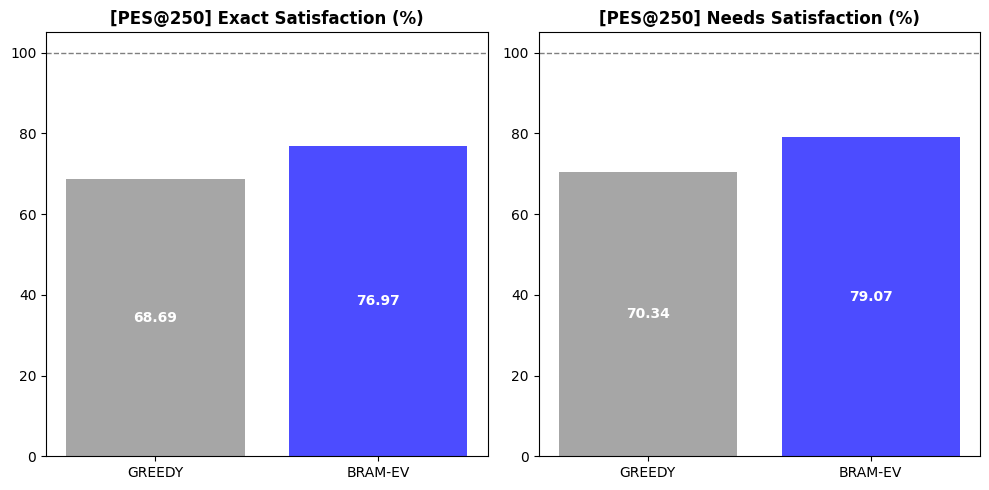

In [191]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

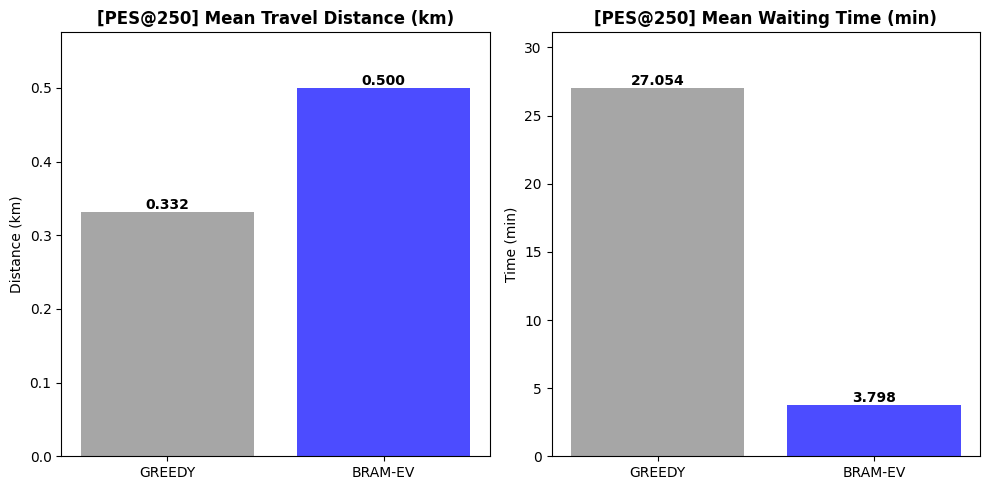

In [192]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

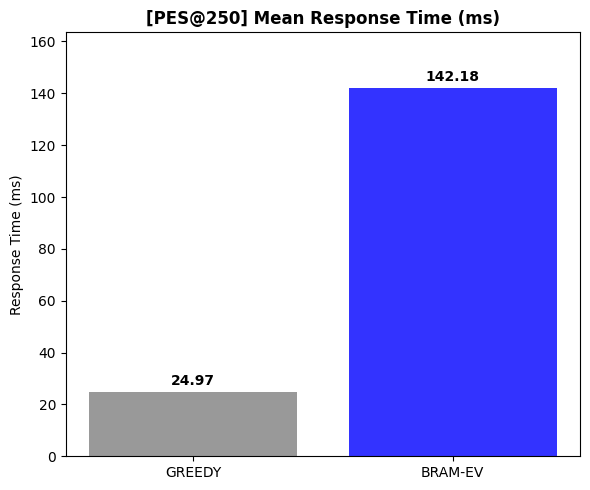

In [193]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

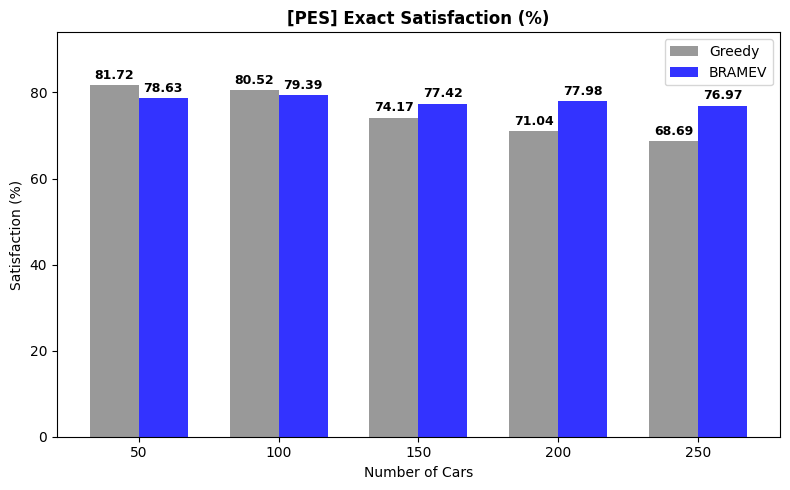

In [194]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

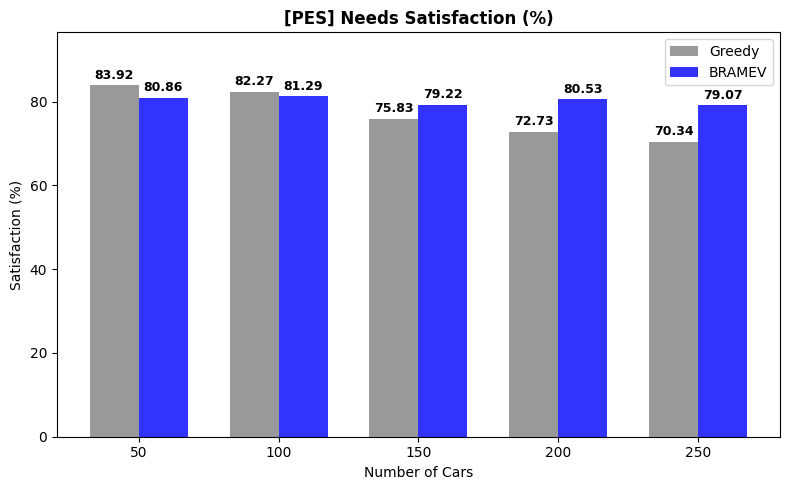

In [195]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

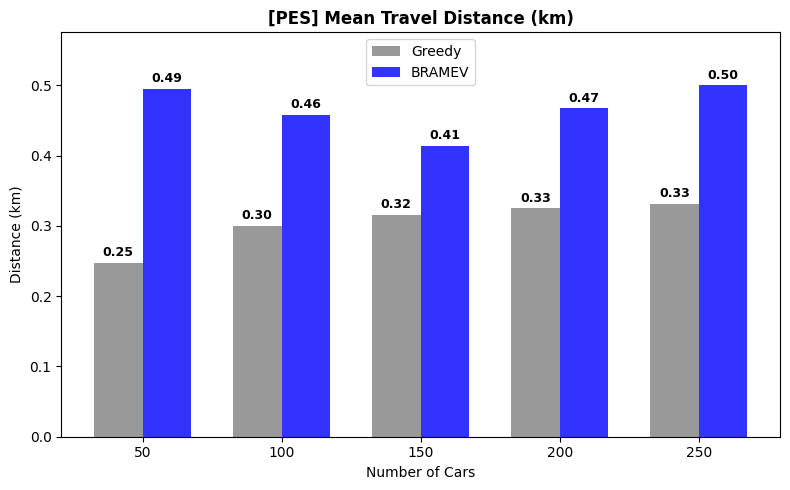

In [196]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


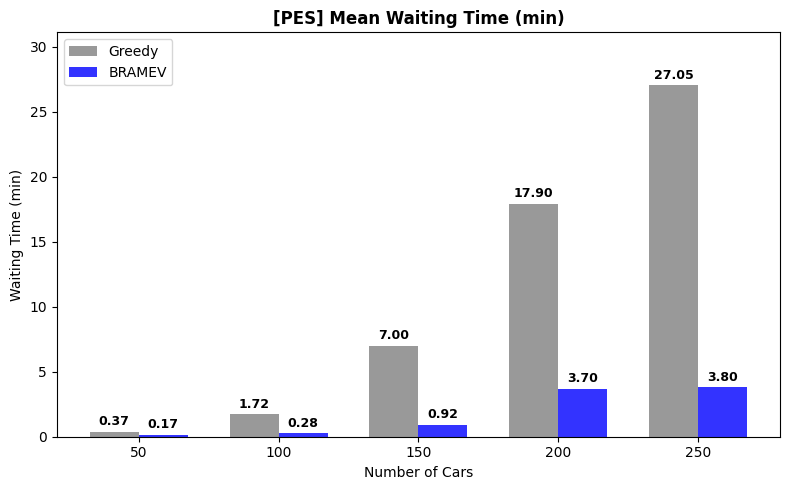

In [197]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


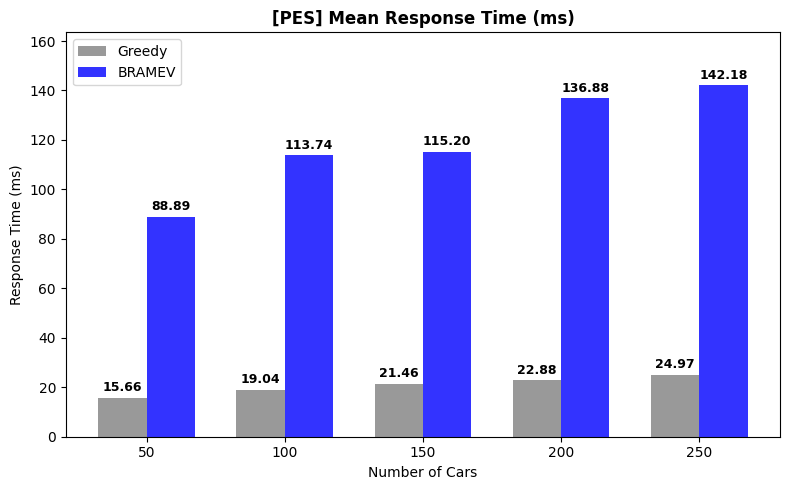

In [198]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
